# Análise de dados das transações imobiliárias de Fortaleza

## Seminário 01 — Inteligência de Negócios

**Instituição:** Universidade Federal do Ceará — UFC  
**Curso:** Ciências Atuariais  
**Disciplina:** Inteligência de Negócios  
**Professor:** Carlos Caminha  
**Semestre:** 2026.2  

---

## Apresentação

Este notebook apresenta o processo de preparação, tratamento e análise exploratória da base pública de registros do **Imposto sobre a Transmissão de Bens Imóveis (ITBI)** do município de Fortaleza.

O conjunto de dados contém informações cadastrais, temporais, financeiras e espaciais relacionadas aos imóveis e aos registros de ITBI. Entre as variáveis disponíveis estão o bairro, o tipo de uso do imóvel, a área do terreno, a área edificada, o ano de construção, os valores imobiliários e as coordenadas geográficas no sistema SIRGAS 2000.

O trabalho será desenvolvido de maneira sequencial e documentada, abrangendo as seguintes etapas:

1. importação e apresentação do dataset original;
2. compreensão e classificação das variáveis;
3. conversão dos tipos de dados;
4. seleção das variáveis relevantes;
5. análise e tratamento dos valores ausentes;
6. criação de novas variáveis;
7. verificação da consistência temporal;
8. diferenciação entre registros, operações e imóveis distintos;
9. padronização das variáveis categóricas;
10. transformação e complementação das coordenadas geográficas;
11. validação da consistência espacial;
12. construção de análises e visualizações;
13. preparação e exportação do dataset tratado.

A base original será preservada durante todo o processo. As transformações serão realizadas em uma cópia, permitindo comparar os dados originais com o resultado obtido após o tratamento.

### Fonte oficial dos dados

O conjunto de dados foi obtido no Portal de Dados Abertos da Prefeitura de Fortaleza, sob responsabilidade da Secretaria Municipal das Finanças — SEFIN.

A página oficial descreve o conjunto como uma relação de transações imobiliárias com recolhimento de ITBI, contendo a geolocalização, as características dos imóveis e informações sobre as operações.

**Página oficial do conjunto de dados:**

[Imposto sobre Transmissão de Bens Imóveis — ITBI](https://dados.fortaleza.ce.gov.br/dataset/dados_abertos_itbi_transacoes_imobiliarias)

**Página do arquivo CSV utilizado:**

[Recurso em formato CSV — ITBI Fortaleza](https://dados.fortaleza.ce.gov.br/dataset/dados_abertos_itbi_transacoes_imobiliarias/resource/46324d49-9809-4d32-8e5c-b4b570f067ce)

Recomenda-se consultar a página oficial para verificar a descrição, a licença, a data de atualização e possíveis versões mais recentes da base.


## Configuração do ambiente

Nesta etapa, serão instaladas e importadas as bibliotecas necessárias para a preparação, análise e visualização dos dados.

As bibliotecas serão utilizadas para:

- manipulação e tratamento de dados;
- cálculos numéricos;
- criação de gráficos;
- transformação de coordenadas geográficas;
- geocodificação de endereços;
- produção de animações;
- conexão e salvamento de arquivos no Google Drive.

In [ ]:
# Importar o recurso de acesso ao Google Drive
from google.colab import drive

# Conectar o notebook ao Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Instalar as bibliotecas necessárias para o tratamento espacial
!pip install pyproj geopy -q

In [ ]:
# Manipulação e tratamento dos dados
import pandas as pd
import numpy as np

# Visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

# Criação de animações
from matplotlib.animation import FuncAnimation
from IPython.display import Video, display

# Transformação de coordenadas geográficas
from pyproj import Transformer

# Geocodificação de endereços
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Manipulação e cópia de arquivos
import shutil

# Recursos do Google Colab
from google.colab import drive, files

## 1. Importação do dataset original

Nesta etapa, será importado o conjunto de dados utilizado no trabalho. O arquivo está armazenado no Google Drive no formato CSV.

A base contém registros do **Imposto sobre a Transmissão de Bens Imóveis (ITBI)** do município de Fortaleza. Os campos do arquivo estão separados por ponto e vírgula (`;`) e sua codificação de caracteres é `Latin-1`.

O dataset original será armazenado no DataFrame denominado `dados`. Essa base será preservada, e os tratamentos posteriores serão realizados em uma cópia.

In [ ]:
# Informar o caminho do arquivo no Google Drive
caminho = (
    '/content/drive/MyDrive/'
    'Ciências Atuariais 2026_2/BI/Seminario01/'
    'dados_abertos_itbi_transacoes_imobiliarias.csv'
)

# Importar o dataset original
dados = pd.read_csv(
    caminho,
    sep=';',
    encoding='latin1'
)

# Exibir as cinco primeiras linhas
dados.head()

,VERSAO,INSCRICAO_IMOVEL,DIGITO,NUM_DTI,EXERCICIO,DATA_CADASTRAMENTO_GI_IMOVEL,NUMERO_CEP,BAIRRO,LOGRADOURO,NUMERO,...,ANO_MES_DEBITO,NOME_ZONEAMENTO,ZONA_CARTORIO,DATA_DA_TRANSACAO_ITBI,ID_IMOVEL,CARTOGRAFIA,VL_BASE_CALCULO,VL_VENAL,VL_LANCAMENTO_IPTU,IND_COMPRA_VIA_PROGRAMA_HABITACIONAL
0,1,476677,6,2187/2026,2026,03/02/2026 07:12,60866340.0,JANGURUSSU,R 307 DO CONJUNTO HABITACIONAL SAO CRISTOVAO,416.0,...,2026/FEVEREIRO,ZONA DE OCUPAÇÃO MODERADA 2,2ª Zona,NaN,1796683,74-322-80,205770,"33081,92",0,Nenhum
1,1,856041,2,2186/2026,2026,03/02/2026 05:52,60714750.0,RACHEL DE QUEIROZ,R A (LOT. MRV MAGIS - DENDE),90.0,...,2026/FEVEREIRO,ZONA DE REQUALIFICAÇÃO URBANA 2,6ª Zona,NaN,2085952,41-194-677,213420,"76330,21",0,Nenhum
2,1,857794,3,2185/2026,2026,02/02/2026 23:26,60712025.0,JARDIM CEARENSE,R RUBENS MONTE,120.0,...,2026/FEVEREIRO,ZONA DE REQUALIFICAÇÃO URBANA 2,6ª Zona,NaN,2087824,43-65-381,497000,"207360,08","1308,98",Nenhum
3,1,575069,5,2184/2026,2026,02/02/2026 18:28,60844160.0,LAGOA REDONDA,R AMBROSIO DE CARVALHO,725.0,...,2026/FEVEREIRO,ZONA DE OCUPAÇÃO MODERADA 2,1ª Zona,NaN,1392785,64-166-106,320000,"41495,41",0,Sistema Financeiro de Habitação
4,1,904293,8,2183/2026,2026,02/02/2026 18:03,60810160.0,GUARARAPES,AV CEL MIGUEL DIAS,1140.0,...,2026/FEVEREIRO,ZONA DE OCUPAÇÃO MODERADA 1,1ª Zona,NaN,2145374,56-258-426,1611820,"686871,37","6336,77",Nenhum


## 2. Inspeção inicial do dataset

Após a importação, é necessário conhecer a estrutura do conjunto de dados antes de realizar qualquer transformação.

O método `info()` será utilizado para apresentar:

- o tipo do objeto importado;
- a quantidade de linhas;
- a quantidade de colunas;
- o nome de cada variável;
- a quantidade de valores preenchidos;
- o tipo de dado atribuído pelo Pandas;
- o consumo aproximado de memória.

Essa inspeção permite identificar variáveis importadas com tipos inadequados e observar inicialmente a presença de valores ausentes.

In [ ]:
# Apresentar a estrutura inicial do dataset
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94970 entries, 0 to 94969
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   VERSAO                                94970 non-null  int64  
 1   INSCRICAO_IMOVEL                      94970 non-null  int64  
 2   DIGITO                                94970 non-null  int64  
 3   NUM_DTI                               94970 non-null  object 
 4   EXERCICIO                             94970 non-null  int64  
 5   DATA_CADASTRAMENTO_GI_IMOVEL          94970 non-null  object 
 6   NUMERO_CEP                            94969 non-null  float64
 7   BAIRRO                                94970 non-null  object 
 8   LOGRADOURO                            94969 non-null  object 
 9   NUMERO                                90357 non-null  float64
 10  XSIRGAS2000                           94964 non-null  object 
 11  YSIRGAS2000    

### 2.1 Apresentação do dataset original

O conjunto de dados utilizado neste trabalho foi obtido no Portal de Dados Abertos da Prefeitura de Fortaleza e reúne informações relacionadas aos registros do **Imposto sobre a Transmissão de Bens Imóveis (ITBI)**.

O ITBI é um tributo municipal cobrado nas transmissões de imóveis realizadas entre pessoas vivas, como ocorre nas operações de compra e venda. Por esse motivo, a base contém informações relacionadas aos imóveis e aos respectivos registros administrativos.

Cada linha do dataset representa um registro relacionado ao ITBI. Entretanto, um mesmo imóvel pode aparecer em mais de uma linha, pois pode estar associado a diferentes declarações ou operações. Dessa forma, a quantidade de registros não corresponde necessariamente à quantidade de imóveis distintos.

A base original possui informações:

- identificadoras;
- temporais;
- espaciais;
- cadastrais;
- construtivas;
- financeiras;
- relacionadas ao uso dos imóveis.

Antes de realizar o tratamento, serão verificadas as dimensões do dataset e a quantidade de registros, variáveis, imóveis e operações distintas.

In [ ]:
# Apresentar as dimensões e algumas características da base original
print(
    'Quantidade de registros:',
    dados.shape[0]
)

print(
    'Quantidade de variáveis:',
    dados.shape[1]
)

print(
    'Quantidade de imóveis distintos:',
    dados['ID_IMOVEL'].nunique()
)

print(
    'Quantidade de registros de DTI distintos:',
    dados['NUM_DTI'].nunique()
)

Quantidade de registros: 94970
Quantidade de variáveis: 31
Quantidade de imóveis distintos: 80008
Quantidade de registros de DTI distintos: 94970


### Interpretação das dimensões do dataset

O dataset original possui **94.970 registros e 31 variáveis**.

A variável `NUM_DTI` apresenta 94.970 valores distintos, quantidade igual ao número de linhas. Portanto, ela identifica individualmente cada registro de DTI presente na base.

Por outro lado, foram encontrados somente **80.008 valores distintos de `ID_IMOVEL`**. Isso demonstra que determinados imóveis aparecem em mais de um registro, possivelmente por estarem associados a diferentes declarações ou operações de ITBI.

Consequentemente, as análises deverão distinguir:

- **quantidade de registros ou operações**, baseada nas linhas ou em `NUM_DTI`;
- **quantidade de imóveis distintos**, baseada nos valores únicos de `ID_IMOVEL`.

Essa distinção evitará que um mesmo imóvel seja contado repetidamente em análises sobre características cadastrais, construtivas ou espaciais.

### 2.2 Visão geral das variáveis originais

Para compreender melhor a estrutura da base, será construída uma tabela contendo, para cada variável:

- o tipo de dado atribuído pelo Pandas;
- a quantidade de valores preenchidos;
- a quantidade de valores ausentes;
- a quantidade de valores distintos.

Essa tabela auxiliará na identificação das variáveis que precisam ter seus tipos convertidos e daquelas que apresentam problemas de preenchimento.

In [ ]:
# Construir uma visão geral das variáveis originais
resumo_variaveis = pd.DataFrame({
    'VARIAVEL': dados.columns,
    'TIPO_IMPORTADO': dados.dtypes.astype(str).values,
    'VALORES_PREENCHIDOS': dados.notna().sum().values,
    'VALORES_AUSENTES': dados.isna().sum().values,
    'VALORES_DISTINTOS': dados.nunique(dropna=True).values
})

# Exibir a tabela
resumo_variaveis

,VARIAVEL,TIPO_IMPORTADO,VALORES_PREENCHIDOS,VALORES_AUSENTES,VALORES_DISTINTOS
0,VERSAO,int64,94970,0,6
1,INSCRICAO_IMOVEL,int64,94970,0,80008
2,DIGITO,int64,94970,0,10
3,NUM_DTI,object,94970,0,94970
4,EXERCICIO,int64,94970,0,5
5,DATA_CADASTRAMENTO_GI_IMOVEL,object,94970,0,88272
6,NUMERO_CEP,float64,94969,1,5374
7,BAIRRO,object,94970,0,121
8,LOGRADOURO,object,94969,1,4413
9,NUMERO,float64,90357,4613,3222


### Interpretação da estrutura das variáveis originais

A inspeção confirmou que o dataset possui **31 variáveis**, com diferentes tipos e níveis de preenchimento.

Algumas observações iniciais são importantes:

- `NUM_DTI` possui 94.970 valores distintos e identifica individualmente os registros;
- `ID_IMOVEL` possui 80.008 valores distintos, indicando que alguns imóveis aparecem em mais de um registro;
- `DATA_CADASTRAMENTO_GI_IMOVEL`, `DATA_CONSTRUCAO` e `DATA_DA_TRANSACAO_ITBI` foram importadas como texto e precisarão ser convertidas para data;
- `XSIRGAS2000`, `YSIRGAS2000`, `FRACAO_IDEAL`, `AREA_TERRENO`, `AREA_EDIFICADA`, `VL_BASE_CALCULO`, `VL_VENAL` e `VL_LANCAMENTO_IPTU` foram importadas como texto, embora representem valores quantitativos;
- `NUMERO_CEP`, `INSCRICAO_IMOVEL`, `DIGITO` e `ID_IMOVEL` foram importadas como números, mas conceitualmente funcionam como códigos identificadores;
- `TIPO_TERRENO` está completamente vazia e não apresenta informação aproveitável;
- `DATA_DA_TRANSACAO_ITBI` possui 84.127 valores ausentes, correspondentes a 88,58% dos registros;
- `NOME_ZONEAMENTO` e `NUMERO_PAVIMENTOS` também apresentam proporções relevantes de valores ausentes;
- as coordenadas `XSIRGAS2000` e `YSIRGAS2000` possuem somente seis valores ausentes.

Essas observações orientarão as próximas etapas de conversão, seleção e tratamento dos dados. Nenhuma variável será excluída antes da análise de sua finalidade e de sua contribuição para o trabalho.

### 2.3 Descrição e classificação das variáveis originais

As variáveis foram organizadas de acordo com sua função no dataset. As descrições apresentadas são interpretações operacionais baseadas nos nomes dos campos e nos valores observados na base.

| Variável | Classificação | Descrição |
|---|---|---|
| `VERSAO` | Administrativa | Versão do registro no sistema de origem. |
| `INSCRICAO_IMOVEL` | Identificadora | Número da inscrição cadastral do imóvel. |
| `DIGITO` | Identificadora | Dígito verificador da inscrição do imóvel. |
| `NUM_DTI` | Identificadora | Número identificador do registro ou da declaração de ITBI. |
| `EXERCICIO` | Temporal | Exercício ou ano administrativo relacionado ao registro. |
| `DATA_CADASTRAMENTO_GI_IMOVEL` | Temporal | Data e hora de cadastramento do registro no sistema. |
| `NUMERO_CEP` | Espacial/identificadora | Código de Endereçamento Postal do imóvel. |
| `BAIRRO` | Espacial/categórica | Bairro em que o imóvel está localizado. |
| `LOGRADOURO` | Espacial/categórica | Logradouro correspondente ao endereço do imóvel. |
| `NUMERO` | Espacial/identificadora | Número do imóvel no logradouro. |
| `XSIRGAS2000` | Espacial/quantitativa | Coordenada X no sistema de referência SIRGAS 2000. |
| `YSIRGAS2000` | Espacial/quantitativa | Coordenada Y no sistema de referência SIRGAS 2000. |
| `QTD_FRENTES` | Quantitativa discreta | Quantidade de frentes do imóvel. |
| `FRACAO_IDEAL` | Quantitativa contínua | Fração ideal do terreno vinculada ao imóvel. |
| `AREA_TERRENO` | Quantitativa contínua | Área do terreno associada ao imóvel. |
| `AREA_EDIFICADA` | Quantitativa contínua | Área edificada do imóvel. |
| `DATA_CONSTRUCAO` | Temporal | Data de construção cadastrada para o imóvel. |
| `NUMERO_PAVIMENTOS` | Quantitativa discreta | Quantidade de pavimentos do imóvel. |
| `TIPO_USO_IMOVEL` | Categórica nominal | Categoria de utilização do imóvel. |
| `PADRAO_CONSTRUCAO` | Categórica | Classificação do padrão construtivo do imóvel. |
| `TIPO_TERRENO` | Categórica | Campo destinado ao tipo de terreno, completamente vazio nesta base. |
| `ANO_MES_DEBITO` | Temporal/categórica | Ano e mês relacionados ao débito registrado. |
| `NOME_ZONEAMENTO` | Espacial/categórica | Classificação urbanística da zona onde o imóvel está localizado. |
| `ZONA_CARTORIO` | Categórica | Zona de cartório associada ao registro. |
| `DATA_DA_TRANSACAO_ITBI` | Temporal | Data declarada da transação imobiliária relacionada ao ITBI. |
| `ID_IMOVEL` | Identificadora | Código utilizado para identificar o imóvel na base. |
| `CARTOGRAFIA` | Identificadora/espacial | Código cartográfico associado à localização cadastral do imóvel. |
| `VL_BASE_CALCULO` | Quantitativa contínua | Valor utilizado como base de cálculo do ITBI. |
| `VL_VENAL` | Quantitativa contínua | Valor venal cadastrado para o imóvel. |
| `VL_LANCAMENTO_IPTU` | Quantitativa contínua | Valor do lançamento do IPTU. |
| `IND_COMPRA_VIA_PROGRAMA_HABITACIONAL` | Categórica nominal | Indicação de aquisição por programa ou sistema habitacional. |

Essa classificação orientará a definição dos tipos de dados, a seleção das variáveis relevantes e a escolha das análises e visualizações mais adequadas.

Algumas descrições deverão ser interpretadas com cautela, pois não foi localizado, até esta etapa, um dicionário oficial detalhado que apresente a definição administrativa de todos os campos.

## 3. Preparação e tratamento dos dados

Após a apresentação e a inspeção do dataset original, iniciaremos a preparação dos dados para as análises.

Para preservar as informações importadas, o DataFrame `dados` não será modificado. Será criada uma cópia denominada `dados_trabalho`, na qual serão realizadas as conversões, correções e demais transformações.

### 3.1 Identificação e exclusão de variáveis completamente vazias

A inspeção inicial apresentada anteriormente já revelou que a variável `TIPO_TERRENO` não possui nenhum valor preenchido. Portanto, a verificação realizada nesta etapa retoma uma informação que já havia sido identificada.

Apesar dessa redundância, o procedimento será mantido para fins didáticos. O objetivo é demonstrar, por meio de código, como identificar automaticamente variáveis completamente vazias, sem depender apenas da observação manual da tabela anterior.

Variáveis sem nenhum valor preenchido não fornecem informação para as análises e podem ser excluídas da base de trabalho. A exclusão será realizada somente no DataFrame `dados_trabalho`, preservando a variável no dataset original `dados`.

In [ ]:
# Criar uma cópia para realizar o tratamento
dados_trabalho = dados.copy()

# Conferir as dimensões iniciais da cópia
dados_trabalho.shape

(94970, 31)

In [ ]:
# Identificar as colunas com todos os valores ausentes
colunas_totalmente_ausentes = (
    dados_trabalho.columns[
        dados_trabalho.isna().all()
    ]
    .tolist()
)

colunas_totalmente_ausentes

['TIPO_TERRENO']

In [ ]:
# Excluir da base de trabalho as colunas completamente vazias
dados_trabalho = dados_trabalho.drop(
    columns=colunas_totalmente_ausentes
)

# Conferir as dimensões depois da exclusão
dados_trabalho.shape

(94970, 30)

Conforme identificado anteriormente, o procedimento encontrou somente a variável `TIPO_TERRENO`. Ela foi retirada da base de trabalho porque todos os seus 94.970 valores estavam ausentes.

Embora essa informação já estivesse presente na inspeção inicial, a execução do procedimento automático foi mantida para documentar e tornar reproduzível a decisão de exclusão.

### 3.2 Conversão das variáveis numéricas

In [ ]:
# Colunas quantitativas importadas como texto
colunas_numericas = [
    'XSIRGAS2000',
    'YSIRGAS2000',
    'FRACAO_IDEAL',
    'AREA_TERRENO',
    'AREA_EDIFICADA',
    'VL_BASE_CALCULO',
    'VL_VENAL',
    'VL_LANCAMENTO_IPTU'
]

# Registrar as ausências antes da conversão
ausentes_antes_conversao = (
    dados_trabalho[colunas_numericas]
    .isna()
    .sum()
)

# Converter as colunas para o tipo numérico
for coluna in colunas_numericas:
    dados_trabalho[coluna] = pd.to_numeric(
        dados_trabalho[coluna]
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )

In [ ]:
# Conferir os tipos após a conversão
dados_trabalho[colunas_numericas].dtypes

,0
XSIRGAS2000,float64
YSIRGAS2000,float64
FRACAO_IDEAL,float64
AREA_TERRENO,float64
AREA_EDIFICADA,float64
VL_BASE_CALCULO,float64
VL_VENAL,float64
VL_LANCAMENTO_IPTU,float64


In [ ]:
# O Colab apresentará a quantidade de valores ausentes em cada variável antes da conversão.
ausentes_antes_conversao

,0
XSIRGAS2000,6
YSIRGAS2000,6
FRACAO_IDEAL,0
AREA_TERRENO,0
AREA_EDIFICADA,2444
VL_BASE_CALCULO,6890
VL_VENAL,0
VL_LANCAMENTO_IPTU,5622


In [ ]:
# Contar os valores ausentes depois da conversão
ausentes_depois_conversao = (
    dados_trabalho[colunas_numericas]
    .isna()
    .sum()
)

# Construir uma tabela de validação
validacao_conversao_numerica = pd.DataFrame({
    'AUSENTES_ANTES': ausentes_antes_conversao,
    'AUSENTES_DEPOIS': ausentes_depois_conversao
})

# Calcular quantas novas ausências foram criadas
validacao_conversao_numerica['NOVAS_AUSENCIAS'] = (
    validacao_conversao_numerica['AUSENTES_DEPOIS']
    - validacao_conversao_numerica['AUSENTES_ANTES']
)

validacao_conversao_numerica

,AUSENTES_ANTES,AUSENTES_DEPOIS,NOVAS_AUSENCIAS
XSIRGAS2000,6,6,0
YSIRGAS2000,6,6,0
FRACAO_IDEAL,0,0,0
AREA_TERRENO,0,0,0
AREA_EDIFICADA,2444,2444,0
VL_BASE_CALCULO,6890,6890,0
VL_VENAL,0,0,0
VL_LANCAMENTO_IPTU,5622,5622,0


### Validação da conversão numérica

A quantidade de valores ausentes foi registrada antes e depois da conversão para verificar se algum conteúdo inválido seria transformado em `NaN` pelo argumento `errors='coerce'`.

A coluna `NOVAS_AUSENCIAS` apresentou valor igual a zero em todas as variáveis. Isso demonstra que a conversão não criou novos valores ausentes e que as ausências observadas já estavam presentes no dataset original.

Portanto, as oito variáveis foram convertidas para o tipo numérico sem perda adicional de informações.

### 3.3 Conversão das variáveis de data

As variáveis que representam datas foram importadas pelo Pandas como texto (`object`). Para realizar análises temporais, calcular a idade dos imóveis e extrair informações como ano e mês, essas colunas precisam ser convertidas para o tipo `datetime`.

Serão convertidas as seguintes variáveis:

- `DATA_CADASTRAMENTO_GI_IMOVEL`: data e hora em que o registro foi cadastrado no sistema;
- `DATA_CONSTRUCAO`: data de construção cadastrada para o imóvel;
- `DATA_DA_TRANSACAO_ITBI`: data declarada da transação relacionada ao ITBI.

A função `pd.to_datetime()` será utilizada com o formato `%d/%m/%Y %H:%M`, no qual:

- `%d` representa o dia;
- `%m` representa o mês;
- `%Y` representa o ano com quatro algarismos;
- `%H` representa a hora;
- `%M` representa os minutos.

O argumento `errors='coerce'` determina que valores vazios ou incompatíveis com o formato informado sejam convertidos em `NaT`, representação utilizada pelo Pandas para datas ausentes.

Assim como na conversão numérica, será realizada uma comparação entre a quantidade de valores ausentes antes e depois da conversão.

In [ ]:
# Variáveis que representam datas
colunas_datas = [
    'DATA_CADASTRAMENTO_GI_IMOVEL',
    'DATA_CONSTRUCAO',
    'DATA_DA_TRANSACAO_ITBI'
]

# Registrar as ausências antes da conversão
ausentes_antes_datas = (
    dados_trabalho[colunas_datas]
    .isna()
    .sum()
)

# Converter as variáveis para datetime
for coluna in colunas_datas:
    dados_trabalho[coluna] = pd.to_datetime(
        dados_trabalho[coluna],
        format='%d/%m/%Y %H:%M',
        errors='coerce'
    )

In [ ]:
# Conferir os tipos após a conversão
dados_trabalho[colunas_datas].dtypes

,0
DATA_CADASTRAMENTO_GI_IMOVEL,datetime64[ns]
DATA_CONSTRUCAO,datetime64[ns]
DATA_DA_TRANSACAO_ITBI,datetime64[ns]


In [ ]:
# Contar as ausências depois da conversão
ausentes_depois_datas = (
    dados_trabalho[colunas_datas]
    .isna()
    .sum()
)

# Construir a tabela de validação
validacao_conversao_datas = pd.DataFrame({
    'AUSENTES_ANTES': ausentes_antes_datas,
    'AUSENTES_DEPOIS': ausentes_depois_datas
})

# Calcular as novas ausências produzidas na conversão
validacao_conversao_datas['NOVAS_AUSENCIAS'] = (
    validacao_conversao_datas['AUSENTES_DEPOIS']
    - validacao_conversao_datas['AUSENTES_ANTES']
)

validacao_conversao_datas

,AUSENTES_ANTES,AUSENTES_DEPOIS,NOVAS_AUSENCIAS
DATA_CADASTRAMENTO_GI_IMOVEL,0,0,0
DATA_CONSTRUCAO,10198,10198,0
DATA_DA_TRANSACAO_ITBI,84127,84127,0


### Validação da conversão das datas

A quantidade de valores ausentes foi comparada antes e depois da conversão para verificar se existiam conteúdos incompatíveis com o formato de data especificado.

A coluna `NOVAS_AUSENCIAS` apresentou valor igual a zero nas três variáveis. Portanto, a conversão não produziu novas ausências e todos os valores anteriormente preenchidos foram reconhecidos corretamente como datas.

As ausências observadas em `DATA_CONSTRUCAO` e `DATA_DA_TRANSACAO_ITBI` já estavam presentes no dataset original e serão analisadas posteriormente.

### 3.4 Conversão do CEP e das variáveis identificadoras

Algumas variáveis foram importadas como números, embora representem códigos de identificação. Essas variáveis não devem ser tratadas como quantitativas, pois seus valores não representam contagens ou medições.

A variável `NUMERO_CEP`, por exemplo, representa o Código de Endereçamento Postal do imóvel. Apesar de ser formado por algarismos, o CEP é um código de localização. Além disso, CEPs iniciados por zero podem perder esse algarismo quando armazenados como números.

A conversão do CEP será realizada em três etapas:

1. conversão para o tipo inteiro anulável `Int64`;
2. conversão para texto;
3. preenchimento com zeros à esquerda até completar oito caracteres.

O tipo `Int64`, com a letra inicial maiúscula, permite preservar eventuais valores ausentes durante a conversão.

Também serão convertidas para texto as variáveis:

- `INSCRICAO_IMOVEL`;
- `DIGITO`;
- `NUM_DTI`;
- `ID_IMOVEL`;
- `CARTOGRAFIA`.

Embora algumas dessas variáveis contenham somente algarismos, elas funcionam como identificadores e não devem ser utilizadas em cálculos estatísticos.

In [ ]:
# Converter o CEP para texto e garantir oito caracteres
dados_trabalho['NUMERO_CEP'] = (
    dados_trabalho['NUMERO_CEP']
    .astype('Int64')
    .astype('string')
    .str.zfill(8)
)

# Variáveis que representam códigos identificadores
colunas_identificadoras = [
    'INSCRICAO_IMOVEL',
    'DIGITO',
    'NUM_DTI',
    'ID_IMOVEL',
    'CARTOGRAFIA'
]

# Converter os identificadores para texto
for coluna in colunas_identificadoras:
    dados_trabalho[coluna] = (
        dados_trabalho[coluna].astype('string')
    )

In [ ]:
# Conferir os tipos após as conversões
dados_trabalho[
    [
        'NUMERO_CEP',
        'INSCRICAO_IMOVEL',
        'DIGITO',
        'NUM_DTI',
        'ID_IMOVEL',
        'CARTOGRAFIA'
    ]
].dtypes

,0
NUMERO_CEP,string[python]
INSCRICAO_IMOVEL,string[python]
DIGITO,string[python]
NUM_DTI,string[python]
ID_IMOVEL,string[python]
CARTOGRAFIA,string[python]


In [ ]:
# Conferir o tamanho dos CEPs preenchidos
dados_trabalho['NUMERO_CEP'].str.len().value_counts(
    dropna=False
)

,count
NUMERO_CEP,
8,94969
<NA>,1


### Validação do CEP e dos identificadores

As variáveis identificadoras foram convertidas corretamente para o tipo `string`, evitando que seus códigos sejam tratados como medidas quantitativas.

A validação do CEP mostrou que os 94.969 valores preenchidos possuem oito caracteres. O único valor originalmente ausente permaneceu representado por `<NA>`.

Portanto, a conversão preservou os valores existentes e manteve corretamente a ausência identificada no dataset original.

### 3.5 Verificação da correspondência entre os identificadores dos imóveis

As variáveis `INSCRICAO_IMOVEL` e `ID_IMOVEL` possuem a mesma quantidade de valores distintos: 80.008. Entretanto, essa igualdade não é suficiente para afirmar que existe uma correspondência de um para um entre elas.

Para verificar uma possível redundância, serão analisadas duas condições:

1. se cada `ID_IMOVEL` está associado a somente uma `INSCRICAO_IMOVEL`;
2. se cada `INSCRICAO_IMOVEL` está associada a somente um `ID_IMOVEL`.

Caso as duas condições sejam satisfeitas, uma das variáveis poderá ser retirada da base de trabalho sem perda da capacidade de identificar os imóveis.

In [ ]:
# Contar quantas inscrições estão associadas a cada ID do imóvel
inscricoes_por_id = (
    dados_trabalho
    .groupby('ID_IMOVEL')['INSCRICAO_IMOVEL']
    .nunique()
)

# Contar quantos IDs estão associados a cada inscrição
ids_por_inscricao = (
    dados_trabalho
    .groupby('INSCRICAO_IMOVEL')['ID_IMOVEL']
    .nunique()
)

# Quantidade de IDs associados a mais de uma inscrição
ids_com_multiplas_inscricoes = (
    inscricoes_por_id > 1
).sum()

# Quantidade de inscrições associadas a mais de um ID
inscricoes_com_multiplos_ids = (
    ids_por_inscricao > 1
).sum()

print(
    'IDs associados a mais de uma inscrição:',
    ids_com_multiplas_inscricoes
)

print(
    'Inscrições associadas a mais de um ID:',
    inscricoes_com_multiplos_ids
)

IDs associados a mais de uma inscrição: 0
Inscrições associadas a mais de um ID: 0


### Resultado da verificação dos identificadores

A análise mostrou que nenhum `ID_IMOVEL` está associado a mais de uma `INSCRICAO_IMOVEL` e que nenhuma inscrição está associada a mais de um ID.

Portanto, existe uma correspondência de um para um entre as duas variáveis. Como ambas identificam os mesmos 80.008 imóveis, manter as duas na base de trabalho seria redundante.

Neste trabalho, será mantida a variável `ID_IMOVEL`, enquanto `INSCRICAO_IMOVEL` e seu respectivo `DIGITO` poderão ser retirados da base destinada às análises.

### 3.6 Avaliação das variáveis candidatas à exclusão

Após confirmar a correspondência de um para um entre `INSCRICAO_IMOVEL` e `ID_IMOVEL`, iniciaremos a avaliação das demais variáveis candidatas à exclusão.

A retirada de uma variável não será baseada somente em sua quantidade de valores distintos ou no percentual de valores ausentes. Também serão considerados:

- sua finalidade no dataset;
- sua contribuição para os objetivos do trabalho;
- a existência de informações equivalentes em outras variáveis;
- a quantidade de valores ausentes;
- sua utilização nas etapas posteriores;
- a possibilidade de uso nas análises e no dashboard.

As variáveis `INSCRICAO_IMOVEL` e `DIGITO` são candidatas à exclusão porque `ID_IMOVEL` será mantida como identificador principal dos imóveis. A variável `TIPO_TERRENO` já foi retirada por estar completamente vazia.

Outras variáveis ainda precisam ser examinadas antes de uma decisão:

- `VERSAO`, por representar aparentemente uma informação administrativa;
- `DATA_DA_TRANSACAO_ITBI`, devido à elevada proporção de valores ausentes;
- `ANO_MES_DEBITO`, por sua possível relação com outras variáveis temporais;
- `CARTOGRAFIA`, por ser um código espacial sem documentação detalhada;
- `ZONA_CARTORIO`, cuja contribuição para as análises ainda será avaliada.

As variáveis `NUMERO_CEP`, `LOGRADOURO` e `NUMERO` serão mantidas temporariamente, pois poderão ser necessárias para a geocodificação dos registros que não possuem coordenadas. A decisão sobre sua permanência no dataset final será tomada depois da conclusão do tratamento espacial.

Inicialmente, será construída uma tabela para comparar o tipo, o preenchimento, o percentual de ausência e a quantidade de valores distintos das variáveis que ainda precisam ser avaliadas.

In [ ]:
# Variáveis que ainda precisam ser avaliadas
variaveis_avaliar = [
    'VERSAO',
    'DATA_DA_TRANSACAO_ITBI',
    'ANO_MES_DEBITO',
    'CARTOGRAFIA',
    'ZONA_CARTORIO'
]

# Construir uma tabela de avaliação
avaliacao_variaveis = pd.DataFrame({
    'TIPO': (
        dados_trabalho[variaveis_avaliar]
        .dtypes
        .astype(str)
    ),

    'VALORES_PREENCHIDOS': (
        dados_trabalho[variaveis_avaliar]
        .count()
    ),

    'VALORES_AUSENTES': (
        dados_trabalho[variaveis_avaliar]
        .isna()
        .sum()
    ),

    'PERCENTUAL_AUSENTE': (
        dados_trabalho[variaveis_avaliar]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    'VALORES_DISTINTOS': (
        dados_trabalho[variaveis_avaliar]
        .nunique()
    )
})

avaliacao_variaveis

,TIPO,VALORES_PREENCHIDOS,VALORES_AUSENTES,PERCENTUAL_AUSENTE,VALORES_DISTINTOS
VERSAO,int64,94970,0,0.00,6
DATA_DA_TRANSACAO_ITBI,datetime64[ns],10843,84127,88.58,1701
ANO_MES_DEBITO,object,94970,0,0.00,93
CARTOGRAFIA,string,94970,0,0.00,22316
ZONA_CARTORIO,object,94945,25,0.03,6


#### 3.6.1 Avaliação da variável `VERSAO`

A variável `VERSAO` está completamente preenchida e apresenta seis valores distintos. Entretanto, somente essas informações não permitem determinar sua utilidade para as análises.

Será examinada sua distribuição geral e sua relação com a variável `EXERCICIO`. O objetivo é verificar se `VERSAO` representa apenas uma informação administrativa ou se apresenta alguma relação relevante com o período dos registros.

In [ ]:
# Verificar a frequência de cada valor de VERSAO
dados_trabalho['VERSAO'].value_counts(
    dropna=False
).sort_index()

,count
VERSAO,
1,86464
2,7609
3,760
4,115
5,17
6,5


In [ ]:
# Cruzar VERSAO com o exercício do registro
versao_por_exercicio = pd.crosstab(
    dados_trabalho['VERSAO'],
    dados_trabalho['EXERCICIO'],
    margins=True,
    margins_name='Total'
)

versao_por_exercicio

EXERCICIO,2022,2023,2024,2025,2026,Total
VERSAO,,,,,,
1,19356,20540,21908,22819,1841,86464
2,1672,1934,1984,1972,47,7609
3,160,232,212,156,0,760
4,28,50,22,15,0,115
5,9,1,5,2,0,17
6,4,1,0,0,0,5
Total,21229,22758,24131,24964,1888,94970


#### Resultado da avaliação de `VERSAO`

A variável `VERSAO` está completamente preenchida, mas apresenta forte concentração no valor 1, correspondente a aproximadamente 91% dos registros.

O cruzamento com `EXERCICIO` mostrou que as versões aparecem em diferentes anos e não representam diretamente uma divisão temporal da base. Os valores mais elevados possuem frequência muito reduzida e não foi identificada uma interpretação relevante para as análises imobiliárias propostas.

Como não existe documentação detalhada sobre o significado administrativo das versões e a variável não contribui diretamente para as dimensões temporal, espacial, cadastral ou financeira do estudo, `VERSAO` será indicada para exclusão do dataset destinado às análises.

A exclusão será realizada posteriormente, em conjunto com as demais variáveis consideradas desnecessárias.

#### 3.6.2 Avaliação da variável `DATA_DA_TRANSACAO_ITBI`

A variável `DATA_DA_TRANSACAO_ITBI` possui 84.127 valores ausentes, correspondentes a 88,58% da base. Apesar da elevada ausência, será verificado se o preenchimento está concentrado em determinados exercícios.

Essa análise permitirá decidir se a variável ainda possui utilidade temporal ou se sua baixa cobertura compromete sua utilização no trabalho.

In [ ]:
# Avaliar o preenchimento da data da transação em cada exercício
avaliacao_data_transacao = (
    dados_trabalho
    .groupby('EXERCICIO')
    .agg(
        TOTAL_REGISTROS=(
            'DATA_DA_TRANSACAO_ITBI',
            'size'
        ),
        DATAS_PREENCHIDAS=(
            'DATA_DA_TRANSACAO_ITBI',
            'count'
        )
    )
)

# Calcular ausências e percentuais
avaliacao_data_transacao['DATAS_AUSENTES'] = (
    avaliacao_data_transacao['TOTAL_REGISTROS']
    - avaliacao_data_transacao['DATAS_PREENCHIDAS']
)

avaliacao_data_transacao['PERCENTUAL_PREENCHIDO'] = (
    avaliacao_data_transacao['DATAS_PREENCHIDAS']
    / avaliacao_data_transacao['TOTAL_REGISTROS']
    * 100
).round(2)

avaliacao_data_transacao['PERCENTUAL_AUSENTE'] = (
    100
    - avaliacao_data_transacao['PERCENTUAL_PREENCHIDO']
).round(2)

avaliacao_data_transacao

,TOTAL_REGISTROS,DATAS_PREENCHIDAS,DATAS_AUSENTES,PERCENTUAL_PREENCHIDO,PERCENTUAL_AUSENTE
EXERCICIO,,,,,
2022,21229,2101,19128,9.90,90.10
2023,22758,2185,20573,9.60,90.40
2024,24131,2968,21163,12.30,87.70
2025,24964,3297,21667,13.21,86.79
2026,1888,292,1596,15.47,84.53


#### Resultado da avaliação de `DATA_DA_TRANSACAO_ITBI`

A variável `DATA_DA_TRANSACAO_ITBI` apresentou elevada proporção de valores ausentes em todos os exercícios analisados.

O percentual de preenchimento variou de 9,60% em 2023 a 15,47% em 2026. Portanto, mesmo nos exercícios com maior cobertura, menos de 16% dos registros possuem a data da transação informada.

A ausência não está concentrada em apenas um exercício, mas ocorre de forma generalizada em todo o período. Isso limita a utilização da variável em análises temporais e pode produzir resultados pouco representativos.

Como `DATA_CADASTRAMENTO_GI_IMOVEL` está completamente preenchida e permite organizar temporalmente os registros, `DATA_DA_TRANSACAO_ITBI` será indicada para exclusão do dataset destinado às análises principais.

A variável continuará preservada no DataFrame original `dados`, permitindo sua recuperação caso seja necessária em alguma análise específica.

#### 3.6.3 Avaliação da variável `ANO_MES_DEBITO`

A variável `ANO_MES_DEBITO` está completamente preenchida e possui 93 valores distintos. Entretanto, é necessário verificar a padronização de seu conteúdo e sua relação com o exercício do registro.

Inicialmente, serão examinados os valores mais frequentes e identificados possíveis conteúdos fora do padrão esperado de ano e mês.

In [ ]:
# Examinar os valores mais frequentes
dados_trabalho[
    'ANO_MES_DEBITO'
].value_counts(
    dropna=False
).head(20)

,count
ANO_MES_DEBITO,
2025/NOVEMBRO,2493
2025/DEZEMBRO,2348
2023/DEZEMBRO,2343
2024/OUTUBRO,2324
2025/OUTUBRO,2287
2024/AGOSTO,2280
2023/MARCO,2263
2024/SETEMBRO,2221
2024/NOVEMBRO,2198


In [ ]:
# Padronizar temporariamente o texto
ano_mes_debito_texto = (
    dados_trabalho['ANO_MES_DEBITO']
    .astype('string')
    .str.strip()
    .str.upper()
)

# Padrão esperado: quatro algarismos, barra e nome do mês
padrao_ano_mes = (
    r'^\d{4}/'
    r'(JANEIRO|FEVEREIRO|MARÇO|MARCO|ABRIL|MAIO|JUNHO|'
    r'JULHO|AGOSTO|SETEMBRO|OUTUBRO|NOVEMBRO|DEZEMBRO)$'
)

# Mostrar valores que não seguem o padrão
valores_invalidos_ano_mes = (
    ano_mes_debito_texto[
        ~ano_mes_debito_texto.str.match(
            padrao_ano_mes,
            na=False
        )
    ]
    .value_counts(dropna=False)
)

valores_invalidos_ano_mes

,count
ANO_MES_DEBITO,
/,869


#### Resultado da avaliação de `ANO_MES_DEBITO`

A maior parte dos valores de `ANO_MES_DEBITO` apresenta a estrutura esperada, formada pelo ano, uma barra e o nome do mês.

Entretanto, foram identificados 869 registros contendo somente o caractere `/`. Embora esses valores não tenham sido reconhecidos inicialmente como ausentes pelo Pandas, eles não representam uma informação temporal válida.

Esses registros correspondem a aproximadamente 0,91% da base. Para facilitar a interpretação e a utilização da variável nas futuras visualizações, o conteúdo `/` será substituído pela categoria `Não informado`.

A variável `ANO_MES_DEBITO` será mantida na base de trabalho.

In [ ]:
# Substituir o conteúdo inválido por uma categoria adequada
dados_trabalho['ANO_MES_DEBITO'] = (
    dados_trabalho['ANO_MES_DEBITO']
    .astype('string')
    .str.strip()
    .replace('/', 'Não informado')
)

# Conferir o resultado
dados_trabalho[
    'ANO_MES_DEBITO'
].value_counts(
    dropna=False
).head(10)

,count
ANO_MES_DEBITO,
2025/NOVEMBRO,2493
2025/DEZEMBRO,2348
2023/DEZEMBRO,2343
2024/OUTUBRO,2324
2025/OUTUBRO,2287
2024/AGOSTO,2280
2023/MARCO,2263
2024/SETEMBRO,2221
2024/NOVEMBRO,2198


In [ ]:
# Confirmar a substituição dos 869 valores
dados_trabalho[
    'ANO_MES_DEBITO'
].eq(
    'Não informado'
).sum()

np.int64(869)

In [ ]:
# Para confirmar que não existe mais /:
dados_trabalho[
    'ANO_MES_DEBITO'
].eq('/').sum()

np.int64(0)

#### Tratamento de `ZONA_CARTORIO`

A variável `ZONA_CARTORIO` apresenta somente 25 valores ausentes, correspondentes a aproximadamente 0,03% da base.

Como possui apenas seis categorias e pode ser utilizada na segmentação dos registros, a variável será mantida. Os valores ausentes serão substituídos pela categoria `Não informado`, permitindo que esses registros também sejam representados nas análises e visualizações.

In [ ]:
# Preencher os valores ausentes de ZONA_CARTORIO
dados_trabalho['ZONA_CARTORIO'] = (
    dados_trabalho['ZONA_CARTORIO']
    .astype('string')
    .str.strip()
    .replace('', pd.NA)
    .fillna('Não informado')
)

# Conferir o resultado
dados_trabalho[
    'ZONA_CARTORIO'
].value_counts(
    dropna=False
)

,count
ZONA_CARTORIO,
1ª Zona,21348
6ª Zona,19366
2ª Zona,16683
3ª Zona,16488
4ª Zona,12197
5ª Zona,8863
Não informado,25


#### Avaliação da variável `CARTOGRAFIA`

A variável `CARTOGRAFIA` está completamente preenchida e possui 22.316 valores distintos. Ela representa um código cadastral relacionado à localização cartográfica do imóvel.

Entretanto, não foi encontrada uma documentação detalhada que permita interpretar seus componentes. Além disso, o dataset já possui informações espaciais mais adequadas para as análises, como bairro e coordenadas SIRGAS 2000.

Por apresentar elevada cardinalidade e não possuir aplicação direta nas análises e visualizações planejadas, `CARTOGRAFIA` será indicada para exclusão do dataset final. A variável permanecerá preservada no DataFrame original `dados`.

### 3.7 Exclusão das variáveis não utilizadas

Após a avaliação das variáveis, foram selecionadas para exclusão aquelas que são redundantes, predominantemente ausentes ou que não apresentam aplicação direta nas análises planejadas.

| Variável | Justificativa |
|---|---|
| `VERSAO` | Campo administrativo sem contribuição direta para as análises. |
| `INSCRICAO_IMOVEL` | Apresenta correspondência de um para um com `ID_IMOVEL`. |
| `DIGITO` | Complemento da inscrição imobiliária que será excluída. |
| `DATA_DA_TRANSACAO_ITBI` | Possui 88,58% de valores ausentes. |
| `CARTOGRAFIA` | Código de elevada cardinalidade, sem documentação detalhada e sem aplicação analítica direta. |

A variável `TIPO_TERRENO` já foi retirada anteriormente por estar completamente vazia.

As variáveis `NUMERO_CEP`, `LOGRADOURO` e `NUMERO` serão mantidas temporariamente porque poderão ser necessárias para geocodificar os registros sem coordenadas. A decisão sobre sua permanência no dataset final será tomada depois do tratamento espacial.

Todas as variáveis excluídas permanecerão preservadas no DataFrame original `dados`.

In [ ]:
# Variáveis que serão excluídas nesta etapa
variaveis_excluir = [
    'VERSAO',
    'INSCRICAO_IMOVEL',
    'DIGITO',
    'DATA_DA_TRANSACAO_ITBI',
    'CARTOGRAFIA'
]

# Excluir as variáveis da base de trabalho
dados_trabalho = dados_trabalho.drop(
    columns=variaveis_excluir
)

# Conferir as novas dimensões
dados_trabalho.shape

(94970, 25)

In [ ]:
# Apresentar as variáveis mantidas na base de trabalho
dados_trabalho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94970 entries, 0 to 94969
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   NUM_DTI                               94970 non-null  string        
 1   EXERCICIO                             94970 non-null  int64         
 2   DATA_CADASTRAMENTO_GI_IMOVEL          94970 non-null  datetime64[ns]
 3   NUMERO_CEP                            94969 non-null  string        
 4   BAIRRO                                94970 non-null  object        
 5   LOGRADOURO                            94969 non-null  object        
 6   NUMERO                                90357 non-null  float64       
 7   XSIRGAS2000                           94964 non-null  float64       
 8   YSIRGAS2000                           94964 non-null  float64       
 9   QTD_FRENTES                           94970 non-null  int64         
 10

### 3.8 Análise dos valores ausentes

Após a conversão dos tipos, o tratamento das categorias inválidas e a exclusão das variáveis não utilizadas, será realizada uma nova análise dos valores ausentes.

O objetivo é identificar quais variáveis ainda possuem informações não preenchidas e calcular a proporção de ausência em relação aos 94.970 registros.

A presença de valores ausentes não implica necessariamente a exclusão da variável. A decisão dependerá de sua importância para o trabalho, da proporção de ausência e da possibilidade de realizar as análises com os dados disponíveis.

In [ ]:
# Contar os valores ausentes em cada variável
quantidade_ausente = (
    dados_trabalho
    .isna()
    .sum()
)

# Calcular o percentual de valores ausentes
percentual_ausente = (
    dados_trabalho
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

# Construir a tabela-resumo
tabela_ausentes = pd.DataFrame({
    'QUANTIDADE_AUSENTE': quantidade_ausente,
    'PERCENTUAL_AUSENTE': percentual_ausente
})

# Manter somente as variáveis que possuem ausências
tabela_ausentes = (
    tabela_ausentes[
        tabela_ausentes['QUANTIDADE_AUSENTE'] > 0
    ]
    .sort_values(
        'PERCENTUAL_AUSENTE',
        ascending=False
    )
)

tabela_ausentes

,QUANTIDADE_AUSENTE,PERCENTUAL_AUSENTE
NOME_ZONEAMENTO,16790,17.68
NUMERO_PAVIMENTOS,15212,16.02
DATA_CONSTRUCAO,10198,10.74
VL_BASE_CALCULO,6890,7.25
VL_LANCAMENTO_IPTU,5622,5.92
NUMERO,4613,4.86
AREA_EDIFICADA,2444,2.57
PADRAO_CONSTRUCAO,2103,2.21
XSIRGAS2000,6,0.01
YSIRGAS2000,6,0.01


#### Resultado da análise dos valores ausentes

As maiores proporções de ausência foram encontradas em `NOME_ZONEAMENTO`, com 17,68%, e `NUMERO_PAVIMENTOS`, com 16,02%. A variável `DATA_CONSTRUCAO` apresenta 10,74% de ausência.

Também foram identificadas ausências nas variáveis financeiras `VL_BASE_CALCULO` e `VL_LANCAMENTO_IPTU`, bem como em `AREA_EDIFICADA` e `PADRAO_CONSTRUCAO`.

Não será realizada a substituição dos valores ausentes nas variáveis quantitativas, pois não existem informações suficientes para estimá-los com segurança. Esses valores permanecerão como `NaN` e serão desconsiderados somente nas análises que dependam diretamente dessas variáveis.

As ausências nas variáveis categóricas `NOME_ZONEAMENTO` e `PADRAO_CONSTRUCAO` serão representadas pela categoria `Não informado`.

A ausência de `DATA_CONSTRUCAO` será preservada, pois não é possível determinar o ano de construção sem recorrer a uma fonte externa.

As seis ausências encontradas nas coordenadas SIRGAS 2000 serão tratadas posteriormente por meio da geocodificação dos endereços.

In [ ]:
# Variáveis categóricas que receberão a categoria Não informado
colunas_categoricas_ausentes = [
    'NOME_ZONEAMENTO',
    'PADRAO_CONSTRUCAO'
]

# Preencher as ausências
for coluna in colunas_categoricas_ausentes:
    dados_trabalho[coluna] = (
        dados_trabalho[coluna]
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
        .fillna('Não informado')
    )

# Conferir o resultado
dados_trabalho[
    colunas_categoricas_ausentes
].isna().sum()

,0
NOME_ZONEAMENTO,0
PADRAO_CONSTRUCAO,0


## 4. Criação e avaliação das variáveis temporais

Após a conversão das datas, serão criadas novas variáveis para facilitar as análises temporais e a construção das visualizações.

Serão extraídos os anos de cadastramento e de construção. Também serão calculados o tempo transcorrido desde o cadastramento e a idade aproximada do imóvel, considerando 2026 como ano de referência.

As ausências existentes em `DATA_CONSTRUCAO` serão preservadas nas variáveis derivadas, evitando a criação de informações não observadas.

In [ ]:
# Definir o ano de referência da análise
ano_referencia = 2026

# Extrair o ano de cadastramento
dados_trabalho['ANO_CADASTRAMENTO'] = (
    dados_trabalho[
        'DATA_CADASTRAMENTO_GI_IMOVEL'
    ].dt.year
)

# Extrair o ano de construção
dados_trabalho['ANO_CONSTRUCAO'] = (
    dados_trabalho[
        'DATA_CONSTRUCAO'
    ].dt.year
)

# Calcular o tempo transcorrido desde o cadastramento
dados_trabalho['IDADE_CADASTRO'] = (
    ano_referencia
    - dados_trabalho['ANO_CADASTRAMENTO']
)

# Calcular a idade aproximada do imóvel
dados_trabalho['IDADE_IMOVEL'] = (
    ano_referencia
    - dados_trabalho['ANO_CONSTRUCAO']
)

In [ ]:
# Conferência
dados_trabalho[
    [
        'DATA_CADASTRAMENTO_GI_IMOVEL',
        'ANO_CADASTRAMENTO',
        'DATA_CONSTRUCAO',
        'ANO_CONSTRUCAO',
        'IDADE_CADASTRO',
        'IDADE_IMOVEL'
    ]
].head()

,DATA_CADASTRAMENTO_GI_IMOVEL,ANO_CADASTRAMENTO,DATA_CONSTRUCAO,ANO_CONSTRUCAO,IDADE_CADASTRO,IDADE_IMOVEL
0,2026-02-03 07:12:00,2026,1992-04-02,1992.0,0,34.0
1,2026-02-03 05:52:00,2026,2018-04-16,2018.0,0,8.0
2,2026-02-02 23:26:00,2026,2017-01-24,2017.0,0,9.0
3,2026-02-02 18:28:00,2026,2000-12-27,2000.0,0,26.0
4,2026-02-02 18:03:00,2026,2018-02-20,2018.0,0,8.0


### 4.1 Verificação da consistência temporal

Em condições normais, a data de construção do imóvel deve ser anterior ou igual à data em que ele foi cadastrado no sistema.

Será criada a variável `CONSISTENCIA_TEMPORAL` para classificar os registros em três situações:

- `Data consistente`;
- `Data de construção ausente`;
- `Construção posterior ao cadastramento`.

Essa classificação permitirá identificar possíveis inconsistências cadastrais sem excluir automaticamente os registros.

In [ ]:
# Classificar inicialmente todos os registros como consistentes
dados_trabalho['CONSISTENCIA_TEMPORAL'] = (
    'Data consistente'
)

# Identificar os registros sem data de construção
filtro_construcao_ausente = (
    dados_trabalho['DATA_CONSTRUCAO'].isna()
)

# Identificar construções posteriores ao cadastramento
filtro_construcao_posterior = (
    dados_trabalho['DATA_CONSTRUCAO'].notna()
    &
    (
        dados_trabalho['DATA_CONSTRUCAO']
        >
        dados_trabalho['DATA_CADASTRAMENTO_GI_IMOVEL']
    )
)

# Classificar as datas ausentes
dados_trabalho.loc[
    filtro_construcao_ausente,
    'CONSISTENCIA_TEMPORAL'
] = 'Data de construção ausente'

# Classificar as possíveis inconsistências
dados_trabalho.loc[
    filtro_construcao_posterior,
    'CONSISTENCIA_TEMPORAL'
] = 'Construção posterior ao cadastramento'

In [ ]:
# Resultado
dados_trabalho[
    'CONSISTENCIA_TEMPORAL'
].value_counts()

,count
CONSISTENCIA_TEMPORAL,
Data consistente,78464
Data de construção ausente,10198
Construção posterior ao cadastramento,6308


#### Resultado da avaliação da consistência temporal

A análise identificou 78.464 registros com datas consistentes, 10.198 registros sem informação sobre a data de construção e 6.308 casos nos quais a data de construção é posterior à data de cadastramento do registro.

A classificação “Construção posterior ao cadastramento” indica uma possível inconsistência temporal, mas não comprova necessariamente a existência de erro. Um mesmo imóvel pode aparecer em diferentes registros, e algumas de suas características cadastrais podem ter sido atualizadas posteriormente.

Por esse motivo, esses registros não serão excluídos. A variável `CONSISTENCIA_TEMPORAL` será mantida para permitir sua identificação e utilização como filtro nas análises posteriores.

### 4.2 Visualização da consistência temporal

O gráfico de dispersão compara o tempo transcorrido desde o cadastramento com a idade aproximada do imóvel em 2026.

A linha tracejada representa o limite no qual a idade do imóvel é igual ao tempo transcorrido desde o cadastramento. Os pontos serão diferenciados de acordo com a classificação registrada em `CONSISTENCIA_TEMPORAL`.

Os registros sem data de construção não aparecem no gráfico porque não possuem valor para `IDADE_IMOVEL`.

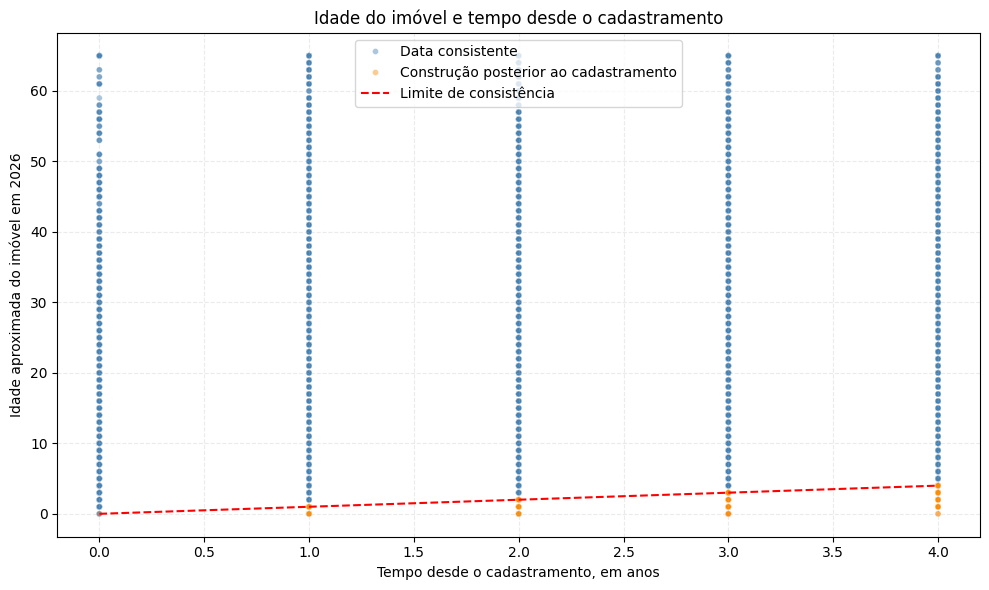

In [ ]:
# Selecionar os registros que possuem as duas idades calculadas
dados_grafico_temporal = dados_trabalho.dropna(
    subset=[
        'IDADE_CADASTRO',
        'IDADE_IMOVEL'
    ]
)

# Criar o gráfico
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=dados_grafico_temporal,
    x='IDADE_CADASTRO',
    y='IDADE_IMOVEL',
    hue='CONSISTENCIA_TEMPORAL',
    palette={
        'Data consistente': 'steelblue',
        'Construção posterior ao cadastramento': 'darkorange'
    },
    alpha=0.45,
    s=18
)

# Limite horizontal observado nos dados
limite_cadastro = (
    dados_grafico_temporal[
        'IDADE_CADASTRO'
    ].max()
)

# Linha de referência
plt.plot(
    [0, limite_cadastro],
    [0, limite_cadastro],
    color='red',
    linestyle='--',
    label='Limite de consistência'
)

plt.title(
    'Idade do imóvel e tempo desde o cadastramento'
)

plt.xlabel(
    'Tempo desde o cadastramento, em anos'
)

plt.ylabel(
    'Idade aproximada do imóvel em 2026'
)

plt.grid(
    linestyle='--',
    alpha=0.25
)

plt.legend()

plt.tight_layout()
plt.show()

#### Interpretação do gráfico

A maior parte dos imóveis apresenta idade superior ao tempo transcorrido desde o cadastramento. Isso indica que, na maioria dos casos, os imóveis já haviam sido construídos quando foram cadastrados no sistema.

Os pontos acima da linha vermelha representam os registros com essa relação temporal esperada. Os pontos abaixo da linha indicam casos em que a construção foi registrada como posterior ao cadastramento.

Alguns pontos classificados como construção posterior aparecem sobre a linha porque os eixos utilizam idades calculadas somente com os anos, enquanto a classificação considera as datas completas, incluindo mês e dia.

### 4.3 Criação da década de construção

A variável `ANO_CONSTRUCAO` apresenta um nível de detalhamento que pode dificultar a visualização da distribuição temporal dos imóveis. Para facilitar a interpretação, será criada a variável `DECADA_CONSTRUCAO`.

A década será obtida dividindo o ano por 10, considerando somente a parte inteira, e multiplicando o resultado novamente por 10. Por exemplo:

- 1992 será classificado na década de 1990;
- 2007 será classificado na década de 2000;
- 2018 será classificado na década de 2010.

Também será criada a variável textual `FAIXA_DECADA_CONSTRUCAO`, que será utilizada nos gráficos e no Power BI.

Os registros sem data de construção serão classificados como `Não informado`.

In [ ]:
# Calcular a década de construção
dados_trabalho['DECADA_CONSTRUCAO'] = (
    dados_trabalho['ANO_CONSTRUCAO']
    // 10
    * 10
).astype('Int64')

In [ ]:
# Criar uma variável textual para a década
dados_trabalho['FAIXA_DECADA_CONSTRUCAO'] = (
    'Década de '
    + dados_trabalho[
        'DECADA_CONSTRUCAO'
    ].astype('string')
)

# Classificar os valores ausentes
dados_trabalho['FAIXA_DECADA_CONSTRUCAO'] = (
    dados_trabalho[
        'FAIXA_DECADA_CONSTRUCAO'
    ]
    .fillna('Não informado')
)

In [ ]:
# Conferência
dados_trabalho[
    [
        'DATA_CONSTRUCAO',
        'ANO_CONSTRUCAO',
        'DECADA_CONSTRUCAO',
        'FAIXA_DECADA_CONSTRUCAO'
    ]
].head(20)

,DATA_CONSTRUCAO,ANO_CONSTRUCAO,DECADA_CONSTRUCAO,FAIXA_DECADA_CONSTRUCAO
0,1992-04-02,1992.0,1990,Década de 1990
1,2018-04-16,2018.0,2010,Década de 2010
2,2017-01-24,2017.0,2010,Década de 2010
3,2000-12-27,2000.0,2000,Década de 2000
4,2018-02-20,2018.0,2010,Década de 2010
5,2014-12-15,2014.0,2010,Década de 2010
6,1991-06-21,1991.0,1990,Década de 1990
7,NaT,NaN,<NA>,Não informado
8,2001-06-12,2001.0,2000,Década de 2000
9,1993-03-18,1993.0,1990,Década de 1990


In [ ]:
# Distribuição
dados_trabalho[
    'FAIXA_DECADA_CONSTRUCAO'
].value_counts(
    dropna=False
).sort_index()

,count
FAIXA_DECADA_CONSTRUCAO,
Década de 1960,2887
Década de 1970,2903
Década de 1980,6713
Década de 1990,14995
Década de 2000,16733
Década de 2010,23812
Década de 2020,16729
Não informado,10198


### 4.4 Criação das faixas de idade dos imóveis

Para facilitar a interpretação da idade aproximada dos imóveis, será criada a variável categórica `FAIXA_IDADE_IMOVEL`.

Os imóveis serão classificados nas seguintes faixas:

- até 5 anos;
- de 6 a 10 anos;
- de 11 a 20 anos;
- de 21 a 30 anos;
- de 31 a 50 anos;
- mais de 50 anos;
- não informado.

Também será criada `ORDEM_FAIXA_IDADE`, uma variável auxiliar que permitirá organizar corretamente as categorias no Power BI.

In [ ]:
# Definir as condições das faixas de idade
condicoes_idade = [
    dados_trabalho['IDADE_IMOVEL'].between(0, 5),
    dados_trabalho['IDADE_IMOVEL'].between(6, 10),
    dados_trabalho['IDADE_IMOVEL'].between(11, 20),
    dados_trabalho['IDADE_IMOVEL'].between(21, 30),
    dados_trabalho['IDADE_IMOVEL'].between(31, 50),
    dados_trabalho['IDADE_IMOVEL'] > 50
]

# Definir os nomes das categorias
categorias_idade = [
    'Até 5 anos',
    'De 6 a 10 anos',
    'De 11 a 20 anos',
    'De 21 a 30 anos',
    'De 31 a 50 anos',
    'Mais de 50 anos'
]

# Criar a variável de faixa de idade
dados_trabalho['FAIXA_IDADE_IMOVEL'] = np.select(
    condicoes_idade,
    categorias_idade,
    default='Não informado'
)

In [ ]:
# Definir a ordem das faixas
mapa_ordem_idade = {
    'Até 5 anos': 1,
    'De 6 a 10 anos': 2,
    'De 11 a 20 anos': 3,
    'De 21 a 30 anos': 4,
    'De 31 a 50 anos': 5,
    'Mais de 50 anos': 6,
    'Não informado': 7
}

# Criar a variável auxiliar de ordenação
dados_trabalho['ORDEM_FAIXA_IDADE'] = (
    dados_trabalho['FAIXA_IDADE_IMOVEL']
    .map(mapa_ordem_idade)
    .astype('Int64')
)

In [ ]:
# Conferência
dados_trabalho[
    [
        'IDADE_IMOVEL',
        'FAIXA_IDADE_IMOVEL',
        'ORDEM_FAIXA_IDADE'
    ]
].head(20)

,IDADE_IMOVEL,FAIXA_IDADE_IMOVEL,ORDEM_FAIXA_IDADE
0,34.0,De 31 a 50 anos,5
1,8.0,De 6 a 10 anos,2
2,9.0,De 6 a 10 anos,2
3,26.0,De 21 a 30 anos,4
4,8.0,De 6 a 10 anos,2
5,12.0,De 11 a 20 anos,3
6,35.0,De 31 a 50 anos,5
7,NaN,Não informado,7
8,25.0,De 21 a 30 anos,4
9,33.0,De 31 a 50 anos,5


## 5. Registros e imóveis distintos

Cada linha do dataset representa um registro relacionado ao ITBI. Entretanto, um mesmo imóvel pode aparecer em mais de uma linha, pois pode estar associado a diferentes declarações ou operações.

Por esse motivo, é necessário distinguir:

- **quantidade de registros:** número de linhas da base;
- **quantidade de operações:** quantidade de valores distintos de `NUM_DTI`;
- **quantidade de imóveis:** quantidade de valores distintos de `ID_IMOVEL`.

Nas análises sobre características dos imóveis, como bairro, idade, década de construção e tipo de uso, cada imóvel deverá ser contado uma única vez.

Nas análises sobre a movimentação dos registros de ITBI, todas as linhas ou operações poderão ser consideradas.

In [ ]:
# Contar quantos imóveis aparecem mais de uma vez
quantidade_imoveis_repetidos = (
    dados_trabalho['ID_IMOVEL']
    .value_counts()
    .gt(1)
    .sum()
)

# Construir um resumo das unidades de contagem
resumo_unidades = pd.Series({
    'QUANTIDADE_REGISTROS': len(dados_trabalho),

    'OPERACOES_DISTINTAS': (
        dados_trabalho['NUM_DTI'].nunique()
    ),

    'IMOVEIS_DISTINTOS': (
        dados_trabalho['ID_IMOVEL'].nunique()
    ),

    'IMOVEIS_COM_MAIS_DE_UM_REGISTRO': (
        quantidade_imoveis_repetidos
    )
})

resumo_unidades

,0
QUANTIDADE_REGISTROS,94970
OPERACOES_DISTINTAS,94970
IMOVEIS_DISTINTOS,80008
IMOVEIS_COM_MAIS_DE_UM_REGISTRO,11838


### Criação da base de imóveis distintos

A base de trabalho contém 94.970 operações imobiliárias, associadas a 80.008 imóveis distintos. Portanto, alguns imóveis aparecem em mais de uma operação ao longo do período analisado.

Para análises relacionadas às características dos imóveis, como idade, área, padrão construtivo e localização, a repetição de um mesmo imóvel poderia atribuir peso excessivo às propriedades com mais operações registradas.

Por esse motivo, será criada uma base complementar contendo apenas um registro para cada `ID_IMOVEL`. Quando houver mais de um registro para o mesmo imóvel, será mantido aquele que possuir a data de cadastramento mais recente.

A base original de operações continuará preservada em `dados_trabalho`, enquanto a nova base, denominada `base_imoveis`, será utilizada nas análises em que a unidade de observação deve ser o imóvel.

### Seleção do registro mais recente de cada imóvel

Como alguns imóveis aparecem em mais de uma operação, será criada uma base contendo apenas um registro por `ID_IMOVEL`.

Para cada imóvel, será mantido o registro com a data de cadastramento mais recente. Esse procedimento evita que imóveis negociados mais vezes tenham peso excessivo nas análises de idade, área, padrão construtivo, uso e localização.

In [ ]:
# Criar uma base com apenas o registro mais recente de cada imóvel
base_imoveis = (
    dados_trabalho
    .sort_values('DATA_CADASTRAMENTO_GI_IMOVEL')
    .drop_duplicates(
        subset='ID_IMOVEL',
        keep='last'
    )
    .copy()
)

# Validar a nova base
validacao_base_imoveis = pd.Series({
    'REGISTROS_NA_BASE': len(base_imoveis),
    'IMOVEIS_DISTINTOS': base_imoveis['ID_IMOVEL'].nunique(),
    'IDS_DUPLICADOS': base_imoveis['ID_IMOVEL'].duplicated().sum()
})

validacao_base_imoveis

,0
REGISTROS_NA_BASE,80008
IMOVEIS_DISTINTOS,80008
IDS_DUPLICADOS,0


In [ ]:
# Conferindo
base_imoveis

,NUM_DTI,EXERCICIO,DATA_CADASTRAMENTO_GI_IMOVEL,NUMERO_CEP,BAIRRO,LOGRADOURO,NUMERO,XSIRGAS2000,YSIRGAS2000,QTD_FRENTES,...,IND_COMPRA_VIA_PROGRAMA_HABITACIONAL,ANO_CADASTRAMENTO,ANO_CONSTRUCAO,IDADE_CADASTRO,IDADE_IMOVEL,CONSISTENCIA_TEMPORAL,DECADA_CONSTRUCAO,FAIXA_DECADA_CONSTRUCAO,FAIXA_IDADE_IMOVEL,ORDEM_FAIXA_IDADE
94969,jan/22,2022,2022-01-03 08:21:00,60532400,CONJUNTO CEARÁ I,R 860 (CONJ. CEARA I),100.0,544510.5832,9583321.231,1,...,Nenhum,2022,1999.0,4,27.0,Data consistente,1990,Década de 1990,De 21 a 30 anos,4
94968,mar/22,2022,2022-01-03 09:14:00,60833252,SAPIRANGA / COITÉ,R EUCLIDES ONOFRE DE SOUZA,885.0,558539.8279,9580271.796,2,...,Nenhum,2022,2014.0,4,12.0,Data consistente,2010,Década de 2010,De 11 a 20 anos,3
94967,abr/22,2022,2022-01-03 09:33:00,60411200,FÁTIMA,R GAL SILVA JUNIOR,640.0,551968.0638,9585013.925,1,...,Sistema Financeiro de Habitação,2022,2014.0,4,12.0,Data consistente,2010,Década de 2010,De 11 a 20 anos,3
94965,jun/22,2022,2022-01-03 09:35:00,60765372,MONDUBIM,R LAUREANO LEAL,1222.0,545974.7251,9577274.133,1,...,Nenhum,2022,2007.0,4,19.0,Data consistente,2000,Década de 2000,De 11 a 20 anos,3
94964,jul/22,2022,2022-01-03 10:07:00,60871660,COAÇU,AV GURGEL DO AMARAL,1234.0,557104.8823,9575952.386,1,...,Nenhum,2022,2008.0,4,18.0,Data consistente,2000,Década de 2000,De 11 a 20 anos,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2183/2026,2026,2026-02-02 18:03:00,60810160,GUARARAPES,AV CEL MIGUEL DIAS,1140.0,556865.7646,9583683.861,1,...,Nenhum,2026,2018.0,0,8.0,Data consistente,2010,Década de 2010,De 6 a 10 anos,2
3,2184/2026,2026,2026-02-02 18:28:00,60844160,LAGOA REDONDA,R AMBROSIO DE CARVALHO,725.0,558541.9632,9577213.750,4,...,Sistema Financeiro de Habitação,2026,2000.0,0,26.0,Data consistente,2000,Década de 2000,De 21 a 30 anos,4
2,2185/2026,2026,2026-02-02 23:26:00,60712025,JARDIM CEARENSE,R RUBENS MONTE,120.0,547751.1246,9579955.591,2,...,Nenhum,2026,2017.0,0,9.0,Data consistente,2010,Década de 2010,De 6 a 10 anos,2
1,2186/2026,2026,2026-02-03 05:52:00,60714750,RACHEL DE QUEIROZ,R A (LOT. MRV MAGIS - DENDE),90.0,548696.4234,9580601.625,1,...,Nenhum,2026,2018.0,0,8.0,Data consistente,2010,Década de 2010,De 6 a 10 anos,2


### Distribuição dos imóveis por faixa de idade

Após a criação da base de imóveis distintos, será analisada a distribuição das propriedades por faixa de idade.

Nesta análise, cada imóvel será contabilizado apenas uma vez. Serão apresentadas a quantidade de imóveis e a participação percentual de cada faixa em relação ao total de imóveis da base.

In [ ]:
# Distribuição dos imóveis distintos por faixa de idade
distribuicao_faixa_idade = (
    base_imoveis
    .groupby(
        ['ORDEM_FAIXA_IDADE', 'FAIXA_IDADE_IMOVEL'],
        dropna=False
    )
    .size()
    .reset_index(name='QUANTIDADE_IMOVEIS')
    .sort_values('ORDEM_FAIXA_IDADE')
)

# Calcular o percentual
distribuicao_faixa_idade['PERCENTUAL'] = (
    distribuicao_faixa_idade['QUANTIDADE_IMOVEIS']
    .div(len(base_imoveis))
    .mul(100)
    .round(2)
)

# Remover a coluna auxiliar da apresentação
distribuicao_faixa_idade = (
    distribuicao_faixa_idade
    .drop(columns='ORDEM_FAIXA_IDADE')
)

distribuicao_faixa_idade

,FAIXA_IDADE_IMOVEL,QUANTIDADE_IMOVEIS,PERCENTUAL
0,Até 5 anos,14071,17.59
1,De 6 a 10 anos,7159,8.95
2,De 11 a 20 anos,18996,23.74
3,De 21 a 30 anos,12262,15.33
4,De 31 a 50 anos,15178,18.97
5,Mais de 50 anos,3547,4.43
6,Não informado,8795,10.99


### Resultado da distribuição por faixa de idade

A faixa com maior participação é a de imóveis com idade entre 11 e 20 anos, representando 23,74% da base. Em seguida, aparecem os imóveis de 31 a 50 anos, com 18,97%, e aqueles com até 5 anos, com 17,59%.

Os imóveis com mais de 50 anos representam 4,43%, constituindo a faixa menos frequente entre os registros com idade conhecida.

Para 10,99% dos imóveis, não foi possível determinar a idade devido à ausência da data de construção. Esses registros foram mantidos na categoria “Não informado”.

Os resultados consideram somente os 80.008 imóveis distintos, evitando que propriedades presentes em mais de uma operação sejam contabilizadas repetidamente.

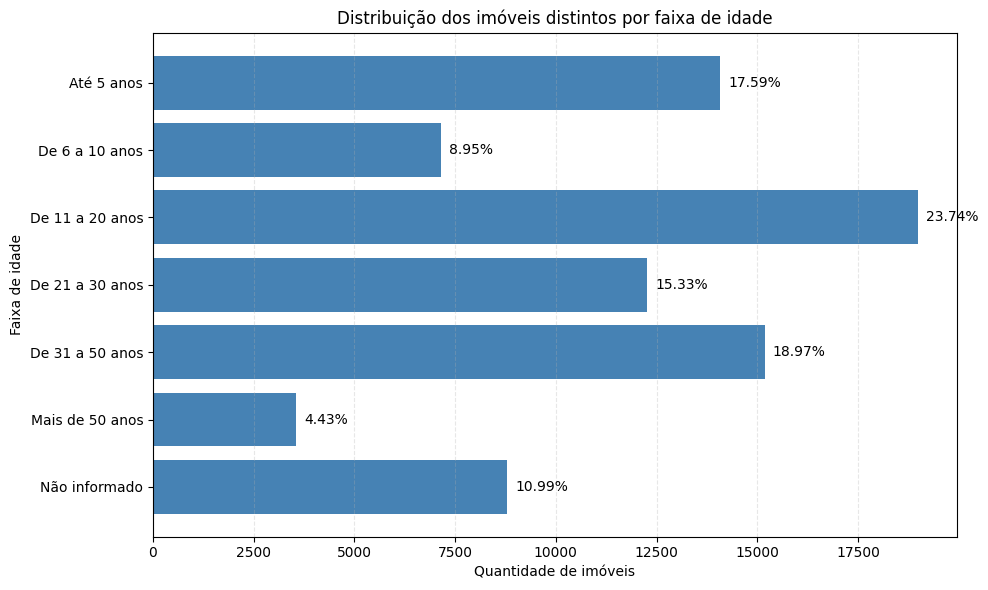

In [ ]:
# Criar o gráfico da distribuição por faixa de idade
plt.figure(figsize=(10, 6))

barras = plt.barh(
    distribuicao_faixa_idade['FAIXA_IDADE_IMOVEL'],
    distribuicao_faixa_idade['QUANTIDADE_IMOVEIS'],
    color='steelblue'
)

# Apresentar os percentuais nas barras
for barra, percentual in zip(
    barras,
    distribuicao_faixa_idade['PERCENTUAL']
):
    plt.text(
        barra.get_width() + 200,
        barra.get_y() + barra.get_height() / 2,
        f'{percentual:.2f}%',
        va='center'
    )

plt.title('Distribuição dos imóveis distintos por faixa de idade')
plt.xlabel('Quantidade de imóveis')
plt.ylabel('Faixa de idade')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Os imóveis com mais de 50 anos constituem a menor faixa analisada, correspondendo a 3.547 propriedades, ou 4,43% dos imóveis distintos.

Esse resultado indica uma presença relativamente pequena de imóveis antigos entre as propriedades registradas na base de operações de ITBI. Entretanto, não deve ser interpretado como uma representação completa do estoque imobiliário de Fortaleza, pois a base reúne apenas imóveis vinculados às operações registradas no período analisado.

Além disso, 10,99% dos imóveis não possuem data de construção informada, impossibilitando sua classificação por idade.

### Distribuição dos imóveis por década de construção

A década de construção permite observar a composição etária dos imóveis registrados na base.

Nesta análise, será utilizada a `base_imoveis`, que contém apenas o registro mais recente de cada imóvel. Dessa forma, propriedades presentes em mais de uma operação serão contabilizadas somente uma vez.

Serão apresentadas a quantidade e a participação percentual dos imóveis em cada década de construção. Os imóveis sem data de construção permanecerão classificados como “Não informado”.

In [ ]:
# Distribuição dos imóveis distintos por década de construção
distribuicao_decada = (
    base_imoveis
    .groupby(
        ['DECADA_CONSTRUCAO', 'FAIXA_DECADA_CONSTRUCAO'],
        dropna=False
    )
    .size()
    .reset_index(name='QUANTIDADE_IMOVEIS')
    .sort_values(
        'DECADA_CONSTRUCAO',
        na_position='last'
    )
)

# Calcular a participação percentual
distribuicao_decada['PERCENTUAL'] = (
    distribuicao_decada['QUANTIDADE_IMOVEIS']
    .div(len(base_imoveis))
    .mul(100)
    .round(2)
)

# Selecionar as colunas apresentadas
distribuicao_decada = distribuicao_decada[
    [
        'FAIXA_DECADA_CONSTRUCAO',
        'QUANTIDADE_IMOVEIS',
        'PERCENTUAL'
    ]
]

distribuicao_decada

,FAIXA_DECADA_CONSTRUCAO,QUANTIDADE_IMOVEIS,PERCENTUAL
0,Década de 1960,2491,3.11
1,Década de 1970,2423,3.03
2,Década de 1980,5914,7.39
3,Década de 1990,12625,15.78
4,Década de 2000,14120,17.65
5,Década de 2010,19007,23.76
6,Década de 2020,14633,18.29
7,Não informado,8795,10.99


### Resultado da distribuição por década de construção

A década de 2010 apresenta a maior quantidade de imóveis, com 19.007 propriedades, correspondendo a 23,76% da base.

Em seguida, aparecem a década de 2020, com 18,29%, e a década de 2000, com 17,65%. Em conjunto, os imóveis construídos a partir do ano 2000 representam 59,70% dos imóveis distintos analisados.

As décadas de 1960 e 1970 apresentam as menores participações, com 3,11% e 3,03%, respectivamente.

Para 8.795 imóveis, correspondentes a 10,99% da base, não foi possível identificar a década de construção devido à ausência dessa informação.

Esses resultados representam os imóveis presentes na base de operações de ITBI e não necessariamente todo o estoque imobiliário de Fortaleza.

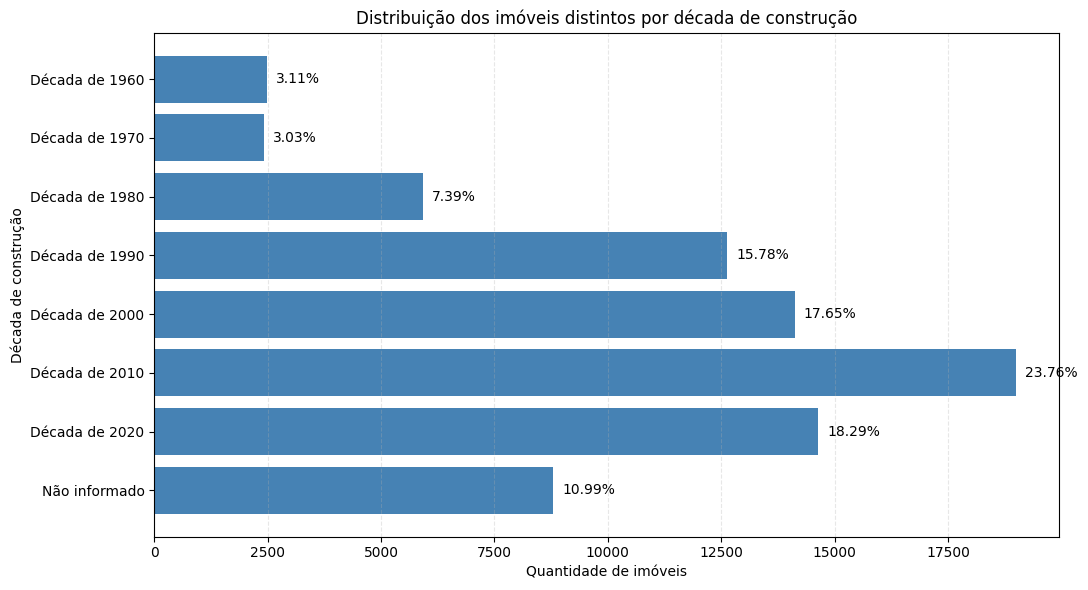

In [ ]:
# Criar o gráfico da distribuição por década de construção
plt.figure(figsize=(11, 6))

barras = plt.barh(
    distribuicao_decada['FAIXA_DECADA_CONSTRUCAO'],
    distribuicao_decada['QUANTIDADE_IMOVEIS'],
    color='steelblue'
)

# Apresentar os percentuais ao lado das barras
for barra, percentual in zip(
    barras,
    distribuicao_decada['PERCENTUAL']
):
    plt.text(
        barra.get_width() + 200,
        barra.get_y() + barra.get_height() / 2,
        f'{percentual:.2f}%',
        va='center'
    )

plt.title('Distribuição dos imóveis distintos por década de construção')
plt.xlabel('Quantidade de imóveis')
plt.ylabel('Década de construção')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Preparação das informações espaciais

As variáveis `XSIRGAS2000` e `YSIRGAS2000` representam as coordenadas espaciais dos imóveis no sistema de referência SIRGAS 2000.

Essas coordenadas serão posteriormente convertidas para latitude e longitude, formato utilizado na construção de mapas no Power BI.

Antes da conversão, será verificada a quantidade de coordenadas ausentes e se a ausência ocorre simultaneamente nas duas variáveis. Os registros sem coordenadas também serão apresentados com suas informações de endereço para avaliar a possibilidade de geocodificação.

In [ ]:
# Identificar registros com alguma coordenada ausente
filtro_coordenada_ausente = (
    dados_trabalho['XSIRGAS2000'].isna()
    | dados_trabalho['YSIRGAS2000'].isna()
)

# Resumo das coordenadas
resumo_coordenadas = pd.Series({
    'TOTAL_REGISTROS': len(dados_trabalho),

    'X_AUSENTE': (
        dados_trabalho['XSIRGAS2000']
        .isna()
        .sum()
    ),

    'Y_AUSENTE': (
        dados_trabalho['YSIRGAS2000']
        .isna()
        .sum()
    ),

    'ALGUMA_COORDENADA_AUSENTE': (
        filtro_coordenada_ausente.sum()
    ),

    'AMBAS_COORDENADAS_AUSENTES': (
        dados_trabalho[
            ['XSIRGAS2000', 'YSIRGAS2000']
        ]
        .isna()
        .all(axis=1)
        .sum()
    )
})

resumo_coordenadas

,0
TOTAL_REGISTROS,94970
X_AUSENTE,6
Y_AUSENTE,6
ALGUMA_COORDENADA_AUSENTE,6
AMBAS_COORDENADAS_AUSENTES,6


In [ ]:
# Apresentar os registros sem coordenadas
dados_trabalho.loc[
    filtro_coordenada_ausente,
    [
        'ID_IMOVEL',
        'NUM_DTI',
        'NUMERO_CEP',
        'BAIRRO',
        'LOGRADOURO',
        'NUMERO',
        'XSIRGAS2000',
        'YSIRGAS2000'
    ]
]

,ID_IMOVEL,NUM_DTI,NUMERO_CEP,BAIRRO,LOGRADOURO,NUMERO,XSIRGAS2000,YSIRGAS2000
14656,1876013,14487/2025,60871070,MESSEJANA,R STA ANGELA,227.0,NaN,NaN
24128,1601790,3831/2025,60540524,GRANJA LISBOA,R MATEUS LEMOS,3754.0,NaN,NaN
53326,1984865,24263/2023,60836070,SABIAGUABA,R FRANCISCO SEVERIANO,NaN,NaN,NaN
59248,1876595,17896/2023,60871070,MESSEJANA,R STA ANGELA,412.0,NaN,NaN
66693,2037821,8854/2023,60540576,GRANJA LISBOA,R PAULINO ROCHA,2061.0,NaN,NaN
77552,2008243,21633/2022,60540513,GRANJA LISBOA,R SGT JOAO PINHEIRO,540.0,NaN,NaN


### Resultado da avaliação das coordenadas

Foram identificados seis registros sem valores nas variáveis `XSIRGAS2000` e `YSIRGAS2000`. Em todos os casos, as duas coordenadas estão ausentes simultaneamente.

Esses registros correspondem a aproximadamente 0,006% das 94.970 operações da base. Embora a quantidade seja pequena, serão analisadas as informações de endereço desses imóveis para verificar a possibilidade de recuperar suas coordenadas por meio de geocodificação.

In [ ]:
# Selecionar os registros que apresentam coordenadas ausentes
registros_sem_coordenadas = dados_trabalho.loc[

    # Selecionar somente as linhas em que X ou Y está ausente
    filtro_coordenada_ausente,

    # Selecionar as variáveis necessárias para identificar
    # o imóvel e realizar posteriormente a geocodificação
    [
        'ID_IMOVEL',       # Identificador do imóvel
        'NUM_DTI',         # Identificador da operação
        'NUMERO_CEP',      # CEP do endereço
        'BAIRRO',          # Bairro do imóvel
        'LOGRADOURO',      # Rua, avenida ou outro logradouro
        'NUMERO',          # Número do imóvel
        'XSIRGAS2000',     # Coordenada horizontal ausente
        'YSIRGAS2000'      # Coordenada vertical ausente
    ]

# Criar uma cópia independente da seleção
].copy()

# Apresentar a tabela com os registros sem coordenadas
registros_sem_coordenadas

,ID_IMOVEL,NUM_DTI,NUMERO_CEP,BAIRRO,LOGRADOURO,NUMERO,XSIRGAS2000,YSIRGAS2000
14656,1876013,14487/2025,60871070,MESSEJANA,R STA ANGELA,227.0,NaN,NaN
24128,1601790,3831/2025,60540524,GRANJA LISBOA,R MATEUS LEMOS,3754.0,NaN,NaN
53326,1984865,24263/2023,60836070,SABIAGUABA,R FRANCISCO SEVERIANO,NaN,NaN,NaN
59248,1876595,17896/2023,60871070,MESSEJANA,R STA ANGELA,412.0,NaN,NaN
66693,2037821,8854/2023,60540576,GRANJA LISBOA,R PAULINO ROCHA,2061.0,NaN,NaN
77552,2008243,21633/2022,60540513,GRANJA LISBOA,R SGT JOAO PINHEIRO,540.0,NaN,NaN


### Conversão das coordenadas para latitude e longitude

Os seis registros sem coordenadas possuem informações de endereço suficientes para uma tentativa posterior de geocodificação. Cinco apresentam CEP, logradouro, bairro e número; apenas um não possui o número do imóvel.

Antes da geocodificação, as coordenadas já existentes serão convertidas do sistema SIRGAS 2000 / UTM zona 24S para latitude e longitude no sistema WGS 84.

A latitude e a longitude são mais adequadas para a construção de mapas em ferramentas de Business Intelligence, como o Power BI.

In [ ]:
# Criar o transformador de coordenadas
# EPSG:31984 = SIRGAS 2000 / UTM zona 24S
# EPSG:4326  = latitude e longitude em WGS 84
transformador = Transformer.from_crs(
    'EPSG:31984',
    'EPSG:4326',
    always_xy=True
)

# Selecionar os registros com as duas coordenadas preenchidas
filtro_coordenadas_validas = (
    dados_trabalho['XSIRGAS2000'].notna()
    & dados_trabalho['YSIRGAS2000'].notna()
)

# Converter X e Y para longitude e latitude
longitudes, latitudes = transformador.transform(
    dados_trabalho.loc[
        filtro_coordenadas_validas,
        'XSIRGAS2000'
    ].to_numpy(),

    dados_trabalho.loc[
        filtro_coordenadas_validas,
        'YSIRGAS2000'
    ].to_numpy()
)

# Criar as novas variáveis
dados_trabalho.loc[
    filtro_coordenadas_validas,
    'LONGITUDE'
] = longitudes

dados_trabalho.loc[
    filtro_coordenadas_validas,
    'LATITUDE'
] = latitudes

# Registrar a origem das coordenadas
dados_trabalho['ORIGEM_COORDENADA'] = 'SIRGAS 2000'

dados_trabalho.loc[
    filtro_coordenada_ausente,
    'ORIGEM_COORDENADA'
] = 'Coordenada ausente'

# Conferir o resultado
dados_trabalho[
    [
        'XSIRGAS2000',
        'YSIRGAS2000',
        'LATITUDE',
        'LONGITUDE',
        'ORIGEM_COORDENADA'
    ]
].head()

,XSIRGAS2000,YSIRGAS2000,LATITUDE,LONGITUDE,ORIGEM_COORDENADA
0,552894.0129,9575866.301,-3.837080,-38.523600,SIRGAS 2000
1,548696.4234,9580601.625,-3.794261,-38.561427,SIRGAS 2000
2,547751.1246,9579955.591,-3.800110,-38.569937,SIRGAS 2000
3,558541.9632,9577213.750,-3.824860,-38.472739,SIRGAS 2000
4,556865.7646,9583683.861,-3.766337,-38.487870,SIRGAS 2000


### Validação das coordenadas convertidas

Após a conversão para latitude e longitude, será verificado se as coordenadas estão dentro de limites geográficos compatíveis com o município de Fortaleza.

Essa validação permite identificar possíveis erros de conversão, inversão entre latitude e longitude ou coordenadas incompatíveis com a área analisada.

In [ ]:
# Apresentar os valores mínimos e máximos
resumo_limites_coordenadas = dados_trabalho[
    ['LATITUDE', 'LONGITUDE']
].agg(['min', 'max'])

resumo_limites_coordenadas

,LATITUDE,LONGITUDE
min,-3.892799,-38.633933
max,-3.697032,-38.411031


In [ ]:
# Definir limites geográficos aproximados para a região de Fortaleza
filtro_fora_limites = (
    dados_trabalho['LATITUDE'].notna()
    & dados_trabalho['LONGITUDE'].notna()
    & (
        ~dados_trabalho['LATITUDE'].between(-4.0, -3.5)
        | ~dados_trabalho['LONGITUDE'].between(-38.8, -38.3)
    )
)

# Contar coordenadas fora dos limites esperados
print(
    'Registros fora dos limites geográficos esperados:',
    filtro_fora_limites.sum()
)

Registros fora dos limites geográficos esperados: 0


In [ ]:
dados_trabalho[
    ['LATITUDE', 'LONGITUDE']
].isna().sum()

,0
LATITUDE,6
LONGITUDE,6


### Geocodificação dos registros sem coordenadas

Os seis registros sem latitude e longitude serão submetidos a um processo de geocodificação utilizando o serviço Nominatim, acessado pela biblioteca `geopy`.

A geocodificação transforma informações textuais de endereço, como logradouro, número, bairro, CEP, município e estado, em coordenadas geográficas.

Para respeitar os limites de utilização do serviço, será aplicado um intervalo mínimo entre as consultas. Os endereços que não forem localizados automaticamente permanecerão com coordenadas ausentes para posterior avaliação.

In [ ]:
# Configurar o serviço de geocodificação
geolocalizador = Nominatim(
    user_agent='analise_itbi_fortaleza_2026'
)

# Estabelecer um intervalo mínimo entre as consultas
geocodificar = RateLimiter(
    geolocalizador.geocode,
    min_delay_seconds=1,
    swallow_exceptions=True
)

# Função para construir o endereço de cada registro
def construir_endereco(linha):

    partes_endereco = []

    # Adicionar o logradouro
    if pd.notna(linha['LOGRADOURO']):
        partes_endereco.append(str(linha['LOGRADOURO']).strip())

    # Adicionar o número, quando estiver disponível
    if pd.notna(linha['NUMERO']):
        partes_endereco.append(str(int(linha['NUMERO'])))

    # Adicionar o bairro
    if pd.notna(linha['BAIRRO']):
        partes_endereco.append(str(linha['BAIRRO']).strip())

    # Adicionar o município e o estado
    partes_endereco.extend([
        'Fortaleza',
        'Ceará',
        'Brasil'
    ])

    # Adicionar o CEP, quando estiver disponível
    if pd.notna(linha['NUMERO_CEP']):
        partes_endereco.append(str(linha['NUMERO_CEP']).strip())

    return ', '.join(partes_endereco)


# Construir os endereços dos seis registros
registros_sem_coordenadas[
    'ENDERECO_GEOCODIFICACAO'
] = registros_sem_coordenadas.apply(
    construir_endereco,
    axis=1
)

# Conferir os endereços que serão consultados
registros_sem_coordenadas[
    [
        'ID_IMOVEL',
        'ENDERECO_GEOCODIFICACAO'
    ]
]

,ID_IMOVEL,ENDERECO_GEOCODIFICACAO
14656,1876013,"R STA ANGELA, 227, MESSEJANA, Fortaleza, Ceará..."
24128,1601790,"R MATEUS LEMOS, 3754, GRANJA LISBOA, Fortalez..."
53326,1984865,"R FRANCISCO SEVERIANO, SABIAGUABA, Fortaleza,..."
59248,1876595,"R STA ANGELA, 412, MESSEJANA, Fortaleza, Ceará..."
66693,2037821,"R PAULINO ROCHA, 2061, GRANJA LISBOA, Fortale..."
77552,2008243,"R SGT JOAO PINHEIRO, 540, GRANJA LISBOA, Forta..."


In [ ]:
# Consultar as coordenadas dos endereços
registros_sem_coordenadas['LOCALIZACAO'] = (
    registros_sem_coordenadas[
        'ENDERECO_GEOCODIFICACAO'
    ]
    .apply(geocodificar)
)

# Extrair latitude e longitude dos endereços encontrados
registros_sem_coordenadas['LATITUDE_OBTIDA'] = (
    registros_sem_coordenadas['LOCALIZACAO']
    .apply(
        lambda local: local.latitude
        if local is not None
        else np.nan
    )
)

registros_sem_coordenadas['LONGITUDE_OBTIDA'] = (
    registros_sem_coordenadas['LOCALIZACAO']
    .apply(
        lambda local: local.longitude
        if local is not None
        else np.nan
    )
)

# Apresentar o resultado da tentativa automática
registros_sem_coordenadas[
    [
        'ID_IMOVEL',
        'ENDERECO_GEOCODIFICACAO',
        'LATITUDE_OBTIDA',
        'LONGITUDE_OBTIDA'
    ]
]

,ID_IMOVEL,ENDERECO_GEOCODIFICACAO,LATITUDE_OBTIDA,LONGITUDE_OBTIDA
14656,1876013,"R STA ANGELA, 227, MESSEJANA, Fortaleza, Ceará...",NaN,NaN
24128,1601790,"R MATEUS LEMOS, 3754, GRANJA LISBOA, Fortalez...",NaN,NaN
53326,1984865,"R FRANCISCO SEVERIANO, SABIAGUABA, Fortaleza,...",NaN,NaN
59248,1876595,"R STA ANGELA, 412, MESSEJANA, Fortaleza, Ceará...",NaN,NaN
66693,2037821,"R PAULINO ROCHA, 2061, GRANJA LISBOA, Fortale...",NaN,NaN
77552,2008243,"R SGT JOAO PINHEIRO, 540, GRANJA LISBOA, Forta...",NaN,NaN


### Segunda tentativa de geocodificação

A primeira consulta não encontrou correspondência para os seis endereços. Isso não significa que os endereços sejam inválidos, pois a base utiliza abreviações como `R`, `STA` e `SGT`, que podem não ser reconhecidas pelo serviço de geocodificação.

Será realizada uma segunda tentativa com os nomes dos logradouros normalizados. Para cada registro, serão testadas consultas progressivamente menos restritivas: endereço completo, endereço sem CEP, logradouro sem número e, por último, CEP e município.

Quando uma busca menos específica for utilizada, a coordenada obtida poderá representar uma localização aproximada.

In [ ]:
# Função para substituir abreviações dos logradouros
def normalizar_logradouro(logradouro):

    if pd.isna(logradouro):
        return ''

    logradouro = str(logradouro).strip()

    substituicoes = {
        'R ': 'Rua ',
        'STA ': 'Santa ',
        'SGT ': 'Sargento '
    }

    for abreviacao, nome_completo in substituicoes.items():
        logradouro = logradouro.replace(
            abreviacao,
            nome_completo
        )

    return logradouro


# Função para realizar tentativas progressivas de geocodificação
def geocodificar_endereco(linha):

    logradouro = normalizar_logradouro(
        linha['LOGRADOURO']
    )

    bairro = str(linha['BAIRRO']).strip()

    cep = (
        str(linha['NUMERO_CEP']).strip()
        if pd.notna(linha['NUMERO_CEP'])
        else ''
    )

    numero = (
        str(int(linha['NUMERO']))
        if pd.notna(linha['NUMERO'])
        else ''
    )

    # Consultas do endereço mais completo ao mais geral
    consultas = [
        (
            'Endereço completo',
            f'{logradouro}, {numero}, {bairro}, '
            f'Fortaleza, Ceará, Brasil, {cep}'
        ),

        (
            'Endereço sem CEP',
            f'{logradouro}, {numero}, {bairro}, '
            'Fortaleza, Ceará, Brasil'
        ),

        (
            'Logradouro sem número',
            f'{logradouro}, {bairro}, '
            'Fortaleza, Ceará, Brasil'
        ),

        (
            'CEP',
            f'{cep}, Fortaleza, Ceará, Brasil'
        )
    ]

    for tipo_consulta, consulta in consultas:

        localizacao = geocodificar(
            consulta,
            country_codes='br',
            addressdetails=True
        )

        if localizacao is not None:
            return pd.Series({
                'LATITUDE_OBTIDA': localizacao.latitude,
                'LONGITUDE_OBTIDA': localizacao.longitude,
                'TIPO_GEOCODIFICACAO': tipo_consulta,
                'CONSULTA_UTILIZADA': consulta,
                'ENDERECO_RETORNADO': localizacao.address
            })

    # Manter ausente quando nenhuma consulta encontrar correspondência
    return pd.Series({
        'LATITUDE_OBTIDA': np.nan,
        'LONGITUDE_OBTIDA': np.nan,
        'TIPO_GEOCODIFICACAO': 'Não localizado',
        'CONSULTA_UTILIZADA': pd.NA,
        'ENDERECO_RETORNADO': pd.NA
    })


# Realizar a segunda tentativa
resultado_geocodificacao = (
    registros_sem_coordenadas
    .apply(
        geocodificar_endereco,
        axis=1
    )
)

# Adicionar os resultados à tabela dos registros ausentes
for coluna in resultado_geocodificacao.columns:
    registros_sem_coordenadas[coluna] = (
        resultado_geocodificacao[coluna]
    )

# Conferir os resultados
registros_sem_coordenadas[
    [
        'ID_IMOVEL',
        'LATITUDE_OBTIDA',
        'LONGITUDE_OBTIDA',
        'TIPO_GEOCODIFICACAO',
        'ENDERECO_RETORNADO'
    ]
]

,ID_IMOVEL,LATITUDE_OBTIDA,LONGITUDE_OBTIDA,TIPO_GEOCODIFICACAO,ENDERECO_RETORNADO
14656,1876013,-3.834056,-38.499248,Endereço sem CEP,"Rua Santa Ângela, Messejana, Fortaleza, Ceará,..."
24128,1601790,-3.782542,-38.611614,Endereço sem CEP,"Rua Mateus Lemos, Granja Lisboa, Fortaleza, Ce..."
53326,1984865,-3.804279,-38.450534,Endereço sem CEP,"Rua Francisco Severiano, Sabiaguaba, Fortaleza..."
59248,1876595,-3.833930,-38.498109,Endereço sem CEP,"412, Rua Santa Ângela, Messejana, Fortaleza, C..."
66693,2037821,-3.788953,-38.626067,Endereço sem CEP,"Rua Paulino Rocha, Granja Lisboa, Fortaleza, C..."
77552,2008243,-3.789586,-38.624679,Endereço sem CEP,"Rua Sargento João Pinheiro, Granja Lisboa, For..."


### Preenchimento das coordenadas ausentes

A segunda tentativa de geocodificação encontrou correspondência para os seis registros que não possuíam coordenadas.

Os endereços retornados pelo serviço apresentaram correspondência com os logradouros e bairros informados na base. As latitudes e longitudes obtidas também estão dentro dos limites geográficos esperados para Fortaleza.

As coordenadas serão transferidas para a base de trabalho. Para manter a compatibilidade com as demais observações, os valores também serão convertidos de latitude e longitude para o sistema SIRGAS 2000.

A variável `ORIGEM_COORDENADA` permitirá diferenciar as coordenadas provenientes da base original daquelas estimadas por geocodificação.

In [ ]:
# Verificar quais resultados da geocodificação são válidos
filtro_geocodificacao_valida = (
    registros_sem_coordenadas['LATITUDE_OBTIDA']
    .between(-4.0, -3.5)
    &
    registros_sem_coordenadas['LONGITUDE_OBTIDA']
    .between(-38.8, -38.3)
)

# Obter os índices dos registros encontrados
indices_geocodificados = (
    registros_sem_coordenadas
    .loc[filtro_geocodificacao_valida]
    .index
)

# Transferir latitude e longitude para a base de trabalho
dados_trabalho.loc[
    indices_geocodificados,
    'LATITUDE'
] = registros_sem_coordenadas.loc[
    indices_geocodificados,
    'LATITUDE_OBTIDA'
]

dados_trabalho.loc[
    indices_geocodificados,
    'LONGITUDE'
] = registros_sem_coordenadas.loc[
    indices_geocodificados,
    'LONGITUDE_OBTIDA'
]

# Criar o transformador inverso:
# latitude/longitude para SIRGAS 2000 / UTM zona 24S
transformador_inverso = Transformer.from_crs(
    'EPSG:4326',
    'EPSG:31984',
    always_xy=True
)

# Converter as coordenadas geocodificadas para X e Y
x_obtido, y_obtido = transformador_inverso.transform(
    dados_trabalho.loc[
        indices_geocodificados,
        'LONGITUDE'
    ].to_numpy(),

    dados_trabalho.loc[
        indices_geocodificados,
        'LATITUDE'
    ].to_numpy()
)

# Preencher X e Y na base de trabalho
dados_trabalho.loc[
    indices_geocodificados,
    'XSIRGAS2000'
] = x_obtido

dados_trabalho.loc[
    indices_geocodificados,
    'YSIRGAS2000'
] = y_obtido

# Registrar a origem das coordenadas preenchidas
dados_trabalho.loc[
    indices_geocodificados,
    'ORIGEM_COORDENADA'
] = 'Geocodificação Nominatim'

In [ ]:
# Conferir as ausências após o preenchimento
validacao_final_coordenadas = pd.Series({
    'X_AUSENTE': dados_trabalho['XSIRGAS2000'].isna().sum(),
    'Y_AUSENTE': dados_trabalho['YSIRGAS2000'].isna().sum(),
    'LATITUDE_AUSENTE': dados_trabalho['LATITUDE'].isna().sum(),
    'LONGITUDE_AUSENTE': dados_trabalho['LONGITUDE'].isna().sum()
})

validacao_final_coordenadas

,0
X_AUSENTE,0
Y_AUSENTE,0
LATITUDE_AUSENTE,0
LONGITUDE_AUSENTE,0


In [ ]:
dados_trabalho[
    'ORIGEM_COORDENADA'
].value_counts(dropna=False)

,count
ORIGEM_COORDENADA,
SIRGAS 2000,94964
Geocodificação Nominatim,6


### Resultado do tratamento das coordenadas ausentes

As coordenadas dos seis registros ausentes foram recuperadas por meio da geocodificação dos respectivos endereços.

Após o procedimento, não existem valores ausentes nas variáveis `XSIRGAS2000`, `YSIRGAS2000`, `LATITUDE` e `LONGITUDE`.

Das 94.970 operações, 94.964 possuem coordenadas provenientes da base original e seis possuem coordenadas obtidas pelo serviço Nominatim. A variável `ORIGEM_COORDENADA` foi mantida para identificar a procedência das informações.

Como as coordenadas geocodificadas foram obtidas a partir dos endereços, algumas delas podem representar uma localização aproximada do imóvel.

### Distribuição espacial dos imóveis

Após o tratamento das coordenadas, será apresentada a distribuição espacial dos registros presentes na base de ITBI.

Os pontos azuis representam as coordenadas originalmente disponibilizadas na base. Os pontos vermelhos representam os seis registros cujas coordenadas foram obtidas por geocodificação dos endereços.

Essa visualização permite avaliar a distribuição territorial dos imóveis e verificar se as coordenadas geocodificadas estão inseridas na mesma região geográfica dos demais registros.

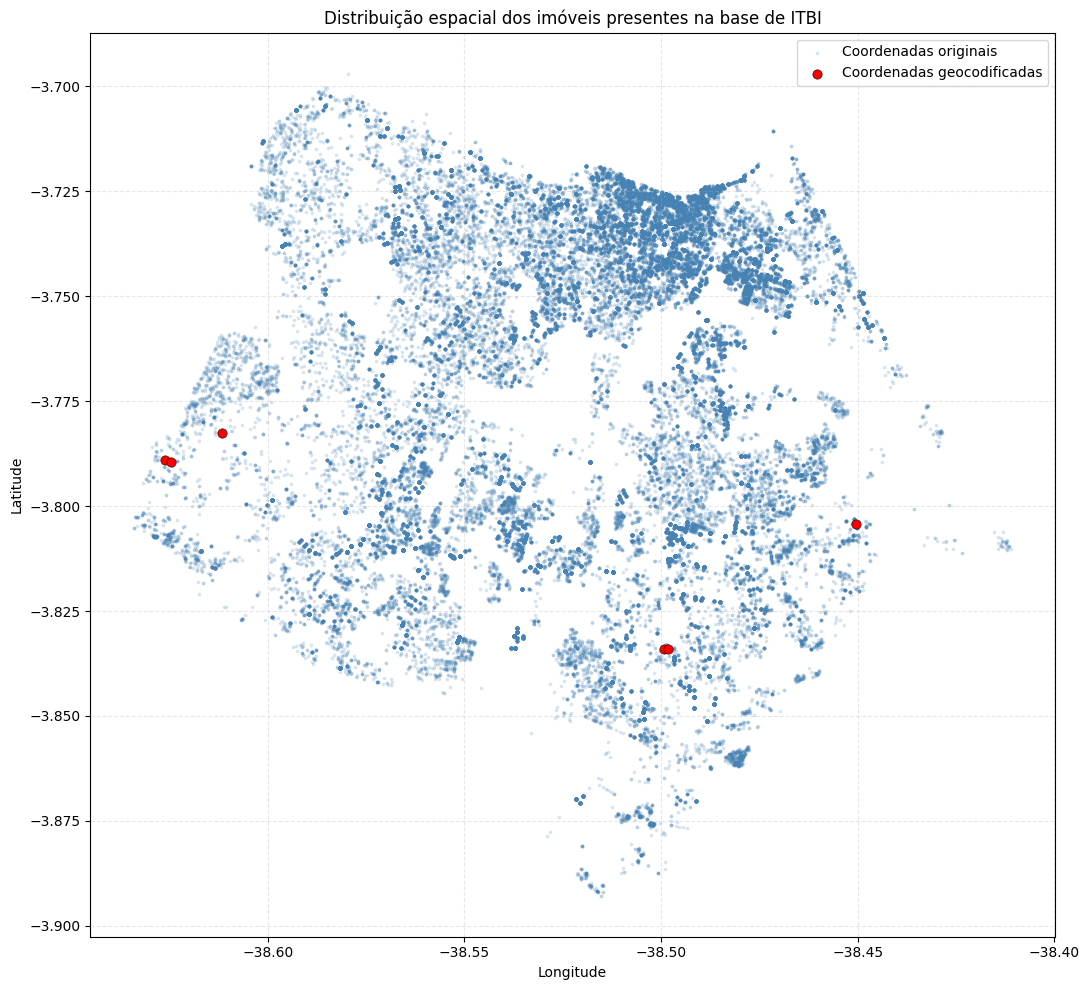

In [ ]:
# Separar as coordenadas originais e geocodificadas
coordenadas_originais = dados_trabalho[
    dados_trabalho['ORIGEM_COORDENADA']
    .eq('SIRGAS 2000')
]

coordenadas_geocodificadas = dados_trabalho[
    dados_trabalho['ORIGEM_COORDENADA']
    .eq('Geocodificação Nominatim')
]

# Criar o gráfico espacial
plt.figure(figsize=(11, 10))

# Apresentar as coordenadas originais
plt.scatter(
    coordenadas_originais['LONGITUDE'],
    coordenadas_originais['LATITUDE'],
    s=3,
    alpha=0.15,
    color='steelblue',
    label='Coordenadas originais'
)

# Destacar as coordenadas geocodificadas
plt.scatter(
    coordenadas_geocodificadas['LONGITUDE'],
    coordenadas_geocodificadas['LATITUDE'],
    s=45,
    color='red',
    edgecolor='black',
    linewidth=0.4,
    label='Coordenadas geocodificadas',
    zorder=3
)

plt.title(
    'Distribuição espacial dos imóveis presentes na base de ITBI'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Animação da evolução espacial segundo o ano de construção

Para complementar a análise espacial, será construída uma animação que apresenta a localização dos imóveis de acordo com o respectivo ano de construção.

Cada imóvel será contabilizado apenas uma vez, sendo mantido seu registro cadastral mais recente. Os imóveis sem informação sobre o ano de construção ou sem coordenadas geográficas não serão incluídos na animação.

Em cada quadro, os pontos azuis representam os imóveis construídos nos anos anteriores, enquanto os pontos laranjas destacam os imóveis associados ao ano apresentado. A animação também informa a quantidade de imóveis do ano e o total acumulado.

Essa visualização representa os imóveis presentes na base de operações de ITBI, não devendo ser interpretada como uma reconstrução completa do crescimento urbano de Fortaleza.

In [ ]:
# Importar os recursos necessários para a animação
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import Video, display


# Criar uma base auxiliar com apenas um registro por imóvel
base_animacao = (
    dados_trabalho
    .sort_values('DATA_CADASTRAMENTO_GI_IMOVEL')
    .drop_duplicates(
        subset='ID_IMOVEL',
        keep='last'
    )
    .dropna(
        subset=[
            'ANO_CONSTRUCAO',
            'LATITUDE',
            'LONGITUDE'
        ]
    )
    .copy()
)

# Converter o ano de construção para inteiro
base_animacao['ANO_CONSTRUCAO'] = (
    base_animacao['ANO_CONSTRUCAO']
    .astype(int)
)

# Organizar os anos disponíveis para a animação
anos_animacao = sorted(
    base_animacao[
        'ANO_CONSTRUCAO'
    ].unique()
)

# Apresentar informações sobre a base da animação
print(
    'Quantidade de imóveis na animação:',
    f'{len(base_animacao):,}'.replace(',', '.')
)

print(
    'Período:',
    min(anos_animacao),
    'a',
    max(anos_animacao)
)

Quantidade de imóveis na animação: 71.213
Período: 1961 a 2026


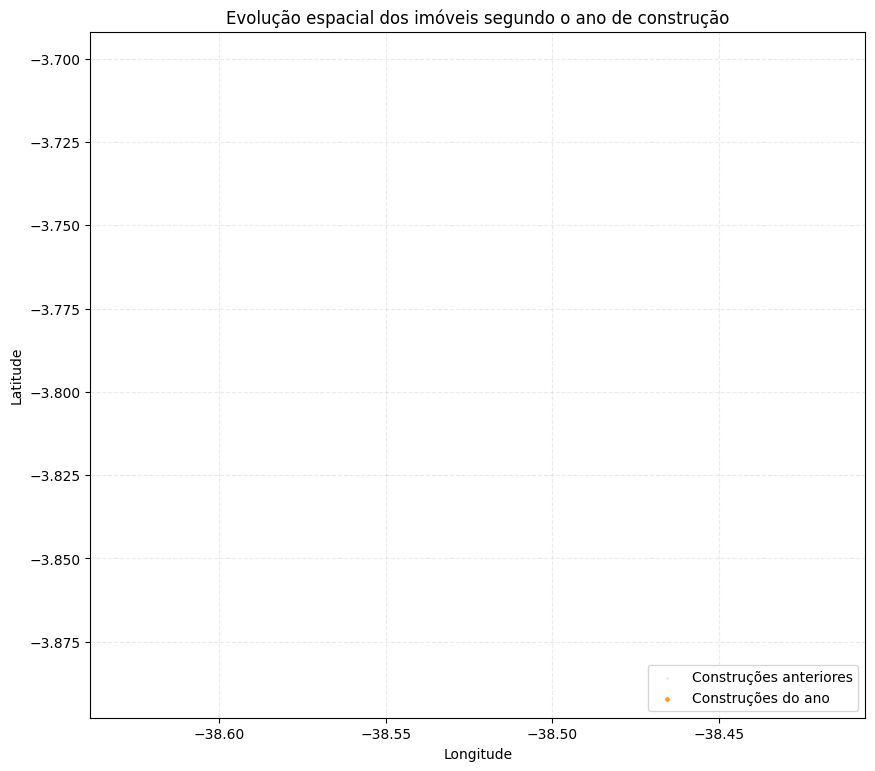

In [ ]:
# Criar a figura da animação
fig, ax = plt.subplots(
    figsize=(10, 9)
)

# Definir uma margem para os limites do mapa
margem_longitude = 0.005
margem_latitude = 0.005

# Fixar os limites geográficos durante toda a animação
ax.set_xlim(
    base_animacao['LONGITUDE'].min()
    - margem_longitude,

    base_animacao['LONGITUDE'].max()
    + margem_longitude
)

ax.set_ylim(
    base_animacao['LATITUDE'].min()
    - margem_latitude,

    base_animacao['LATITUDE'].max()
    + margem_latitude
)

# Criar a camada dos imóveis construídos anteriormente
pontos_anteriores = ax.scatter(
    [],
    [],
    s=4,
    alpha=0.15,
    color='steelblue',
    linewidths=0,
    label='Construções anteriores'
)

# Criar a camada dos imóveis construídos no ano apresentado
pontos_ano_atual = ax.scatter(
    [],
    [],
    s=12,
    alpha=0.85,
    color='darkorange',
    linewidths=0,
    label='Construções do ano'
)

# Criar a caixa com as informações de cada quadro
texto_informativo = ax.text(
    0.02,
    0.98,
    '',
    transform=ax.transAxes,
    verticalalignment='top',
    fontsize=11,
    bbox={
        'boxstyle': 'round',
        'facecolor': 'white',
        'edgecolor': 'gray',
        'alpha': 0.85
    }
)

# Configurar os elementos fixos do gráfico
ax.set_title(
    'Evolução espacial dos imóveis segundo o ano de construção'
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.grid(
    linestyle='--',
    alpha=0.25
)

ax.set_aspect(
    'equal',
    adjustable='box'
)

ax.legend(
    loc='lower right'
)

In [ ]:
# Função executada para cada ano da animação
def atualizar_animacao(ano):

    # Selecionar os imóveis construídos antes do ano atual
    anteriores = base_animacao[
        base_animacao['ANO_CONSTRUCAO'] < ano
    ]

    # Selecionar os imóveis construídos no ano atual
    atuais = base_animacao[
        base_animacao['ANO_CONSTRUCAO'] == ano
    ]

    # Selecionar todos os imóveis construídos até o ano atual
    acumulados = base_animacao[
        base_animacao['ANO_CONSTRUCAO'] <= ano
    ]

    # Atualizar os pontos dos anos anteriores
    pontos_anteriores.set_offsets(
        anteriores[
            ['LONGITUDE', 'LATITUDE']
        ].to_numpy()
    )

    # Atualizar os pontos do ano apresentado
    pontos_ano_atual.set_offsets(
        atuais[
            ['LONGITUDE', 'LATITUDE']
        ].to_numpy()
    )

    # Atualizar as informações exibidas
    texto_informativo.set_text(
        f'Ano: {ano}\n'
        f'Imóveis do ano: '
        f'{len(atuais):,}\n'
        f'Total acumulado: '
        f'{len(acumulados):,}'
        .replace(',', '.')
    )

    return (
        pontos_anteriores,
        pontos_ano_atual,
        texto_informativo
    )

In [ ]:
# Criar a animação
animacao = FuncAnimation(
    fig,
    atualizar_animacao,
    frames=anos_animacao,
    interval=500,
    repeat=False,
    blit=True
)

# Definir o local em que o vídeo será salvo temporariamente
caminho_video = (
    '/content/evolucao_espacial_imoveis.mp4'
)

# Salvar a animação no formato MP4
animacao.save(
    caminho_video,
    writer='ffmpeg',
    fps=3,
    dpi=130
)

# Fechar a figura estática
plt.close(fig)

# Exibir o vídeo no notebook
display(
    Video(
        caminho_video,
        embed=True
    )
)

## Criação de variáveis para a análise temporal

A variável `DATA_CADASTRAMENTO_GI_IMOVEL` contém a data e a hora completas do cadastramento de cada operação. Entretanto, para analisar a evolução dos registros ao longo do tempo, é necessário extrair componentes específicos dessa data.

Serão criadas as seguintes variáveis:

- `ANO_CADASTRAMENTO`: identifica o ano em que o registro foi cadastrado;
- `MES_CADASTRAMENTO_NUMERO`: representa numericamente o mês, com valores de 1 a 12;
- `MES_CADASTRAMENTO`: apresenta o nome do mês em português;
- `ANO_MES_CADASTRAMENTO`: representa o primeiro dia de cada mês e permite construir séries temporais mensais.

A variável numérica do mês será utilizada para ordenar corretamente os nomes dos meses no Power BI. A variável de ano-mês permitirá analisar tendências, crescimento, redução e possíveis padrões sazonais na quantidade de operações imobiliárias.

In [ ]:
# Dicionário para associar o número ao nome do mês
nomes_meses = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

# Criar o número do mês de cadastramento
dados_trabalho['MES_CADASTRAMENTO_NUMERO'] = (
    dados_trabalho[
        'DATA_CADASTRAMENTO_GI_IMOVEL'
    ].dt.month
)

# Criar o nome do mês de cadastramento
dados_trabalho['MES_CADASTRAMENTO'] = (
    dados_trabalho[
        'MES_CADASTRAMENTO_NUMERO'
    ].map(nomes_meses)
)

# Criar uma data representativa do início de cada mês
dados_trabalho['ANO_MES_CADASTRAMENTO'] = (
    dados_trabalho[
        'DATA_CADASTRAMENTO_GI_IMOVEL'
    ]
    .dt.to_period('M')
    .dt.to_timestamp()
)

# Conferir as variáveis temporais criadas
dados_trabalho[
    [
        'DATA_CADASTRAMENTO_GI_IMOVEL',
        'ANO_CADASTRAMENTO',
        'MES_CADASTRAMENTO_NUMERO',
        'MES_CADASTRAMENTO',
        'ANO_MES_CADASTRAMENTO'
    ]
].head()

,DATA_CADASTRAMENTO_GI_IMOVEL,ANO_CADASTRAMENTO,MES_CADASTRAMENTO_NUMERO,MES_CADASTRAMENTO,ANO_MES_CADASTRAMENTO
0,2026-02-03 07:12:00,2026,2,Fevereiro,2026-02-01
1,2026-02-03 05:52:00,2026,2,Fevereiro,2026-02-01
2,2026-02-02 23:26:00,2026,2,Fevereiro,2026-02-01
3,2026-02-02 18:28:00,2026,2,Fevereiro,2026-02-01
4,2026-02-02 18:03:00,2026,2,Fevereiro,2026-02-01


### Evolução mensal das operações imobiliárias

Após a criação das variáveis temporais, será analisada a quantidade de operações cadastradas em cada mês.

A análise mensal permite identificar períodos com maior ou menor movimentação, tendências ao longo dos anos e possíveis padrões sazonais.

Como cada registro da base corresponde a uma operação distinta, será utilizada a variável `NUM_DTI` para contabilizar as operações. Também será apresentada a quantidade de imóveis distintos envolvidos em cada mês.

In [ ]:
# Construir o resumo mensal das operações
resumo_mensal = (
    dados_trabalho
    .groupby('ANO_MES_CADASTRAMENTO')
    .agg(
        QUANTIDADE_OPERACOES=(
            'NUM_DTI',
            'nunique'
        ),

        QUANTIDADE_IMOVEIS=(
            'ID_IMOVEL',
            'nunique'
        )
    )
    .reset_index()
    .sort_values('ANO_MES_CADASTRAMENTO')
)

resumo_mensal

,ANO_MES_CADASTRAMENTO,QUANTIDADE_OPERACOES,QUANTIDADE_IMOVEIS
0,2022-01-01,1214,1178
1,2022-02-01,1455,1418
2,2022-03-01,2202,1912
3,2022-04-01,1498,1448
4,2022-05-01,1856,1819
5,2022-06-01,1920,1783
6,2022-07-01,1828,1710
7,2022-08-01,1890,1790
8,2022-09-01,1805,1749
9,2022-10-01,2010,1954


### Visualização da evolução mensal

O gráfico apresenta a evolução mensal da quantidade de operações e da quantidade de imóveis distintos envolvidos.

A distância entre as duas linhas indica a ocorrência de mais de uma operação associada ao mesmo imóvel durante determinado mês.

O ano de 2026 deve ser interpretado com cautela, pois representa um período ainda incompleto na base de dados.

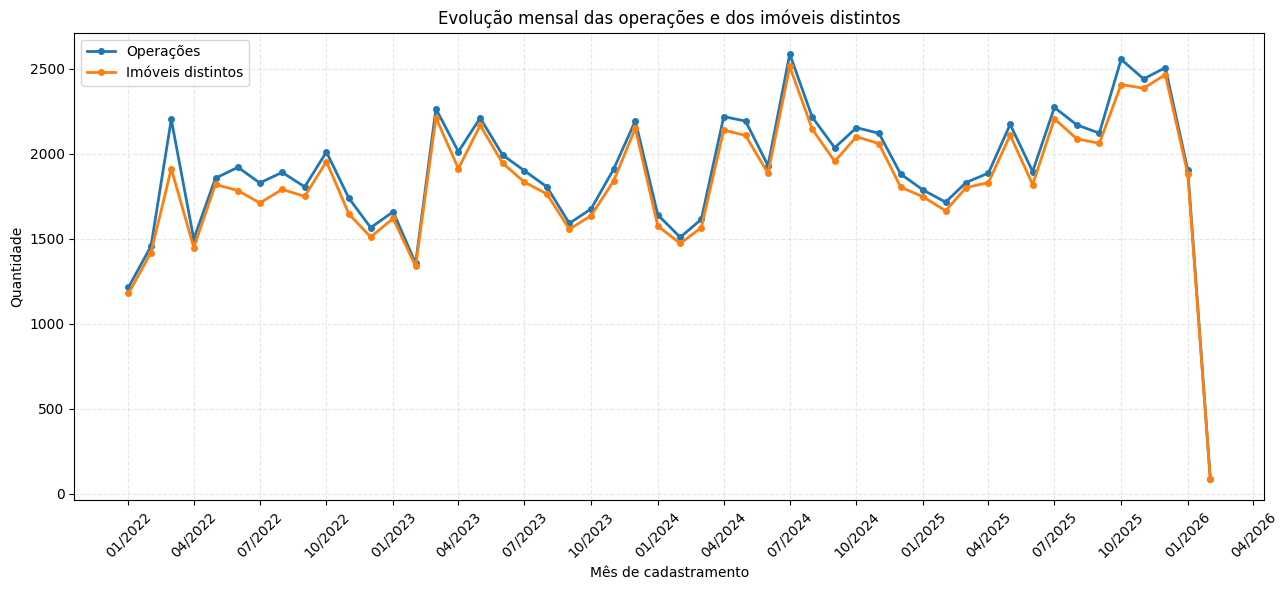

In [ ]:
# Importar o recurso para formatar as datas do gráfico
import matplotlib.dates as mdates

# Criar o gráfico da evolução mensal
plt.figure(figsize=(13, 6))

# Linha da quantidade de operações
plt.plot(
    resumo_mensal['ANO_MES_CADASTRAMENTO'],
    resumo_mensal['QUANTIDADE_OPERACOES'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Operações'
)

# Linha da quantidade de imóveis distintos
plt.plot(
    resumo_mensal['ANO_MES_CADASTRAMENTO'],
    resumo_mensal['QUANTIDADE_IMOVEIS'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Imóveis distintos'
)

# Exibir uma marcação a cada três meses
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

# Formatar as datas como mês/ano
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%m/%Y')
)

plt.title('Evolução mensal das operações e dos imóveis distintos')
plt.xlabel('Mês de cadastramento')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend()
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Resultado da evolução mensal

A quantidade mensal de operações apresenta oscilações ao longo de todo o período analisado, sem evidenciar uma trajetória contínua de crescimento ou redução.

As maiores movimentações são observadas em alguns meses de 2024 e 2025, quando a quantidade de operações ultrapassa aproximadamente 2.500 registros. Também podem ser identificados períodos de redução, com valores próximos de 1.500 operações mensais.

As linhas referentes às operações e aos imóveis distintos apresentam comportamentos semelhantes e permanecem próximas durante praticamente todo o período. Isso indica que a maioria dos imóveis está associada a apenas uma operação em cada mês. A diferença entre as linhas representa imóveis que participaram de mais de uma operação no mesmo período.

A forte redução observada no último ponto não deve ser interpretada como uma queda do mercado imobiliário. O mês de fevereiro de 2026 está incompleto na base, contendo registros somente dos primeiros dias do mês. Portanto, esse período não é diretamente comparável aos meses completos.

### Resumo anual das operações imobiliárias

A análise anual permite comparar a quantidade de operações e de imóveis distintos entre os exercícios disponíveis.

Também será apresentada a quantidade de meses com registros em cada ano. Essa informação é importante porque os anos de 2022 a 2025 estão completos, enquanto 2026 possui somente os primeiros meses na base.

Por esse motivo, os totais de 2026 não devem ser comparados diretamente com os totais dos anos completos.

In [ ]:
# Construir o resumo anual
resumo_anual = (
    dados_trabalho
    .groupby('ANO_CADASTRAMENTO')
    .agg(
        QUANTIDADE_OPERACOES=(
            'NUM_DTI',
            'nunique'
        ),

        QUANTIDADE_IMOVEIS=(
            'ID_IMOVEL',
            'nunique'
        ),

        MESES_COM_REGISTROS=(
            'MES_CADASTRAMENTO_NUMERO',
            'nunique'
        )
    )
    .reset_index()
    .sort_values('ANO_CADASTRAMENTO')
)

# Calcular a diferença entre operações e imóveis
resumo_anual['DIFERENCA_OPERACOES_IMOVEIS'] = (
    resumo_anual['QUANTIDADE_OPERACOES']
    - resumo_anual['QUANTIDADE_IMOVEIS']
)

resumo_anual

,ANO_CADASTRAMENTO,QUANTIDADE_OPERACOES,QUANTIDADE_IMOVEIS,MESES_COM_REGISTROS,DIFERENCA_OPERACOES_IMOVEIS
0,2022,20981,19075,12,1906
1,2023,22562,21108,12,1454
2,2024,24091,22216,12,1875
3,2025,25347,23450,12,1897
4,2026,1989,1965,2,24


### Resultado do resumo anual

Entre os anos completos de 2022 e 2025, observa-se crescimento contínuo na quantidade de operações cadastradas. O total passou de 20.981 operações, em 2022, para 25.347, em 2025.

As taxas de crescimento anual foram de aproximadamente 7,53% em 2023, 6,78% em 2024 e 5,21% em 2025. Portanto, embora a quantidade de operações tenha aumentado durante todo o período, o ritmo desse crescimento apresentou redução gradual.

Em todos os anos, a quantidade de operações foi superior à quantidade de imóveis distintos, confirmando que alguns imóveis participaram de mais de uma operação no mesmo ano.

O ano de 2026 possui registros em apenas dois meses, sendo fevereiro ainda incompleto. Por isso, seu total não deve ser comparado diretamente com os anos anteriores.

## Avaliação das variáveis monetárias

As variáveis monetárias permitem analisar os valores associados aos imóveis e às operações registradas na base.

Serão avaliadas as seguintes variáveis:

- `VL_BASE_CALCULO`: valor utilizado como base de cálculo;
- `VL_VENAL`: valor venal cadastrado para o imóvel;
- `VL_LANCAMENTO_IPTU`: valor relacionado ao lançamento do IPTU.

Antes da realização das análises, será verificada a qualidade dessas informações. Serão observados os valores ausentes, iguais a zero, negativos, mínimos, medianos, médias e máximos.

Essa avaliação é necessária porque valores ausentes, nulos ou muito elevados podem influenciar medidas como média, desvio-padrão e escala dos gráficos.

In [ ]:
# Selecionar as variáveis monetárias
variaveis_monetarias = [
    'VL_BASE_CALCULO',
    'VL_VENAL',
    'VL_LANCAMENTO_IPTU'
]

# Construir a tabela de avaliação
avaliacao_monetaria = pd.DataFrame({
    'VALORES_PREENCHIDOS': (
        dados_trabalho[variaveis_monetarias]
        .count()
    ),

    'VALORES_AUSENTES': (
        dados_trabalho[variaveis_monetarias]
        .isna()
        .sum()
    ),

    'PERCENTUAL_AUSENTE': (
        dados_trabalho[variaveis_monetarias]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    'VALORES_ZERO': (
        dados_trabalho[variaveis_monetarias]
        .eq(0)
        .sum()
    ),

    'VALORES_NEGATIVOS': (
        dados_trabalho[variaveis_monetarias]
        .lt(0)
        .sum()
    ),

    'MINIMO': (
        dados_trabalho[variaveis_monetarias]
        .min()
        .round(2)
    ),

    'MEDIANA': (
        dados_trabalho[variaveis_monetarias]
        .median()
        .round(2)
    ),

    'MEDIA': (
        dados_trabalho[variaveis_monetarias]
        .mean()
        .round(2)
    ),

    'MAXIMO': (
        dados_trabalho[variaveis_monetarias]
        .max()
        .round(2)
    )
})

avaliacao_monetaria

,VALORES_PREENCHIDOS,VALORES_AUSENTES,PERCENTUAL_AUSENTE,VALORES_ZERO,VALORES_NEGATIVOS,MINIMO,MEDIANA,MEDIA,MAXIMO
VL_BASE_CALCULO,88080,6890,7.25,208,0,0.0,275610.00,490024.15,3.049414e+08
VL_VENAL,94970,0,0.00,654,0,0.0,79427.97,177219.30,1.535799e+08
VL_LANCAMENTO_IPTU,89348,5622,5.92,13799,0,0.0,618.10,2008.31,1.515781e+06


### Resultado preliminar da avaliação monetária

Não foram identificados valores negativos nas três variáveis monetárias.

A variável `VL_BASE_CALCULO` possui 6.890 valores ausentes, correspondentes a 7,25% da base, além de 208 registros iguais a zero.

A variável `VL_VENAL` está preenchida em todos os registros, mas apresenta 654 valores iguais a zero.

A variável `VL_LANCAMENTO_IPTU` possui 5.622 valores ausentes e 13.799 valores iguais a zero. A quantidade elevada de zeros nessa variável requer uma análise específica, pois pode representar ausência de lançamento, alguma condição tributária particular ou outra situação administrativa que não está explicitamente descrita na base.

As médias são consideravelmente superiores às medianas, indicando distribuições assimétricas à direita e a presença de valores monetários muito elevados. Antes de realizar substituições ou excluir observações, será analisada a correspondência entre os valores ausentes, iguais a zero e positivos.

In [ ]:
# Criar uma tabela auxiliar para classificar os valores monetários
situacao_monetaria = pd.DataFrame(
    index=dados_trabalho.index
)

# Classificar cada valor como ausente, zero ou positivo
for coluna in variaveis_monetarias:

    situacao_monetaria[coluna] = np.select(
        [
            dados_trabalho[coluna].isna(),
            dados_trabalho[coluna].eq(0)
        ],
        [
            'Ausente',
            'Zero'
        ],
        default='Positivo'
    )

# Contar as combinações encontradas
combinacoes_monetarias = (
    situacao_monetaria
    .value_counts()
    .reset_index(name='QUANTIDADE')
)

# Calcular o percentual de cada combinação
combinacoes_monetarias['PERCENTUAL'] = (
    combinacoes_monetarias['QUANTIDADE']
    .div(len(dados_trabalho))
    .mul(100)
    .round(2)
)

combinacoes_monetarias

,VL_BASE_CALCULO,VL_VENAL,VL_LANCAMENTO_IPTU,QUANTIDADE,PERCENTUAL
0,Positivo,Positivo,Positivo,69262,72.93
1,Positivo,Positivo,Zero,12993,13.68
2,Ausente,Positivo,Positivo,5944,6.26
3,Positivo,Positivo,Ausente,5002,5.27
4,Ausente,Positivo,Zero,773,0.81
5,Positivo,Zero,Ausente,450,0.47
6,Zero,Positivo,Positivo,184,0.19
7,Positivo,Zero,Positivo,155,0.16
8,Ausente,Positivo,Ausente,134,0.14
9,Ausente,Zero,Ausente,35,0.04


### Resultado da correspondência entre as variáveis monetárias

Em 72,93% dos registros, as três variáveis monetárias apresentam valores positivos.

A combinação mais frequente entre os casos especiais corresponde aos registros com base de cálculo e valor venal positivos, mas lançamento de IPTU igual a zero, representando 13,68% da base.

Esse resultado indica que o valor zero de `VL_LANCAMENTO_IPTU` não representa necessariamente ausência geral de informações monetárias, pois os mesmos registros geralmente possuem base de cálculo e valor venal preenchidos.

Também foram observados registros com base de cálculo ou lançamento de IPTU ausentes, mesmo quando as demais variáveis apresentam valores positivos.

Como a documentação disponível não permite determinar o significado administrativo de cada ocorrência, os valores iguais a zero e os valores ausentes serão preservados. Nas análises, será mantida a distinção entre valor positivo, valor zero e informação ausente.

In [ ]:
# Calcular os quantis das variáveis monetárias
quantis_monetarios = (
    dados_trabalho[
        variaveis_monetarias
    ]
    .quantile(
        [
            0.00,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            1.00
        ]
    )
    .round(2)
)

# Identificar os quantis apresentados
quantis_monetarios.index = [
    'Mínimo',
    '25%',
    'Mediana',
    '75%',
    '90%',
    '95%',
    '99%',
    'Máximo'
]


# Função para formatar valores monetários
# utilizando o padrão brasileiro
def formatar_moeda_brasileira(valor):

    # Verificar se o valor está ausente
    if pd.isna(valor):
        return 'Não informado'

    # Formatar inicialmente com separadores
    valor_formatado = f'R$ {valor:,.2f}'

    # Trocar os separadores para o padrão brasileiro
    return (
        valor_formatado
        .replace(',', 'X')
        .replace('.', ',')
        .replace('X', '.')
    )


# Apresentar a tabela no padrão monetário brasileiro
quantis_monetarios.style.format(
    formatar_moeda_brasileira
)

,VL_BASE_CALCULO,VL_VENAL,VL_LANCAMENTO_IPTU
Mínimo,"R$ 0,00","R$ 0,00","R$ 0,00"
25%,"R$ 176.177,51","R$ 31.369,74","R$ 109,36"
Mediana,"R$ 275.610,00","R$ 79.427,97","R$ 618,10"
75%,"R$ 476.712,88","R$ 171.732,58","R$ 1.360,45"
90%,"R$ 829.532,00","R$ 323.302,23","R$ 2.733,48"
95%,"R$ 1.300.000,00","R$ 532.786,79","R$ 5.757,22"
99%,"R$ 3.600.000,00","R$ 1.662.538,24","R$ 29.174,94"
Máximo,"R$ 304.941.450,00","R$ 153.579.877,30","R$ 1.515.781,46"


### Resultado da análise dos quantis monetários

A análise dos quantis confirma que as três variáveis monetárias apresentam distribuições fortemente assimétricas à direita.

Na variável `VL_BASE_CALCULO`, 99% dos valores são iguais ou inferiores a R$ 3,6 milhões, enquanto o valor máximo ultrapassa R$ 304 milhões.

Em `VL_VENAL`, 99% dos registros apresentam valores de até aproximadamente R$ 1,66 milhão, mas o máximo supera R$ 153 milhões.

No caso de `VL_LANCAMENTO_IPTU`, 99% dos valores são iguais ou inferiores a aproximadamente R$ 29 mil, enquanto o máximo ultrapassa R$ 1,5 milhão.

Essas diferenças indicam a presença de valores extremos. Entretanto, esses registros não serão excluídos automaticamente, pois podem corresponder a imóveis de grande porte, empreendimentos comerciais, terrenos extensos ou outras propriedades de elevado valor. Antes de qualquer decisão, os maiores registros serão examinados individualmente.

In [ ]:
# Apresentar os dez maiores registros de cada variável monetária
for variavel in variaveis_monetarias:

    print(f'\nDez maiores valores de {variavel}:')

    display(
        dados_trabalho
        .nlargest(10, variavel)
        [
            [
                'ID_IMOVEL',
                'NUM_DTI',
                'BAIRRO',
                'TIPO_USO_IMOVEL',
                'AREA_TERRENO',
                'AREA_EDIFICADA',
                variavel
            ]
        ]
        .style
        .format({
            variavel: formatar_moeda_brasileira,
            'AREA_TERRENO': '{:,.2f}',
            'AREA_EDIFICADA': '{:,.2f}'
        })
    )


Dez maiores valores de VL_BASE_CALCULO:


,ID_IMOVEL,NUM_DTI,BAIRRO,TIPO_USO_IMOVEL,AREA_TERRENO,AREA_EDIFICADA,VL_BASE_CALCULO
39232,2374414,14505/2024,PREFEITO JOSÉ WALTER,Sem,"1,525,707.25",nan,"R$ 304.941.450,00"
29947,1940253,25504/2024,EDSON QUEIROZ,Comercial,"24,414.29","28,440.17","R$ 133.000.000,50"
21226,1662952,7247/2025,MEIRELES,Sem,"3,274.79",nan,"R$ 75.000.000,00"
49509,1475579,2256/2024,FARIAS BRITO,Comercial,"40,081.60","30,528.69","R$ 73.347.410,00"
87402,1678813,9740/2022,PADRE ANDRADE,Comercial,"34,539.26","10,543.28","R$ 64.026.882,10"
25694,1763118,1920/2025,MUCURIPE,Sem,"14,061.00",nan,"R$ 61.841.400,00"
11214,2389148,19106/2025,ALDEOTA,Sem,"3,920.40",0.00,"R$ 59.106.157,60"
3073,1670528,27427/2025,MANUEL DIAS BRANCO,Comercial,"22,000.00","13,048.00","R$ 58.879.214,65"
52330,1829048,26319/2023,MEIRELES,Comercial,"1,884.00","10,223.68","R$ 56.000.000,00"
1268,1331289,792/2026,VILA UNIÃO,Sem,"48,290.00",nan,"R$ 55.534.310,07"



Dez maiores valores de VL_VENAL:


,ID_IMOVEL,NUM_DTI,BAIRRO,TIPO_USO_IMOVEL,AREA_TERRENO,AREA_EDIFICADA,VL_VENAL
39232,2374414,14505/2024,PREFEITO JOSÉ WALTER,Sem,"1,525,707.25",nan,"R$ 153.579.877,30"
49509,1475579,2256/2024,FARIAS BRITO,Comercial,"40,081.60","30,528.69","R$ 75.976.629,92"
29947,1940253,25504/2024,EDSON QUEIROZ,Comercial,"24,414.29","28,440.17","R$ 55.059.709,80"
25694,1763118,1920/2025,MUCURIPE,Sem,"14,061.00",nan,"R$ 51.020.415,84"
5135,1856495,26222/2025,MARAPONGA,Comercial,"64,759.96","28,594.56","R$ 38.195.691,75"
6940,1916067,21637/2025,MEIRELES,Comercial,"1,332.50","11,568.81","R$ 35.755.919,40"
52330,1829048,26319/2023,MEIRELES,Comercial,"1,884.00","10,223.68","R$ 35.711.276,95"
51115,1916067,26266/2023,MEIRELES,Comercial,"1,332.50","11,003.30","R$ 31.899.336,50"
21226,1662952,7247/2025,MEIRELES,Sem,"3,274.79",nan,"R$ 31.511.904,15"
87402,1678813,9740/2022,PADRE ANDRADE,Comercial,"34,539.26","10,543.28","R$ 29.839.321,20"



Dez maiores valores de VL_LANCAMENTO_IPTU:


,ID_IMOVEL,NUM_DTI,BAIRRO,TIPO_USO_IMOVEL,AREA_TERRENO,AREA_EDIFICADA,VL_LANCAMENTO_IPTU
49509,1475579,2256/2024,FARIAS BRITO,Comercial,"40,081.60","30,528.69","R$ 1.515.781,46"
29947,1940253,25504/2024,EDSON QUEIROZ,Comercial,"24,414.29","28,440.17","R$ 1.097.443,06"
25694,1763118,1920/2025,MUCURIPE,Sem,"14,061.00",nan,"R$ 877.060,13"
52330,1829048,26319/2023,MEIRELES,Comercial,"1,884.00","10,223.68","R$ 744.184,17"
6940,1916067,21637/2025,MEIRELES,Comercial,"1,332.50","11,568.81","R$ 664.346,95"
51115,1916067,26266/2023,MEIRELES,Comercial,"1,332.50","11,003.30","R$ 664.346,95"
87402,1678813,9740/2022,PADRE ANDRADE,Comercial,"34,539.26","10,543.28","R$ 614.120,20"
5232,2083928,26105/2025,EDSON QUEIROZ,Comercial,"190,785.78","12,666.59","R$ 575.208,12"
2797,2051543,25446/2025,PAPICU,Comercial,"114,030.48","15,182.46","R$ 550.008,37"
21226,1662952,7247/2025,MEIRELES,Sem,"3,274.79",nan,"R$ 541.700,04"


### Distribuição espacial dos valores monetários

Para investigar a distribuição territorial dos valores imobiliários, serão construídos três mapas de dispersão:

- distribuição espacial da base de cálculo;
- distribuição espacial do valor venal;
- distribuição espacial do lançamento de IPTU.

Cada ponto representa um imóvel distinto, identificado por sua latitude e longitude. A cor indica a magnitude do valor monetário: cores mais claras representam valores mais elevados.

Como as variáveis apresentam forte assimetria e valores extremos, será utilizada uma escala logarítmica. Além disso, a escala de cores será limitada ao percentil de 99%, evitando que poucos registros excepcionalmente altos prejudiquem a visualização dos demais imóveis.

Os valores acima do percentil de 99% continuarão presentes no gráfico, mas receberão a mesma cor máxima. Os valores ausentes ou iguais a zero não serão utilizados na camada colorida.

Esses mapas permitem identificar concentrações espaciais de imóveis com valores elevados. Entretanto, para determinar quais bairros possuem valores tipicamente mais altos, posteriormente serão calculadas medidas agregadas por bairro, especialmente a mediana.

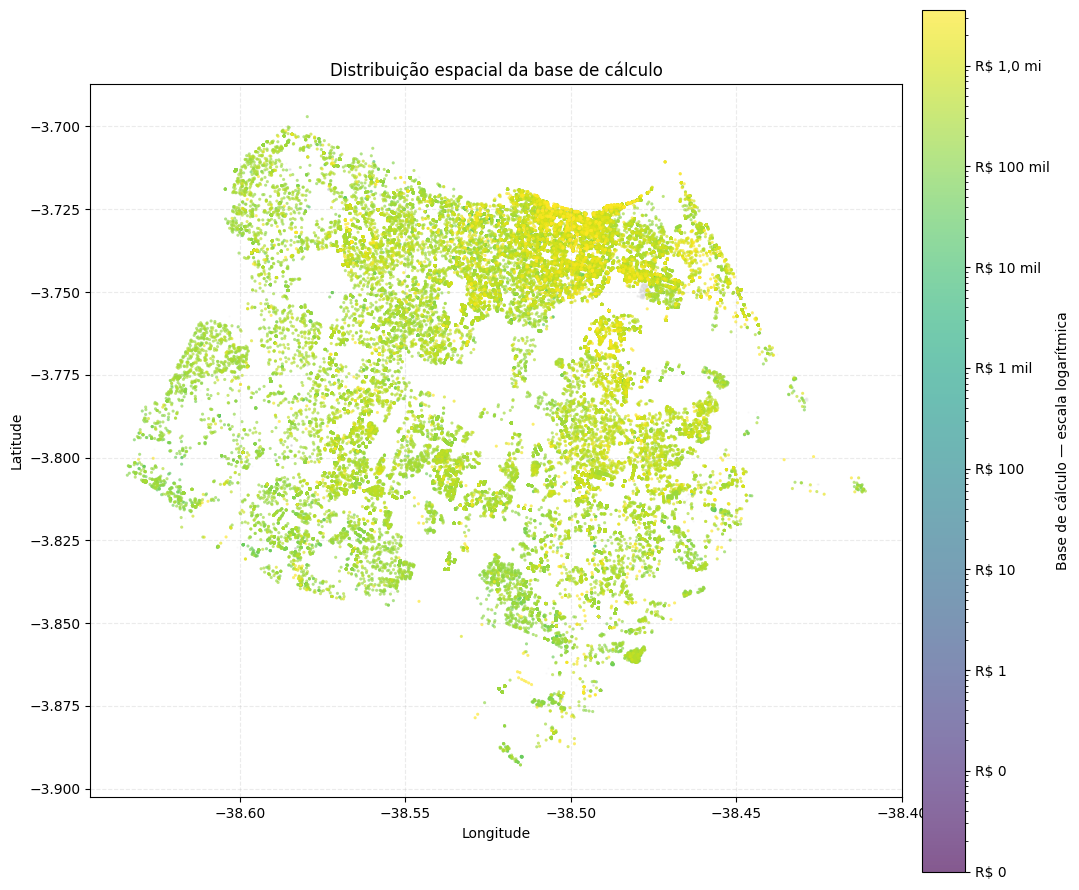

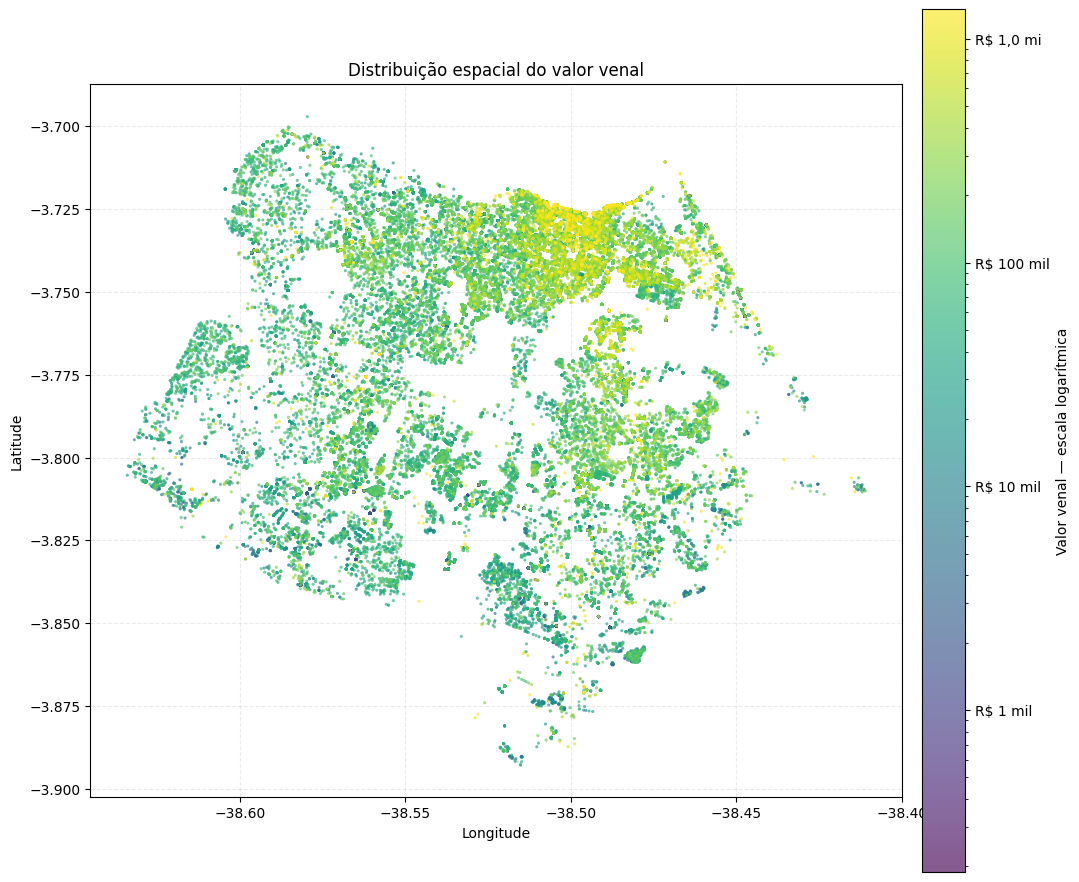

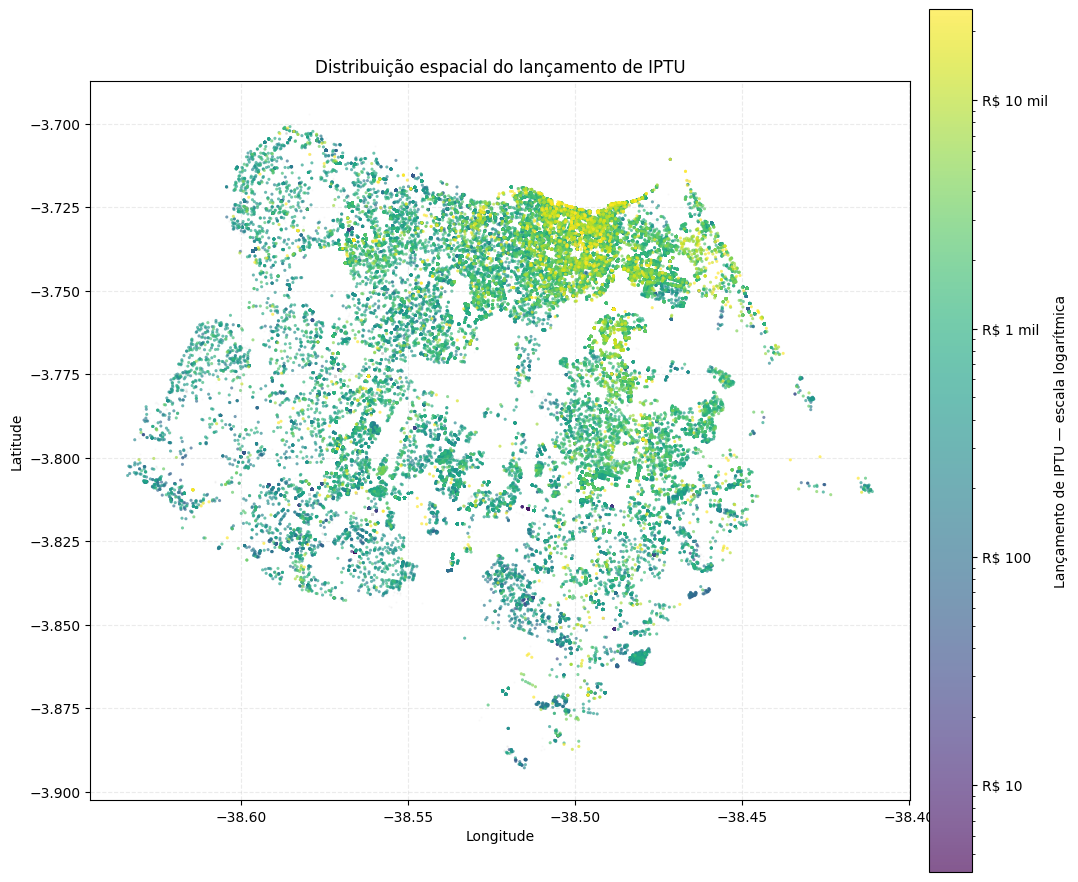

In [ ]:
# Importar os recursos para controlar a escala de cores
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter


# Criar uma base auxiliar sem imóveis repetidos
base_mapa_valores = (
    dados_trabalho
    .sort_values('DATA_CADASTRAMENTO_GI_IMOVEL')
    .drop_duplicates(
        subset='ID_IMOVEL',
        keep='last'
    )
    .copy()
)


# Informações utilizadas nos três mapas
configuracao_mapas = {
    'VL_BASE_CALCULO': {
        'titulo': 'Distribuição espacial da base de cálculo',
        'legenda': 'Base de cálculo'
    },

    'VL_VENAL': {
        'titulo': 'Distribuição espacial do valor venal',
        'legenda': 'Valor venal'
    },

    'VL_LANCAMENTO_IPTU': {
        'titulo': 'Distribuição espacial do lançamento de IPTU',
        'legenda': 'Lançamento de IPTU'
    }
}


# Função para formatar a escala monetária da legenda
def formatar_escala_monetaria(valor, posicao=None):

    if valor >= 1_000_000:
        return (
            f'R$ {valor / 1_000_000:.1f} mi'
            .replace('.', ',')
        )

    if valor >= 1_000:
        return (
            f'R$ {valor / 1_000:.0f} mil'
            .replace('.', ',')
        )

    return (
        f'R$ {valor:.0f}'
        .replace('.', ',')
    )


# Criar um mapa para cada variável monetária
for variavel, configuracao in configuracao_mapas.items():

    # Selecionar somente valores positivos e coordenadas preenchidas
    base_valida = base_mapa_valores.loc[
        base_mapa_valores[variavel].gt(0)
        & base_mapa_valores['LATITUDE'].notna()
        & base_mapa_valores['LONGITUDE'].notna(),
        [
            'LONGITUDE',
            'LATITUDE',
            variavel
        ]
    ].copy()

    # Calcular o limite do percentil de 99%
    limite_superior = (
        base_valida[variavel]
        .quantile(0.99)
    )

    # Limitar apenas a escala de cores
    # Os registros não são excluídos do gráfico
    base_valida['VALOR_COR'] = (
        base_valida[variavel]
        .clip(upper=limite_superior)
    )

    # Ordenar para desenhar os maiores valores por cima
    base_valida = base_valida.sort_values(
        'VALOR_COR'
    )

    # Criar a figura
    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    # Apresentar todos os imóveis como referência espacial
    ax.scatter(
        base_mapa_valores['LONGITUDE'],
        base_mapa_valores['LATITUDE'],
        s=2,
        color='lightgray',
        alpha=0.15,
        linewidths=0
    )

    # Apresentar os imóveis coloridos pelos valores
    pontos = ax.scatter(
        base_valida['LONGITUDE'],
        base_valida['LATITUDE'],
        c=base_valida['VALOR_COR'],
        cmap='viridis',
        norm=LogNorm(
            vmin=base_valida['VALOR_COR'].min(),
            vmax=limite_superior
        ),
        s=5,
        alpha=0.65,
        linewidths=0
    )

    # Criar a barra de cores
    barra_cores = fig.colorbar(
        pontos,
        ax=ax,
        pad=0.02
    )

    barra_cores.set_label(
        configuracao['legenda']
        + ' — escala logarítmica'
    )

    barra_cores.ax.yaxis.set_major_formatter(
        FuncFormatter(
            formatar_escala_monetaria
        )
    )

    # Configurar o gráfico
    ax.set_title(
        configuracao['titulo']
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.grid(
        linestyle='--',
        alpha=0.25
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    plt.tight_layout()
    plt.show()

### Concentração espacial dos maiores valores monetários

Os mapas com escala contínua apresentaram dificuldade de interpretação devido à grande quantidade de pontos, à sobreposição espacial e à forte assimetria das variáveis monetárias.

Para tornar a identificação das áreas de maior valor mais clara, os imóveis serão classificados segundo sua posição na distribuição de cada variável:

- imóveis abaixo do percentil de 90% serão apresentados em cinza;
- imóveis entre os percentis de 90% e 99% serão destacados em laranja;
- imóveis pertencentes ao 1% de maiores valores serão destacados em vermelho.

Essa abordagem permite visualizar diretamente onde estão concentrados os imóveis de valores mais elevados, sem excluir nenhuma observação da base.

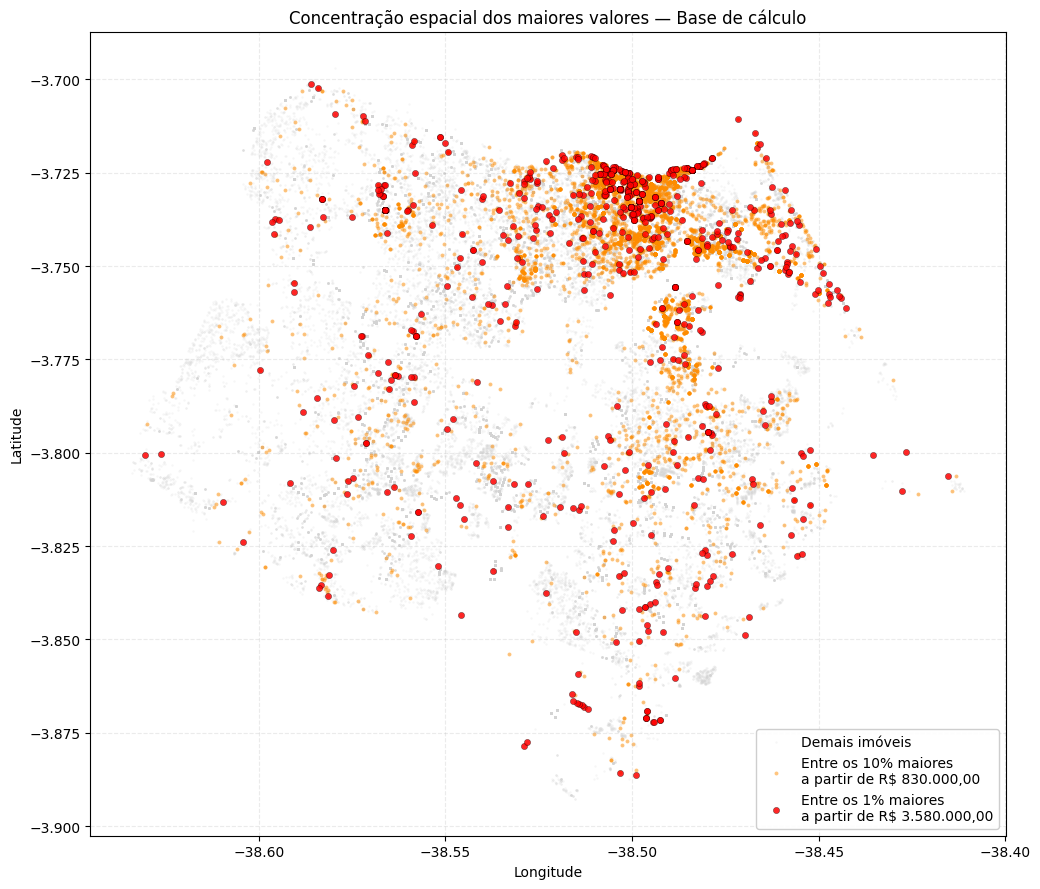

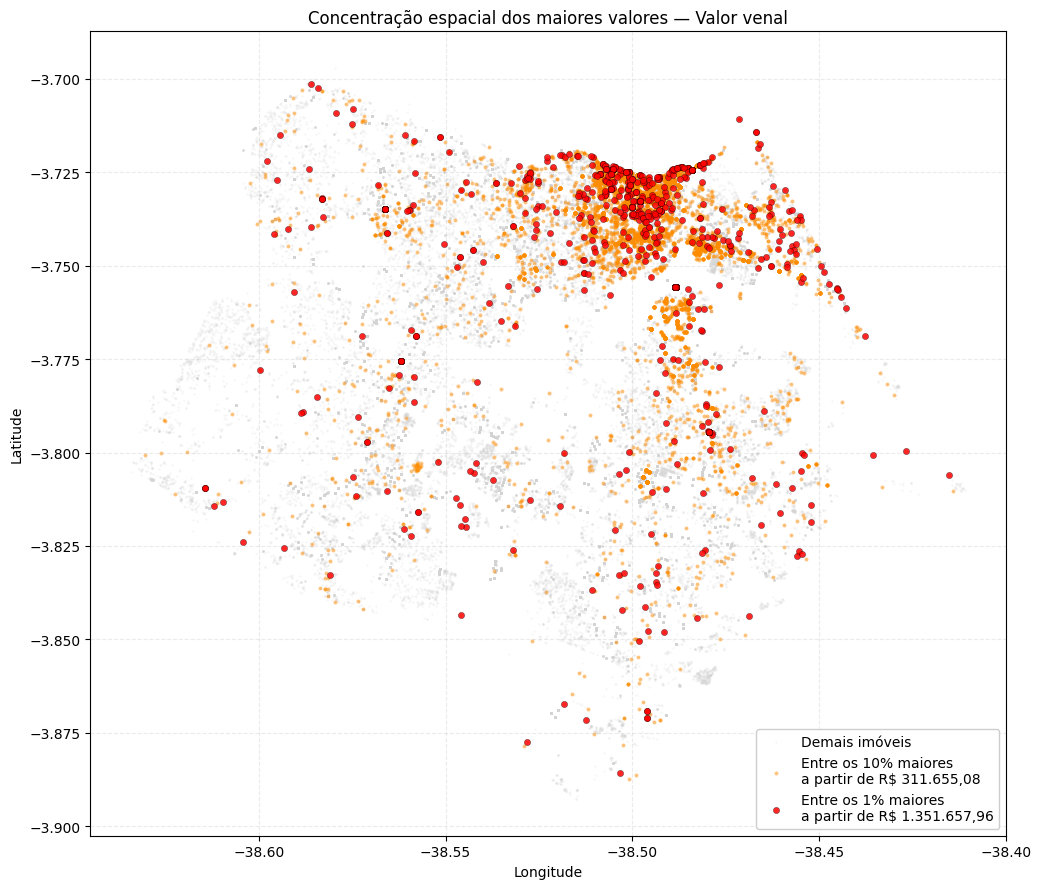

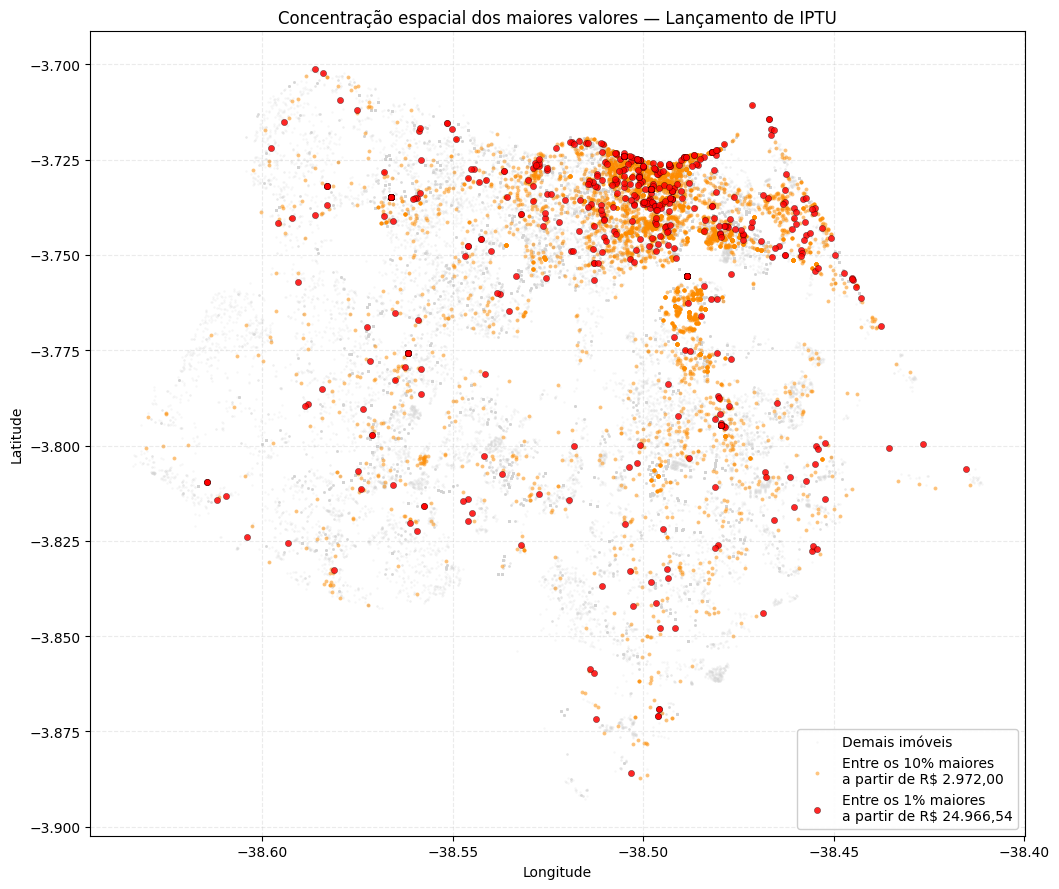

In [ ]:
# Criar mapas destacando os imóveis de maiores valores
for variavel, configuracao in configuracao_mapas.items():

    # Selecionar imóveis com valor positivo e coordenadas válidas
    base_valida = base_mapa_valores.loc[
        base_mapa_valores[variavel].gt(0)
        & base_mapa_valores['LATITUDE'].notna()
        & base_mapa_valores['LONGITUDE'].notna()
    ].copy()

    # Calcular os limites dos 10% e 1% maiores valores
    percentil_90 = base_valida[variavel].quantile(0.90)
    percentil_99 = base_valida[variavel].quantile(0.99)

    # Selecionar os imóveis entre os percentis 90% e 99%
    maiores_10_porcento = base_valida[
        base_valida[variavel].between(
            percentil_90,
            percentil_99,
            inclusive='left'
        )
    ]

    # Selecionar o 1% de imóveis com maiores valores
    maiores_1_porcento = base_valida[
        base_valida[variavel] >= percentil_99
    ]

    # Criar a figura
    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    # Apresentar todos os imóveis como referência
    ax.scatter(
        base_valida['LONGITUDE'],
        base_valida['LATITUDE'],
        s=3,
        color='lightgray',
        alpha=0.20,
        linewidths=0,
        label='Demais imóveis'
    )

    # Destacar os imóveis entre os percentis 90% e 99%
    ax.scatter(
        maiores_10_porcento['LONGITUDE'],
        maiores_10_porcento['LATITUDE'],
        s=8,
        color='darkorange',
        alpha=0.50,
        linewidths=0,
        label=(
            'Entre os 10% maiores\n'
            f'a partir de '
            f'{formatar_moeda_brasileira(percentil_90)}'
        )
    )

    # Destacar o 1% de imóveis com maiores valores
    ax.scatter(
        maiores_1_porcento['LONGITUDE'],
        maiores_1_porcento['LATITUDE'],
        s=20,
        color='red',
        alpha=0.85,
        edgecolor='black',
        linewidth=0.25,
        label=(
            'Entre os 1% maiores\n'
            f'a partir de '
            f'{formatar_moeda_brasileira(percentil_99)}'
        ),
        zorder=3
    )

    # Configurar o gráfico
    ax.set_title(
        'Concentração espacial dos maiores valores — '
        + configuracao['legenda']
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.grid(
        linestyle='--',
        alpha=0.25
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    ax.legend(
        loc='lower right',
        framealpha=0.95
    )

    plt.tight_layout()
    plt.show()

### Distribuição espacial dos valores por faixas de percentis

Os mapas anteriores utilizaram uma escala contínua de cores para representar os valores monetários. Entretanto, devido à forte assimetria das variáveis e à presença de valores extremos, principalmente na base de cálculo, grande parte dos imóveis apresentou cores muito semelhantes, dificultando a identificação dos diferentes níveis de valor.

Para melhorar a visualização, os imóveis serão classificados em seis faixas definidas por percentis:

- **até o percentil 25:** corresponde ao grupo de menores valores;
- **do percentil 25 até a mediana:** representa os valores situados entre P25 e P50;
- **da mediana até o percentil 75:** representa os valores situados entre P50 e P75;
- **do percentil 75 até o percentil 90:** identifica valores relativamente elevados;
- **do percentil 90 até o percentil 99:** representa os imóveis pertencentes ao grupo dos 10% maiores, excetuando-se o 1% superior;
- **a partir do percentil 99:** corresponde ao grupo de 1% dos maiores valores.

Será construído um mapa para cada variável monetária:

1. `VL_BASE_CALCULO`;
2. `VL_VENAL`;
3. `VL_LANCAMENTO_IPTU`.

Cada ponto representará um imóvel distinto. As cores serão organizadas dos menores para os maiores valores, terminando em vermelho para destacar o grupo superior.

Os registros com valores ausentes não serão incluídos no respectivo mapa. Os valores iguais a zero serão mantidos e classificados na primeira faixa, pois foi decidido preservá-los como valores diferentes de uma informação ausente.

Os percentis serão calculados separadamente para cada variável. Portanto, uma mesma cor indica uma posição semelhante dentro da distribuição, mas não necessariamente o mesmo valor monetário nos três mapas.

A quantidade de imóveis em cada faixa pode não corresponder exatamente ao percentual teórico quando muitos registros apresentam valores iguais nos limites dos percentis.

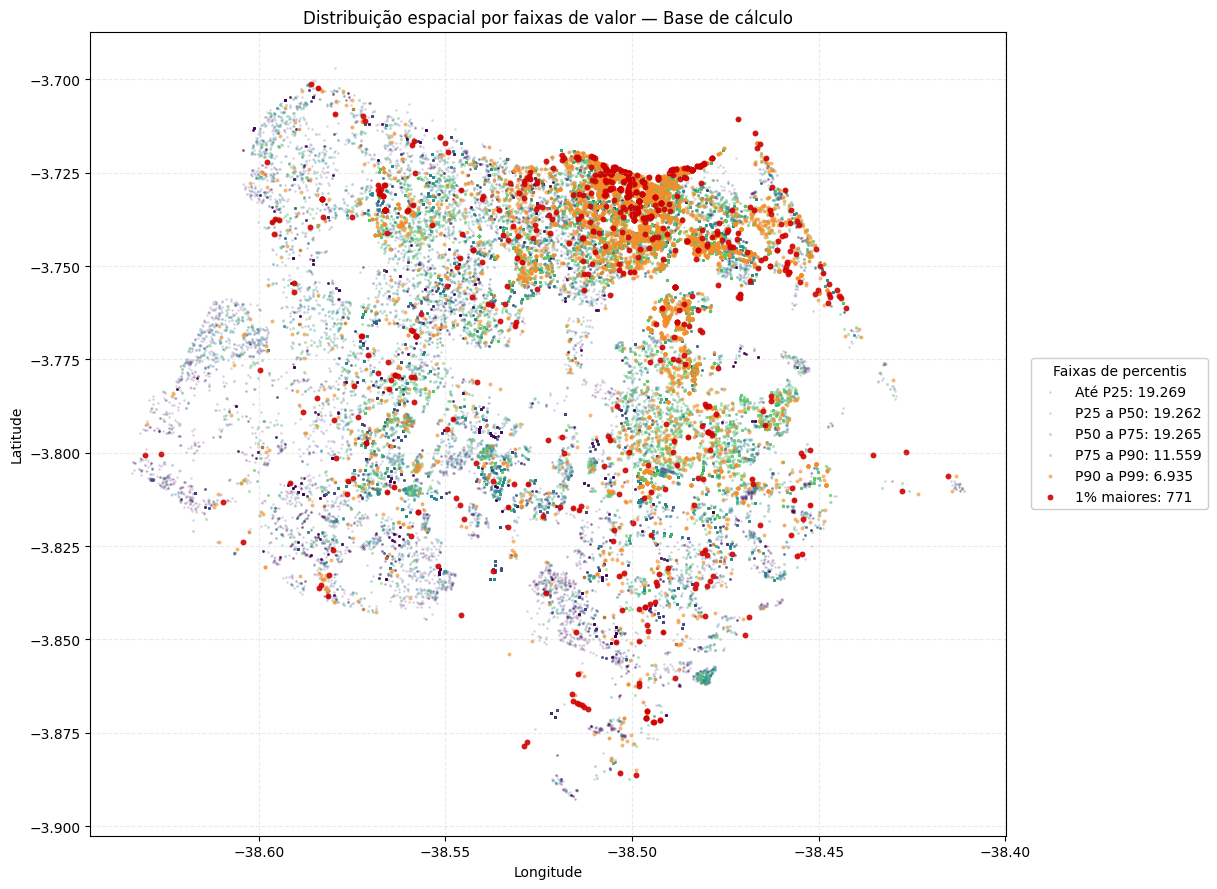

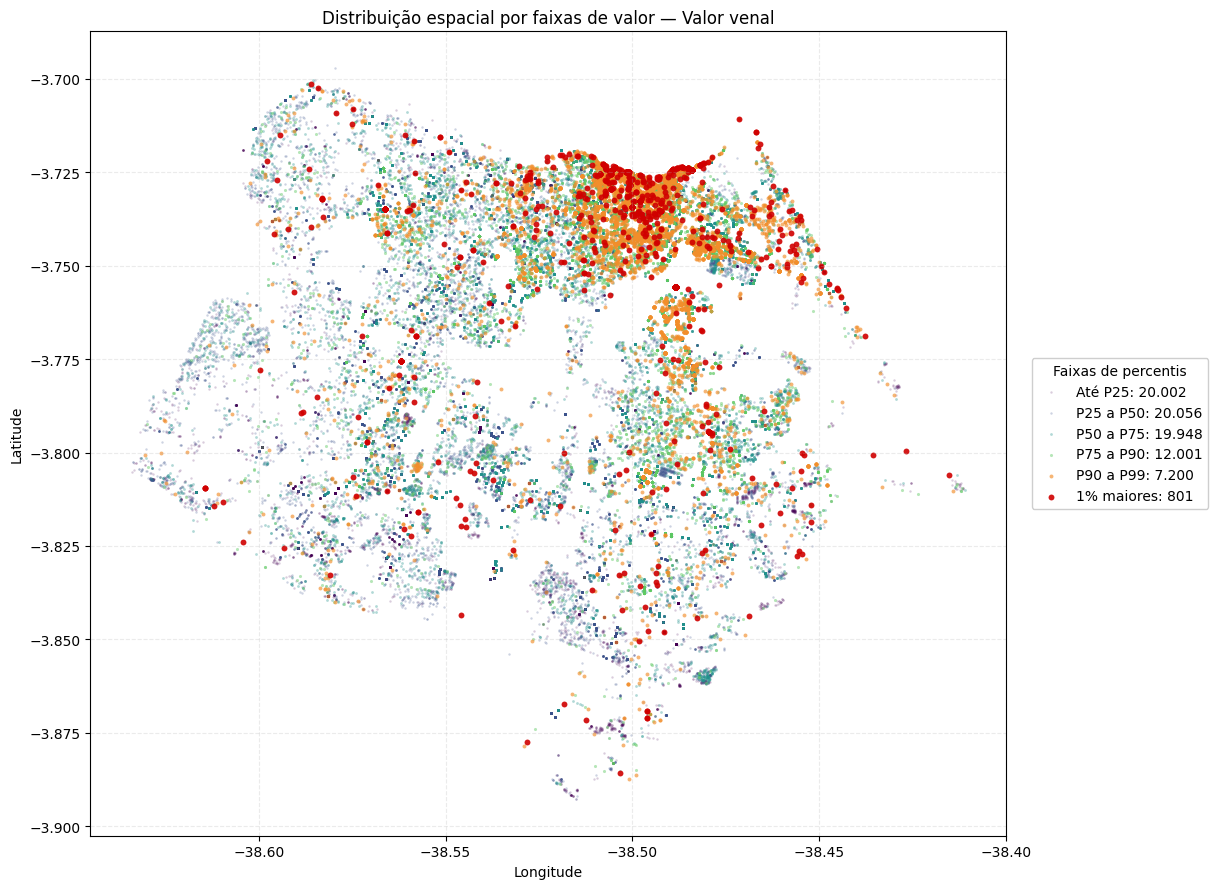

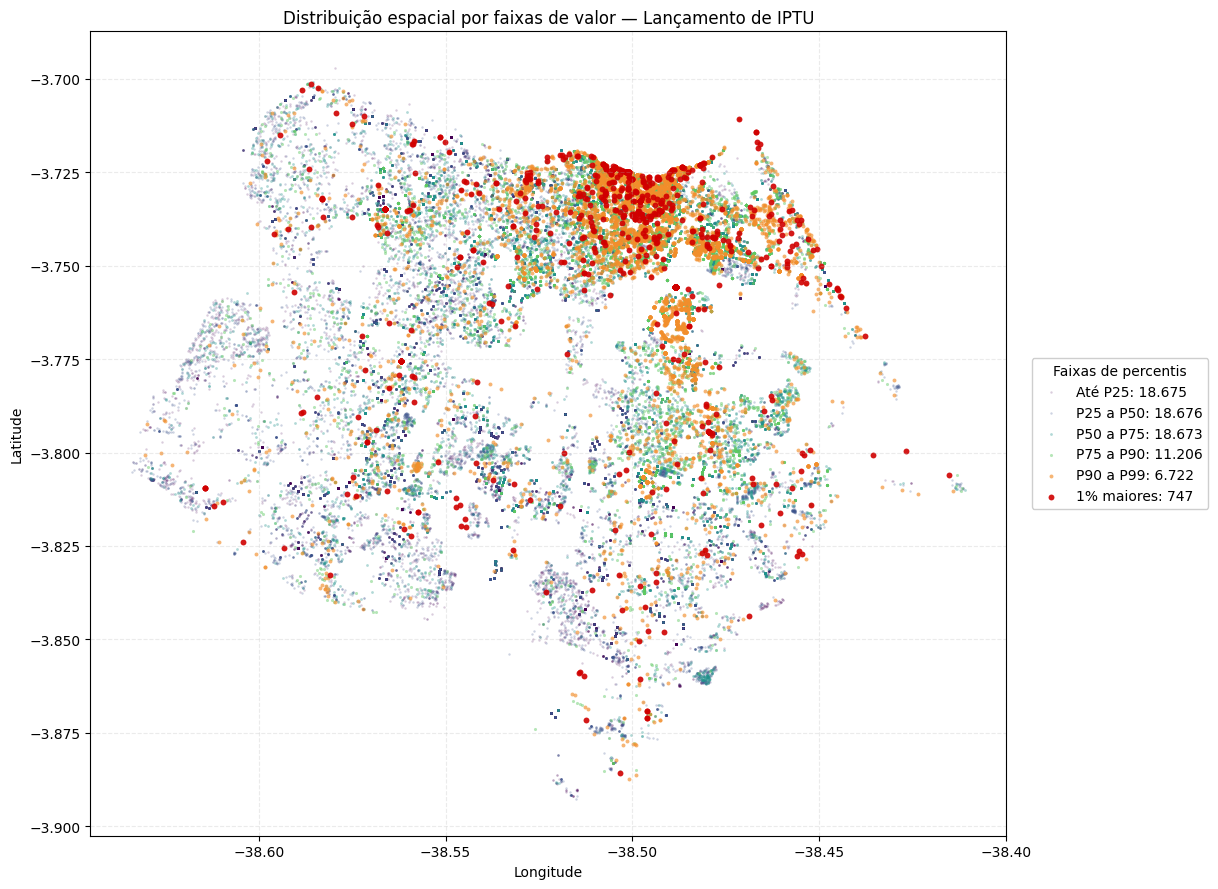

In [ ]:
cores_faixas = {
    'Até P25': '#440154',       # Roxo-escuro
    'P25 a P50': '#3B528B',     # Azul
    'P50 a P75': '#21918C',     # Verde-azulado
    'P75 a P90': '#5EC962',     # Verde-claro
    'P90 a P99': '#F28E2B',     # Laranja
    '1% maiores': '#D00000'     # Vermelho
}

# Criar um mapa para cada variável monetária
for variavel, configuracao in configuracao_mapas.items():

    # Selecionar imóveis com valores preenchidos,
    # iguais ou superiores a zero e com coordenadas válidas
    base_valida = base_mapa_valores.loc[
        base_mapa_valores[variavel].notna()
        & base_mapa_valores[variavel].ge(0)
        & base_mapa_valores['LATITUDE'].notna()
        & base_mapa_valores['LONGITUDE'].notna()
    ].copy()

    # Calcular os percentis utilizados na classificação
    p25 = base_valida[variavel].quantile(0.25)
    p50 = base_valida[variavel].quantile(0.50)
    p75 = base_valida[variavel].quantile(0.75)
    p90 = base_valida[variavel].quantile(0.90)
    p99 = base_valida[variavel].quantile(0.99)

    # Construir as seis faixas de valores
    faixas = {
        'Até P25': (
            base_valida[variavel] <= p25
        ),

        'P25 a P50': (
            base_valida[variavel].gt(p25)
            & base_valida[variavel].le(p50)
        ),

        'P50 a P75': (
            base_valida[variavel].gt(p50)
            & base_valida[variavel].le(p75)
        ),

        'P75 a P90': (
            base_valida[variavel].gt(p75)
            & base_valida[variavel].le(p90)
        ),

        'P90 a P99': (
            base_valida[variavel].gt(p90)
            & base_valida[variavel].lt(p99)
        ),

        '1% maiores': (
            base_valida[variavel] >= p99
        )
    }

    # Tamanhos dos pontos de cada faixa
    tamanhos_pontos = {
        'Até P25': 3,
        'P25 a P50': 3,
        'P50 a P75': 4,
        'P75 a P90': 5,
        'P90 a P99': 8,
        '1% maiores': 18
    }

    # Níveis de transparência
    transparencias = {
        'Até P25': 0.20,
        'P25 a P50': 0.25,
        'P50 a P75': 0.35,
        'P75 a P90': 0.45,
        'P90 a P99': 0.65,
        '1% maiores': 0.90
    }

    # Criar a figura
    fig, ax = plt.subplots(
        figsize=(13, 9)
    )

    # Desenhar cada faixa separadamente
    for nome_faixa, filtro_faixa in faixas.items():

        dados_faixa = base_valida.loc[
            filtro_faixa
        ]

        ax.scatter(
            dados_faixa['LONGITUDE'],
            dados_faixa['LATITUDE'],
            s=tamanhos_pontos[nome_faixa],
            color=cores_faixas[nome_faixa],
            alpha=transparencias[nome_faixa],
            linewidths=0,
            label=(
                f'{nome_faixa}: '
                f'{len(dados_faixa):,}'
                .replace(',', '.')
            )
        )

    # Configurar o gráfico
    ax.set_title(
        'Distribuição espacial por faixas de valor — '
        + configuracao['legenda']
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.grid(
        linestyle='--',
        alpha=0.25
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    # Colocar a legenda fora da área do mapa
    ax.legend(
        title='Faixas de percentis',
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        framealpha=0.95
    )

    plt.tight_layout()
    plt.show()

## Análise dos valores monetários por bairro

Os mapas de dispersão permitiram observar a distribuição espacial dos valores dos imóveis. Entretanto, eles não identificam diretamente quais bairros apresentam os valores mais elevados.

Para realizar essa comparação, serão calculadas as medianas de `VL_BASE_CALCULO`, `VL_VENAL` e `VL_LANCAMENTO_IPTU` em cada bairro.

A mediana será utilizada como medida principal porque as variáveis monetárias possuem distribuições assimétricas e valores extremos. Diferentemente da média, a mediana sofre menor influência de poucos imóveis excepcionalmente caros.

Cada imóvel será contabilizado apenas uma vez, utilizando seu registro mais recente. Além disso, serão considerados nos rankings somente os bairros com pelo menos 100 imóveis com valor preenchido na respectiva variável. Esse critério reduz o risco de destacar bairros representados por uma quantidade muito pequena de observações.

Os valores iguais a zero serão preservados nos cálculos, conforme a decisão adotada durante o tratamento dos dados. Os valores ausentes não serão utilizados no cálculo das medianas.

In [ ]:
# Quantidade mínima de imóveis por bairro
quantidade_minima_bairro = 100

# Configurar os nomes apresentados nas tabelas
nomes_variaveis_bairros = {
    'VL_BASE_CALCULO': 'Base de cálculo',
    'VL_VENAL': 'Valor venal',
    'VL_LANCAMENTO_IPTU': 'Lançamento de IPTU'
}

# Dicionário para armazenar os resultados
resumos_bairros = {}

# Calcular a mediana por bairro para cada variável
for variavel, nome_variavel in nomes_variaveis_bairros.items():

    resumo_bairro = (
        base_mapa_valores
        .groupby('BAIRRO')
        .agg(
            QUANTIDADE_IMOVEIS=(
                variavel,
                'count'
            ),

            VALOR_MEDIANO=(
                variavel,
                'median'
            )
        )
        .reset_index()
    )

    # Manter somente bairros com pelo menos 100 valores preenchidos
    resumo_bairro = (
        resumo_bairro[
            resumo_bairro['QUANTIDADE_IMOVEIS']
            >= quantidade_minima_bairro
        ]
        .sort_values(
            'VALOR_MEDIANO',
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Guardar o resultado completo
    resumos_bairros[variavel] = resumo_bairro

    # Apresentar os dez bairros com maiores medianas
    print(
        f'\nDez maiores medianas — {nome_variavel}'
    )

    display(
        resumo_bairro
        .head(10)
        .style
        .format({
            'QUANTIDADE_IMOVEIS': '{:,.0f}',
            'VALOR_MEDIANO': formatar_moeda_brasileira
        })
    )


Dez maiores medianas — Base de cálculo


,BAIRRO,QUANTIDADE_IMOVEIS,VALOR_MEDIANO
0,GUARARAPES,721,"R$ 865.000,00"
1,DE LOURDES,201,"R$ 765.000,00"
2,MANUEL DIAS BRANCO,389,"R$ 680.000,00"
3,MEIRELES,"4,846","R$ 590.000,00"
4,MUCURIPE,"1,061","R$ 554.110,00"
5,COCÓ,"2,383","R$ 537.610,00"
6,ENGENHEIRO LUCIANO CAVALCANTE,"1,748","R$ 530.135,00"
7,DIONÍSIO TORRES,"1,192","R$ 510.000,00"
8,PARQUELÂNDIA,475,"R$ 500.000,00"
9,SALINAS,262,"R$ 478.125,00"



Dez maiores medianas — Valor venal


,BAIRRO,QUANTIDADE_IMOVEIS,VALOR_MEDIANO
0,GUARARAPES,799,"R$ 365.624,80"
1,DE LOURDES,210,"R$ 293.805,80"
2,MUCURIPE,"1,106","R$ 227.504,96"
3,DIONÍSIO TORRES,"1,232","R$ 202.097,58"
4,COCÓ,"2,634","R$ 200.530,52"
5,MEIRELES,"4,965","R$ 196.475,69"
6,SALINAS,265,"R$ 193.618,21"
7,MANUEL DIAS BRANCO,400,"R$ 185.827,60"
8,ENGENHEIRO LUCIANO CAVALCANTE,"1,858","R$ 185.355,91"
9,EDSON QUEIROZ,"1,783","R$ 162.840,88"



Dez maiores medianas — Lançamento de IPTU


,BAIRRO,QUANTIDADE_IMOVEIS,VALOR_MEDIANO
0,GUARARAPES,799,"R$ 2.997,66"
1,DE LOURDES,208,"R$ 2.719,69"
2,MANUEL DIAS BRANCO,386,"R$ 2.192,86"
3,MUCURIPE,"1,076","R$ 1.747,86"
4,PRAIA DO FUTURO I,259,"R$ 1.586,77"
5,COCÓ,"2,494","R$ 1.508,40"
6,MEIRELES,"4,512","R$ 1.489,74"
7,ENGENHEIRO LUCIANO CAVALCANTE,"1,754","R$ 1.487,23"
8,DIONÍSIO TORRES,"1,227","R$ 1.468,60"
9,SALINAS,265,"R$ 1.437,96"


### Resultado da análise monetária por bairro

A análise das medianas por bairro apresenta resultados consistentes entre as três variáveis monetárias.

O bairro Guararapes ocupa a primeira posição nas três classificações, apresentando mediana de R$ 865.000,00 para a base de cálculo, R$ 365.624,80 para o valor venal e R$ 2.997,66 para o lançamento de IPTU.

O bairro De Lourdes aparece na segunda posição nos três rankings, com medianas de R$ 765.000,00 para a base de cálculo, R$ 293.805,80 para o valor venal e R$ 2.719,69 para o lançamento de IPTU.

Também se observa forte presença dos bairros Manuel Dias Branco, Meireles, Mucuripe, Cocó, Engenheiro Luciano Cavalcante, Dionísio Torres e Salinas. Esses nove bairros aparecem entre os dez primeiros colocados nas três variáveis analisadas.

Os resultados mostram que os bairros com maiores bases de cálculo também tendem a apresentar maiores valores venais e lançamentos de IPTU. Portanto, existe coerência espacial entre as três medidas monetárias.

Entretanto, as classificações não devem ser interpretadas diretamente como um ranking dos preços de mercado dos bairros de Fortaleza. Os valores são provenientes dos registros presentes na base de ITBI e correspondem a informações cadastrais e tributárias dos imóveis analisados.

Também é necessário considerar a diferença na quantidade de observações. Bairros como Meireles, Cocó e Engenheiro Luciano Cavalcante possuem milhares de imóveis representados, enquanto De Lourdes e Salinas possuem pouco mais de 200 registros. Embora todos atendam ao critério mínimo estabelecido, as medianas calculadas com amostras maiores tendem a apresentar maior estabilidade.

In [ ]:
dados_trabalho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94970 entries, 0 to 94969
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   NUM_DTI                               94970 non-null  string        
 1   EXERCICIO                             94970 non-null  int64         
 2   DATA_CADASTRAMENTO_GI_IMOVEL          94970 non-null  datetime64[ns]
 3   NUMERO_CEP                            94969 non-null  string        
 4   BAIRRO                                94970 non-null  object        
 5   LOGRADOURO                            94969 non-null  object        
 6   NUMERO                                90357 non-null  float64       
 7   XSIRGAS2000                           94970 non-null  float64       
 8   YSIRGAS2000                           94970 non-null  float64       
 9   QTD_FRENTES                           94970 non-null  int64         
 10

## Seleção das variáveis finais da base de trabalho

Após as etapas de limpeza, transformação, geocodificação e criação de novas variáveis, a base `dados_trabalho` possui 94.970 registros e 40 variáveis.

Antes da exportação para o Power BI, serão removidas algumas variáveis que cumpriram uma função durante o tratamento dos dados, mas que não serão necessárias nas análises e visualizações finais.

### Variáveis de endereço

A variável `NUMERO_CEP` contém o Código de Endereçamento Postal do imóvel. Ela foi utilizada, juntamente com o bairro e o logradouro, para auxiliar na recuperação das coordenadas ausentes.

A variável `LOGRADOURO` identifica a rua, avenida ou outro tipo de via em que o imóvel está localizado. Essa variável possui milhares de categorias distintas e foi utilizada principalmente na geocodificação.

A variável `NUMERO` indica o número do imóvel no respectivo logradouro. Sua principal utilização também ocorreu durante a construção dos endereços submetidos à geocodificação.

Como todos os registros já possuem latitude e longitude, essas três variáveis não serão necessárias para os mapas. Para as análises territoriais, serão mantidas `BAIRRO`, `LATITUDE` e `LONGITUDE`.

A retirada de logradouro e número também reduz a granularidade da identificação dos imóveis na base destinada ao dashboard.

### Coordenadas no sistema SIRGAS 2000

As variáveis `XSIRGAS2000` e `YSIRGAS2000` representam, respectivamente, as coordenadas horizontal e vertical dos imóveis no sistema projetado SIRGAS 2000 / UTM zona 24S.

Essas coordenadas foram importantes para gerar `LATITUDE` e `LONGITUDE`. Entretanto, o Power BI trabalha diretamente com latitude e longitude na construção de mapas.

Como a conversão foi concluída e validada, `XSIRGAS2000` e `YSIRGAS2000` serão retiradas da base final para evitar a manutenção de duas representações diferentes da mesma localização.

A variável `ORIGEM_COORDENADA` será mantida para distinguir as coordenadas originais daquelas obtidas por geocodificação.

### Ajuste do nome de uma variável derivada

A variável `IDADE_CADASTRO` não representa a idade do imóvel. Ela representa o número de anos transcorridos entre o ano de cadastramento e o ano de referência de 2026.

Por esse motivo, ela será renomeada para `TEMPO_DESDE_CADASTRAMENTO`, tornando seu significado mais claro para a análise e para a utilização no Power BI.

Todas as variáveis excluídas permanecem preservadas na base original `dados`.

### Resumo das decisões sobre as variáveis espaciais

| Variável | Significado | Decisão | Justificativa |
|---|---|---|---|
| `NUMERO_CEP` | CEP do imóvel | Excluir | Já estão disponíveis o bairro e as coordenadas geográficas |
| `LOGRADOURO` | Via onde está localizado o imóvel | Excluir | Possui alta cardinalidade e a geocodificação já foi concluída |
| `NUMERO` | Número do imóvel no logradouro | Excluir | Foi utilizado somente como apoio à geocodificação |
| `XSIRGAS2000` | Coordenada horizontal no sistema projetado | Excluir | Foi convertida para longitude |
| `YSIRGAS2000` | Coordenada vertical no sistema projetado | Excluir | Foi convertida para latitude |
| `BAIRRO` | Bairro do imóvel | Manter | Necessário para as análises territoriais |
| `LATITUDE` | Latitude do imóvel | Manter | Necessária para a construção dos mapas |
| `LONGITUDE` | Longitude do imóvel | Manter | Necessária para a construção dos mapas |
| `ORIGEM_COORDENADA` | Procedência da coordenada | Manter | Garante a rastreabilidade das coordenadas |

In [ ]:
# Renomear a variável para representar corretamente seu significado
dados_trabalho = dados_trabalho.rename(
    columns={
        'IDADE_CADASTRO':
        'TEMPO_DESDE_CADASTRAMENTO'
    }
)

# Variáveis que cumpriram sua função durante a geocodificação
# e não serão necessárias no dashboard
variaveis_excluir_final = [
    'NUMERO_CEP',
    'LOGRADOURO',
    'NUMERO',
    'XSIRGAS2000',
    'YSIRGAS2000'
]

# Excluir as variáveis da base de trabalho
dados_trabalho = dados_trabalho.drop(
    columns=variaveis_excluir_final
)

# Conferir as dimensões após a seleção
print(
    'Dimensões finais de dados_trabalho:',
    dados_trabalho.shape
)

Dimensões finais de dados_trabalho: (94970, 35)


In [ ]:
# Apresentar as variáveis mantidas na base
for numero, coluna in enumerate(
    dados_trabalho.columns,
    start=1
):
    print(f'{numero:02d} - {coluna}')

01 - NUM_DTI
02 - EXERCICIO
03 - DATA_CADASTRAMENTO_GI_IMOVEL
04 - BAIRRO
05 - QTD_FRENTES
06 - FRACAO_IDEAL
07 - AREA_TERRENO
08 - AREA_EDIFICADA
09 - DATA_CONSTRUCAO
10 - NUMERO_PAVIMENTOS
11 - TIPO_USO_IMOVEL
12 - PADRAO_CONSTRUCAO
13 - ANO_MES_DEBITO
14 - NOME_ZONEAMENTO
15 - ZONA_CARTORIO
16 - ID_IMOVEL
17 - VL_BASE_CALCULO
18 - VL_VENAL
19 - VL_LANCAMENTO_IPTU
20 - IND_COMPRA_VIA_PROGRAMA_HABITACIONAL
21 - ANO_CADASTRAMENTO
22 - ANO_CONSTRUCAO
23 - TEMPO_DESDE_CADASTRAMENTO
24 - IDADE_IMOVEL
25 - CONSISTENCIA_TEMPORAL
26 - DECADA_CONSTRUCAO
27 - FAIXA_DECADA_CONSTRUCAO
28 - FAIXA_IDADE_IMOVEL
29 - ORDEM_FAIXA_IDADE
30 - LONGITUDE
31 - LATITUDE
32 - ORIGEM_COORDENADA
33 - MES_CADASTRAMENTO_NUMERO
34 - MES_CADASTRAMENTO
35 - ANO_MES_CADASTRAMENTO


## Reconstrução da base de imóveis distintos

A base `base_imoveis` havia sido criada anteriormente, antes da conclusão do tratamento espacial, da criação das novas variáveis temporais e da seleção das colunas finais.

Por esse motivo, ela será reconstruída a partir da versão atualizada de `dados_trabalho`.

Para cada `ID_IMOVEL`, será mantido somente o registro com a data de cadastramento mais recente. Dessa forma, a nova base conterá um único registro por imóvel e incorporará todas as transformações realizadas.

A base `dados_trabalho` continuará representando as operações imobiliárias, enquanto `base_imoveis` será utilizada nas análises das características dos imóveis.

In [ ]:
# Reconstruir a base definitiva de imóveis distintos
base_imoveis = (
    dados_trabalho
    .sort_values(
        'DATA_CADASTRAMENTO_GI_IMOVEL'
    )
    .drop_duplicates(
        subset='ID_IMOVEL',
        keep='last'
    )
    .reset_index(drop=True)
    .copy()
)

# Construir a validação da base
validacao_base_imoveis = pd.Series({
    'REGISTROS_DADOS_TRABALHO': (
        len(dados_trabalho)
    ),

    'REGISTROS_BASE_IMOVEIS': (
        len(base_imoveis)
    ),

    'IMOVEIS_DISTINTOS': (
        base_imoveis['ID_IMOVEL']
        .nunique()
    ),

    'IDS_DUPLICADOS': (
        base_imoveis['ID_IMOVEL']
        .duplicated()
        .sum()
    ),

    'QUANTIDADE_VARIAVEIS': (
        base_imoveis.shape[1]
    )
})

validacao_base_imoveis

,0
REGISTROS_DADOS_TRABALHO,94970
REGISTROS_BASE_IMOVEIS,80008
IMOVEIS_DISTINTOS,80008
IDS_DUPLICADOS,0
QUANTIDADE_VARIAVEIS,35


### Resultado da reconstrução da base de imóveis

A base definitiva de imóveis foi construída com 80.008 registros, correspondentes aos 80.008 identificadores distintos encontrados na base de operações.

A ausência de identificadores duplicados confirma que cada imóvel aparece somente uma vez em `base_imoveis`.

As 35 variáveis finais foram mantidas, incorporando os tratamentos, as coordenadas geográficas, as variáveis temporais e as classificações criadas durante a preparação dos dados.

In [ ]:
# Construir uma tabela de validação das bases finais
validacao_bases_finais = pd.DataFrame({
    'BASE': [
        'Operações',
        'Imóveis distintos'
    ],

    'REGISTROS': [
        len(dados_trabalho),
        len(base_imoveis)
    ],

    'VARIAVEIS': [
        dados_trabalho.shape[1],
        base_imoveis.shape[1]
    ],

    'OPERACOES_DISTINTAS': [
        dados_trabalho['NUM_DTI'].nunique(),
        base_imoveis['NUM_DTI'].nunique()
    ],

    'IMOVEIS_DISTINTOS': [
        dados_trabalho['ID_IMOVEL'].nunique(),
        base_imoveis['ID_IMOVEL'].nunique()
    ],

    'NUM_DTI_DUPLICADOS': [
        dados_trabalho['NUM_DTI'].duplicated().sum(),
        base_imoveis['NUM_DTI'].duplicated().sum()
    ],

    'ID_IMOVEL_DUPLICADOS': [
        dados_trabalho['ID_IMOVEL'].duplicated().sum(),
        base_imoveis['ID_IMOVEL'].duplicated().sum()
    ],

    'LATITUDES_AUSENTES': [
        dados_trabalho['LATITUDE'].isna().sum(),
        base_imoveis['LATITUDE'].isna().sum()
    ],

    'LONGITUDES_AUSENTES': [
        dados_trabalho['LONGITUDE'].isna().sum(),
        base_imoveis['LONGITUDE'].isna().sum()
    ]
})

validacao_bases_finais

,BASE,REGISTROS,VARIAVEIS,OPERACOES_DISTINTAS,IMOVEIS_DISTINTOS,NUM_DTI_DUPLICADOS,ID_IMOVEL_DUPLICADOS,LATITUDES_AUSENTES,LONGITUDES_AUSENTES
0,Operações,94970,35,94970,80008,0,14962,0,0
1,Imóveis distintos,80008,35,80008,80008,0,0,0,0


### Resultado da validação das bases finais

A base de operações possui 94.970 registros, e todos os valores de `NUM_DTI` são distintos. Portanto, cada linha representa uma operação diferente.

Foram identificados 80.008 imóveis distintos. A presença de 14.962 ocorrências duplicadas de `ID_IMOVEL` na base de operações é esperada, pois alguns imóveis aparecem em mais de uma operação.

A base de imóveis possui 80.008 registros e não apresenta duplicação de `ID_IMOVEL`, confirmando que cada imóvel foi contabilizado somente uma vez.

Também não existem valores ausentes em `LATITUDE` ou `LONGITUDE` nas duas bases. Assim, todos os registros estão disponíveis para utilização nos mapas.

In [ ]:
# Função para construir o resumo de ausências
def construir_resumo_ausencias(base):

    resumo = pd.DataFrame({
        'QUANTIDADE_AUSENTE': (
            base.isna().sum()
        ),

        'PERCENTUAL_AUSENTE': (
            base.isna()
            .mean()
            .mul(100)
            .round(2)
        )
    })

    # Manter somente as variáveis que possuem ausências
    return (
        resumo[
            resumo['QUANTIDADE_AUSENTE'] > 0
        ]
        .sort_values(
            'PERCENTUAL_AUSENTE',
            ascending=False
        )
    )


# Ausências na base de operações
ausencias_operacoes = construir_resumo_ausencias(
    dados_trabalho
)

# Ausências na base de imóveis distintos
ausencias_imoveis = construir_resumo_ausencias(
    base_imoveis
)

print('Ausências na base de operações:')
display(ausencias_operacoes)

print('\nAusências na base de imóveis distintos:')
display(ausencias_imoveis)

Ausências na base de operações:


,QUANTIDADE_AUSENTE,PERCENTUAL_AUSENTE
NUMERO_PAVIMENTOS,15212,16.02
DATA_CONSTRUCAO,10198,10.74
IDADE_IMOVEL,10198,10.74
ANO_CONSTRUCAO,10198,10.74
DECADA_CONSTRUCAO,10198,10.74
VL_BASE_CALCULO,6890,7.25
VL_LANCAMENTO_IPTU,5622,5.92
AREA_EDIFICADA,2444,2.57



Ausências na base de imóveis distintos:


,QUANTIDADE_AUSENTE,PERCENTUAL_AUSENTE
NUMERO_PAVIMENTOS,13392,16.74
DATA_CONSTRUCAO,8795,10.99
IDADE_IMOVEL,8795,10.99
ANO_CONSTRUCAO,8795,10.99
DECADA_CONSTRUCAO,8795,10.99
VL_LANCAMENTO_IPTU,5309,6.64
VL_BASE_CALCULO,2947,3.68
AREA_EDIFICADA,1905,2.38


### Resultado da avaliação final dos valores ausentes

A avaliação final não identificou novas ausências produzidas pelas etapas de tratamento.

A variável `NUMERO_PAVIMENTOS` apresenta o maior percentual de valores ausentes, correspondendo a 16,02% da base de operações e 16,74% da base de imóveis distintos.

As ausências observadas em `ANO_CONSTRUCAO`, `IDADE_IMOVEL` e `DECADA_CONSTRUCAO` resultam diretamente da ausência de `DATA_CONSTRUCAO`. Por isso, essas quatro variáveis apresentam quantidades iguais de valores ausentes em cada base.

Também permanecem ausências em `VL_BASE_CALCULO`, `VL_LANCAMENTO_IPTU` e `AREA_EDIFICADA`.

Esses valores não serão substituídos por zero nem por medidas como média ou mediana. A substituição poderia introduzir informações inexistentes e modificar artificialmente as distribuições observadas.

As categorias `FAIXA_IDADE_IMOVEL` e `FAIXA_DECADA_CONSTRUCAO` já representam esses casos como “Não informado”, permitindo sua inclusão nos gráficos e filtros do Power BI.

## Exportação das bases tratadas

Após a conclusão dos tratamentos e das validações, serão exportadas duas bases para utilização no Power BI:

- `itbi_operacoes_tratadas.csv`: contém as 94.970 operações imobiliárias;
- `itbi_imoveis_distintos.csv`: contém os 80.008 imóveis distintos, representados pelo registro cadastral mais recente.

Os arquivos serão gravados no formato CSV, utilizando ponto e vírgula como separador e codificação UTF-8 com assinatura. Essa codificação preserva corretamente os acentos dos nomes de bairros e das categorias textuais.

In [ ]:
# Definir a pasta de destino
pasta_saida = (
    '/content/drive/MyDrive/'
    'Ciências Atuariais 2026_2/'
    'BI/Seminario01/'
)

# Exportar a base de operações
dados_trabalho.to_csv(
    pasta_saida + 'itbi_operacoes_tratadas.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Exportar a base de imóveis distintos
base_imoveis.to_csv(
    pasta_saida + 'itbi_imoveis_distintos.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Copiar o vídeo da animação para o Google Drive
shutil.copy2(
    caminho_video,
    pasta_saida + 'evolucao_espacial_imoveis.mp4'
)

print('Arquivos exportados com sucesso:')
print('- itbi_operacoes_tratadas.csv')
print('- itbi_imoveis_distintos.csv')
print('- evolucao_espacial_imoveis.mp4')# Definir a pasta de destino
pasta_saida = (
    '/content/drive/MyDrive/'
    'Ciências Atuariais 2026_2/'
    'BI/Seminario01/'
)

# Exportar a base de operações
dados_trabalho.to_csv(
    pasta_saida + 'itbi_operacoes_tratadas.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Exportar a base de imóveis distintos
base_imoveis.to_csv(
    pasta_saida + 'itbi_imoveis_distintos.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Copiar o vídeo da animação para o Google Drive
shutil.copy2(
    caminho_video,
    pasta_saida + 'evolucao_espacial_imoveis.mp4'
)

print('Arquivos exportados com sucesso:')
print('- itbi_operacoes_tratadas.csv')
print('- itbi_imoveis_distintos.csv')
print('- evolucao_espacial_imoveis.mp4')# Definir a pasta de destino
pasta_saida = (
    '/content/drive/MyDrive/'
    'Ciências Atuariais 2026_2/'
    'BI/Seminario01/'
)

# Exportar a base de operações
dados_trabalho.to_csv(
    pasta_saida + 'itbi_operacoes_tratadas.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Exportar a base de imóveis distintos
base_imoveis.to_csv(
    pasta_saida + 'itbi_imoveis_distintos.csv',
    index=False,
    sep=';',
    encoding='utf-8-sig',
    date_format='%Y-%m-%d %H:%M:%S'
)

# Copiar o vídeo da animação para o Google Drive
shutil.copy2(
    caminho_video,
    pasta_saida + 'evolucao_espacial_imoveis.mp4'
)

print('Arquivos exportados com sucesso:')
print('- itbi_operacoes_tratadas.csv')
print('- itbi_imoveis_distintos.csv')
print('- evolucao_espacial_imoveis.mp4')

Arquivos exportados com sucesso:
- itbi_operacoes_tratadas.csv
- itbi_imoveis_distintos.csv
- evolucao_espacial_imoveis.mp4
Arquivos exportados com sucesso:
- itbi_operacoes_tratadas.csv
- itbi_imoveis_distintos.csv
- evolucao_espacial_imoveis.mp4
Arquivos exportados com sucesso:
- itbi_operacoes_tratadas.csv
- itbi_imoveis_distintos.csv
- evolucao_espacial_imoveis.mp4


In [ ]:
import os
# Caminhos dos arquivos exportados
caminho_operacoes = (
    pasta_saida
    + 'itbi_operacoes_tratadas.csv'
)

caminho_imoveis = (
    pasta_saida
    + 'itbi_imoveis_distintos.csv'
)

caminho_video_drive = (
    pasta_saida
    + 'evolucao_espacial_imoveis.mp4'
)

# Verificar se os arquivos existem
arquivos_exportados = {
    'Base de operações': caminho_operacoes,
    'Base de imóveis': caminho_imoveis,
    'Vídeo': caminho_video_drive
}

for nome, caminho_arquivo in arquivos_exportados.items():

    existe = os.path.exists(caminho_arquivo)

    tamanho_mb = (
        os.path.getsize(caminho_arquivo)
        / (1024 ** 2)
        if existe
        else 0
    )

    print(
        f'{nome}:',
        'Encontrado' if existe else 'Não encontrado',
        f'— {tamanho_mb:.2f} MB'
    )

Base de operações: Encontrado — 33.53 MB
Base de imóveis: Encontrado — 28.35 MB
Vídeo: Encontrado — 1.22 MB


In [ ]:
# Ler novamente os arquivos exportados
conferencia_operacoes = pd.read_csv(
    caminho_operacoes,
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)

conferencia_imoveis = pd.read_csv(
    caminho_imoveis,
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)

# Conferir as dimensões
pd.DataFrame({
    'ARQUIVO': [
        'Operações',
        'Imóveis distintos'
    ],

    'REGISTROS': [
        len(conferencia_operacoes),
        len(conferencia_imoveis)
    ],

    'VARIAVEIS': [
        conferencia_operacoes.shape[1],
        conferencia_imoveis.shape[1]
    ]
})

,ARQUIVO,REGISTROS,VARIAVEIS
0,Operações,94970,35
1,Imóveis distintos,80008,35


## Conclusão da preparação dos dados

O processo de preparação resultou em duas bases destinadas a finalidades analíticas diferentes.

A base de operações contém 94.970 registros e preserva todas as operações distintas identificadas por `NUM_DTI`. Nela, um mesmo imóvel pode aparecer em mais de uma operação.

A base de imóveis contém 80.008 registros e apresenta somente o cadastro mais recente de cada `ID_IMOVEL`, garantindo que cada imóvel seja contabilizado apenas uma vez nas análises de suas características.

Durante a preparação, foram realizadas a conversão dos tipos das variáveis, a identificação e o tratamento de valores ausentes, a avaliação de variáveis administrativas, a criação de variáveis temporais, a análise de consistência das datas, a transformação das coordenadas para latitude e longitude e a recuperação de seis coordenadas por geocodificação.

Também foram criadas classificações por idade e década de construção, além de análises temporais, espaciais e monetárias.

Após a validação final, as duas bases foram exportadas com 35 variáveis cada e estão prontas para a construção do modelo de dados e dos dashboards no Power BI.